In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import json
import os
import glob
import matplotlib.dates as mdates

<jemalloc>: MADV_DONTNEED does not work (memset will be used instead)
<jemalloc>: (This is the expected behaviour if you are running under QEMU)


#### Helper functions

In [2]:


# Directory path where the cases are stored
base_dir = '/workspaces/CUBES/exp/jack/paper/thermostat_experiment/SI/sleep_hour_temps'

def load_json_file(file_type, case_number, zone_number):
    # Use glob to find the correct file path dynamically
    json_file_pattern = f'{base_dir}/case_{case_number}_year_2023_rep_H28_zone_{zone_number}_*/{file_type}.json'

    # Get the list of files that match the pattern
    matching_files = glob.glob(json_file_pattern)

    # Load and return the JSON data from the matched file
    with open(matching_files[0], 'r') as file:
        return json.load(file)

#### Tarrif plot

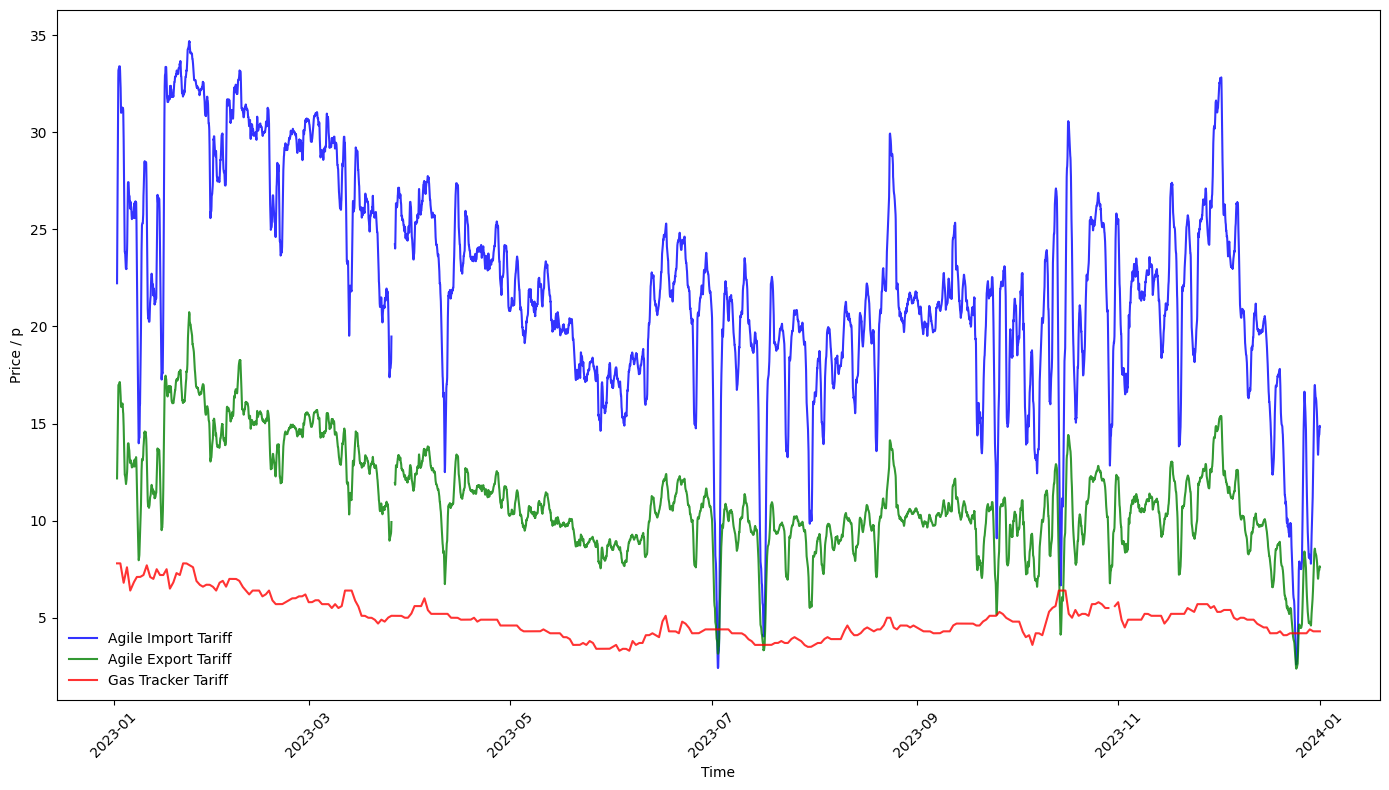

In [14]:

gas_tariff = pd.read_csv("/workspaces/CUBES/cubes/data/gas/gas_tracker.csv", parse_dates=["Time"], index_col=0)
import_tariff = pd.read_csv("/workspaces/CUBES/cubes/data/electricity_import/agile_import.csv", parse_dates=["Time"], index_col=0)
export_tariff = pd.read_csv("/workspaces/CUBES/cubes/data/electricity_export/agile_export.csv", parse_dates=["Time"], index_col=0)

gas_tariff.index = pd.to_datetime(gas_tariff.index)
import_tariff.index = pd.to_datetime(import_tariff.index, dayfirst=True)
export_tariff.index = pd.to_datetime(export_tariff.index, dayfirst=True)



def plot_tariffs_smoothed(gas_tariff, import_tariff, export_tariff, smoothing_window=24):

    # Resample to hourly for import and export tariffs (mean of every 30 mins interval)
    import_tariff_resampled = import_tariff.resample('h').mean()
    export_tariff_resampled = export_tariff.resample('h').mean()

    # Apply smoothing (rolling average) to all tariffs
    gas_tariff_smoothed = gas_tariff.rolling(window=smoothing_window).mean()
    import_tariff_smoothed = import_tariff_resampled.rolling(window=smoothing_window).mean()
    export_tariff_smoothed = export_tariff_resampled.rolling(window=smoothing_window).mean()

    # Set the figure size
    plt.figure(figsize=(14, 8))


    # Plot electricity import tariff (smoothed)
    plt.plot(import_tariff_smoothed.index, import_tariff_smoothed['price'], label='Agile Import Tariff', color='blue', alpha=0.8, linewidth=1.5)

    # Plot electricity export tariff (smoothed)
    plt.plot(export_tariff_smoothed.index, export_tariff_smoothed['price'], label='Agile Export Tariff', color='green', alpha=0.8, linewidth=1.5)

    # Plot gas tariff
    plt.plot(gas_tariff_smoothed.index, gas_tariff_smoothed['price'], label='Gas Tracker Tariff', color='red', alpha=0.8, linewidth=1.5)

    # Set x-axis labels and format
    plt.xlabel('Time')
    plt.ylabel('Price / p')
    # plt.title('Gas, Electricity Import, and Export Tariffs in 2023 (Smoothed)')

    # Set x-axis to display time more clearly
    plt.xticks(rotation=45)

    # Display legend
    plt.legend(frameon=False)

    # Show grid
    #plt.grid(True)

    plt.savefig("/workspaces/CUBES/exp/jack/paper/thermostat_experiment/figures/SI/tariff_plot.svg")



    # Display the plot
    plt.tight_layout()
    plt.show()



plot_tariffs_smoothed(gas_tariff, import_tariff, export_tariff)


#### Holiday plot

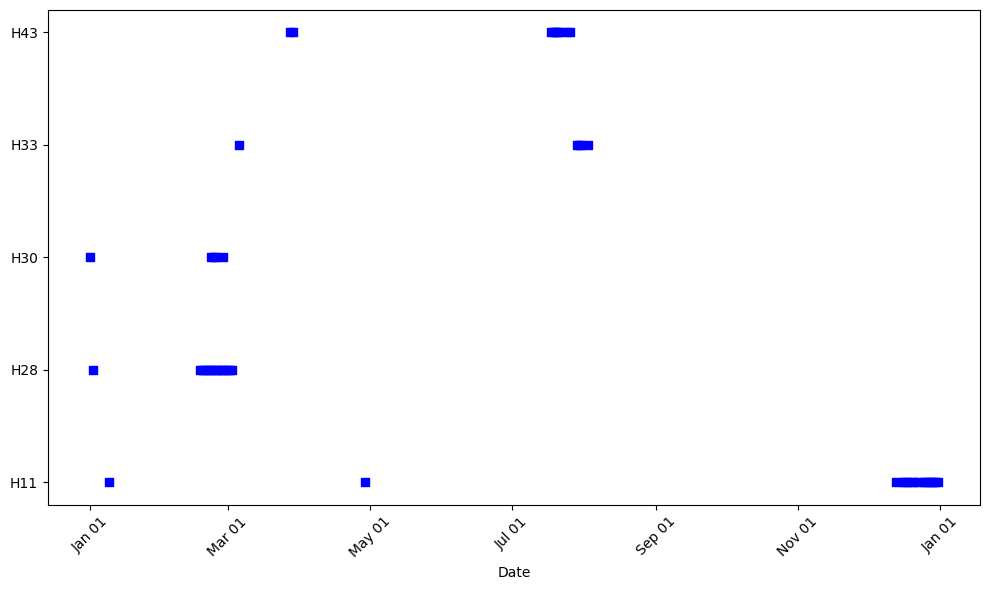

In [8]:
def plot_holidays():
        # Define the holiday mapping
        holiday_mapping = {
        "H11": [(1, 9), (4, 29), (12, 13), (12, 16), (12, 17), (12, 18), (12, 20), (12, 21),
                (12, 23), (12, 25), (12, 26), (12, 27), (12, 28), (12, 29), (12, 30), (12, 31)],
        "H28": [(1, 2), (2, 17), (2, 18), (2, 19), (2, 20), (2, 21), (2, 22), (2, 23),
                (2, 24), (2, 25), (2, 26), (2, 27), (2, 28), (3, 1), (3, 2), (3, 3)],
        "H30": [(1, 1), (2, 22), (2, 23), (2, 24), (2, 27)],
        "H33": [(3, 6), (7, 29), (7, 30), (7, 31), (8, 3)],
        "H43": [(3, 28), (3, 29), (7, 18), (7, 19), (7, 20), (7, 21), (7, 22), (7, 25), (7, 26)],
        }

        # Create figure and axis
        fig, ax = plt.subplots(figsize=(10, 6))

        # Set y-ticks based on the number of IDs
        y_labels = list(holiday_mapping.keys())
        y_pos = np.arange(len(y_labels))

        # Plot the holidays for each ID
        for i, (holiday_id, holidays) in enumerate(holiday_mapping.items()):
                for (month, day) in holidays:
                        ax.scatter(pd.Timestamp(year=2023, month=month, day=day), y_pos[i], marker='s', color='b')

        # Customize the plot
        ax.set_yticks(y_pos)
        ax.set_yticklabels(y_labels)
        ax.set_xlabel('Date')


        # Set x-axis to show month/day format
        ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%b %d'))

        # Rotate x-axis labels for better readability
        plt.xticks(rotation=45)

        # Show plot
        plt.tight_layout()
        plt.show()

plot_holidays()

In [9]:
# Room areas
room_areas = {
    'front_room': 14.04,
    'kitchen': 11.34,
    'backroom': 11.34,
    'hall_downstairs': 7.02,
    'bedroom_1': 11.51,
    'bedroom_2': 12.39,
    'bedroom_3': 6.86,
    'bathroom': 7.105,
    'hall_upstairs': 5.88
}
total_floor_area = sum(room_areas.values())


In [10]:
total_floor_area

87.48499999999999

#### Getting stats during year

In [ ]:


# data_case_0 = load_json_file("hourly_metrics", 0, zone_number=0)
# df_case_0 = pd.DataFrame(data_case_0['hourly_data'])
# data_case_9 = load_json_file("hourly_metrics", 0, zone_number=9)
# df_case_9 = pd.DataFrame(data_case_9['hourly_data'])


# # Assuming your DataFrame is named 'df'
# # Create a DateTime index for every hour in 2023 (non-leap year has 8760 hours)
# time_index = pd.date_range(start="2023-01-01 00:00:00", periods=8760, freq="H")

# df_case_0 = df_case_0.iloc[:8760]  # Truncate the DataFrame to match 8760 rows
# df_case_9 = df_case_9.iloc[:8760]  # Truncate the DataFrame to match 8760 rows

# # Assign the DateTime index to the DataFrame
# df_case_0.index = time_index
# df_case_9.index = time_index



# # Optionally, if you want to remove the existing 'hour' column (as it's now redundant):
# df_0 = df_case_0.drop(columns=['hour'])
# df_9 = df_case_9.drop(columns=['hour'])



# 1- (df_9["cost"].loc["2023-01-01 00:00:00": "2023-04-01 00:00:00"].sum() / 100) / (df_0["cost"].loc["2023-01-01 00:00:00": "2023-04-01 00:00:00"].sum() / 100)

# df_9["cost"].loc["2023-01-01 00:00:00": "2023-04-01 00:00:00"].sum() / 100

# df_0["cost"].loc["2023-01-01 00:00:00": "2023-04-01 00:00:00"].sum() / 100

# df_9["cost"].loc["2023-04-01 00:00:00": "2023-10-01 00:00:00"].sum() / 100

# df_0["cost"].loc["2023-04-01 00:00:00": "2023-10-01 00:00:00"].sum() / 100

# df_9["cost"].loc["2023-10-01 00:00:00": "2024-01-01 00:00:00"].sum() / 100


# 43.79172967329956 / 75.50182128708887

# df_0["cost"].loc["2023-10-01 00:00:00": "2024-01-01 00:00:00"].sum() / 100

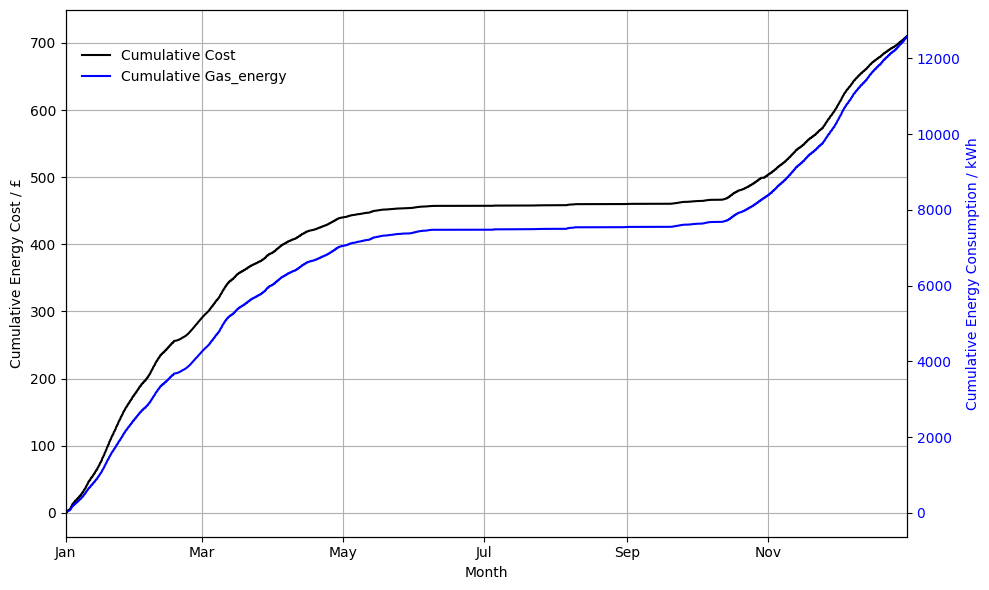

In [14]:

def plot_multiple_metrics(case_number, metrics):

    # Create a DateTime index starting from Jan 1 of the year for 8760 hours (non-leap year)
    time_index = pd.date_range(start="2023-01-01", periods=8760, freq="H")

    # Load the JSON data for the specified case, zone 0
    data_zone_0 = load_json_file("hourly_metrics", case_number, zone_number=0)
    df_zone_0 = pd.DataFrame(data_zone_0['hourly_data'])

    # Truncate the DataFrame to match 8760 rows
    df_zone_0 = df_zone_0.iloc[:8760]
    df_zone_0.index = time_index  # Assign the DateTime index

    # Create a plot
    fig, ax1 = plt.subplots(figsize=(10, 6))

    # Plot the first metric on the primary y-axis
    metric = metrics[0]
    normalise = 1  # Default normalisation factor

    if "cost" in metric:
        normalise = 100  # Convert pence to pounds
    elif "emission" in metric:
        normalise = 1000  # Convert grams to kilograms

    df_zone_0[f'cumulative_{metric}'] = df_zone_0[metric].cumsum() / normalise
    ax1.plot(df_zone_0.index, df_zone_0[f'cumulative_{metric}'], label=f'Cumulative {metric.capitalize()}', color='black')

    ax1.set_xlabel('Month')
    ax1.set_ylabel('Cumulative Energy Cost / £', color='black')
    ax1.tick_params(axis='y', labelcolor='black')

    # Set the x-axis to show every 3 months
    ax1.xaxis.set_major_locator(mdates.MonthLocator([1, 3, 5, 7, 9, 11]))
    ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
    ax1.set_xlim([pd.Timestamp('2023-01-01'), pd.Timestamp('2023-12-31')])

    # Plot additional metrics on a secondary y-axis, if more than one metric is given
    if len(metrics) > 1:
        ax2 = ax1.twinx()  # Create a secondary y-axis

        for i, metric in enumerate(metrics[1:], start=2):
            normalise = 1  # Default normalisation factor

            if "cost" in metric:
                normalise = 100  # Convert pence to pounds
            elif "emission" in metric:
                normalise = 1000  # Convert grams to kilograms

            df_zone_0[f'cumulative_{metric}'] = df_zone_0[metric].cumsum() / normalise
            ax2.plot(df_zone_0.index, df_zone_0[f'cumulative_{metric}'], label=f'Cumulative {metric.capitalize()}', linestyle='-', color='blue')

        ax2.set_ylabel('Cumulative Energy Consumption / kWh', color='blue')
        ax2.tick_params(axis='y', labelcolor='blue')

    # Add legends and grid
    ax1.grid(True)
    fig.legend(loc="upper left", bbox_to_anchor=(0.005, 0.95), bbox_transform=ax1.transAxes, frameon=False)

    # Adjust the layout and display the plot
    plt.tight_layout()
    plt.show()


plot_multiple_metrics(0, ["cost", "gas_energy"])


In [20]:


def plot_multiple_cases(metric, ax, case_dict, global_ymin, global_ymax, plot_zone_9=False):

    # Set normalisation factor based on the metric type
    if "cost" in metric:
        normalise = 100  # Convert pence to pounds
        unit = "£"
    elif "emission" in metric:
        normalise = 1000  # Convert grams to kilograms
        unit = "kgCO2"
    else:
        normalise = 1  # No normalisation needed
        unit = "kWh"

    # Create a DateTime index starting from Jan 1 of the year for 8760 hours (non-leap year)
    time_index = pd.date_range(start="2023-01-01", periods=8760, freq="H")

    # Load and process case 0 data (Baseline)
    data_case_0 = load_json_file("hourly_metrics", 0, zone_number=0)
    df_case_0 = pd.DataFrame(data_case_0['hourly_data'])
    df_case_0 = df_case_0.iloc[:8760]  # Truncate the DataFrame to match 8760 rows
    df_case_0.index = time_index  # Assign the DateTime index

    # If the metric is energy, combine gas_energy and electricity_energy
    if metric == "energy":
        df_case_0[f'cumulative_energy'] = (df_case_0['gas_energy'] + df_case_0['electricity_energy']).cumsum() / normalise
    else:
        df_case_0[f'cumulative_{metric}'] = df_case_0[f'{metric}'].cumsum() / normalise

    final_sum_case_0 = df_case_0[f'cumulative_{metric}' if metric != "energy" else 'cumulative_energy'].iloc[-1]

    # Set colour palette to maintain consistent colours between zones for the same case
    color_palette = plt.get_cmap('tab10')

    # Loop through specified cases from the dictionary and plot them
    for idx, (case_number, case_name) in enumerate(case_dict.items()):
        color = color_palette(idx)  # Get the color for the current case

        # Load the JSON data for the specified case, zone 0
        data_zone_0 = load_json_file("hourly_metrics", case_number, zone_number=0)
        df_zone_0 = pd.DataFrame(data_zone_0['hourly_data'])
        df_zone_0 = df_zone_0.iloc[:8760]  # Truncate the DataFrame to match 8760 rows
        df_zone_0.index = time_index  # Assign the DateTime index

        # If the metric is energy, combine gas_energy and electricity_energy
        if metric == "energy":
            df_zone_0[f'cumulative_energy'] = (df_zone_0['gas_energy'] + df_zone_0['net_electricity_energy']).cumsum() / normalise
            df_zone_0[f'percentage_{metric}'] = (df_zone_0['cumulative_energy'] / final_sum_case_0) * 100
        else:
            # Calculate the cumulative sum of the specified metric
            df_zone_0[f'cumulative_{metric}'] = df_zone_0[f'{metric}'].cumsum() / normalise
            # Divide by the final cumulative value from case 0 to make it a percentage
            df_zone_0[f'percentage_{metric}'] = (df_zone_0[f'cumulative_{metric}'] / final_sum_case_0) * 100

        # Update global ymin and ymax
        global_ymin = min(global_ymin, df_zone_0[f'percentage_{metric}'].min())
        global_ymax = max(global_ymax, df_zone_0[f'percentage_{metric}'].max())

        # Plot the metric for zone 0 using the case name in the label and the same color
        ax.plot(df_zone_0.index, df_zone_0[f'percentage_{metric}'], label=f'{case_name} (Timed Heating)', color=color)

        # Optionally plot zone 9 data if the flag is set to True
        if plot_zone_9:
            data_zone_9 = load_json_file("hourly_metrics", case_number, zone_number=9)
            df_zone_9 = pd.DataFrame(data_zone_9['hourly_data'])
            df_zone_9 = df_zone_9.iloc[:8760]
            df_zone_9.index = time_index

            if metric == "energy":
                df_zone_9[f'cumulative_energy'] = (df_zone_9['gas_energy'] + df_zone_9['net_electricity_energy']).cumsum() / normalise
                df_zone_9[f'percentage_{metric}'] = (df_zone_9['cumulative_energy'] / final_sum_case_0) * 100
            else:
                df_zone_9[f'cumulative_{metric}'] = df_zone_9[f'{metric}'].cumsum() / normalise
                df_zone_9[f'percentage_{metric}'] = (df_zone_9[f'cumulative_{metric}'] / final_sum_case_0) * 100

            # Update global ymin and ymax for zone 9 as well
            global_ymin = min(global_ymin, df_zone_9[f'percentage_{metric}'].min())
            global_ymax = max(global_ymax, df_zone_9[f'percentage_{metric}'].max())

            # Plot zone 9 data with the same color but different linestyle
            ax.plot(df_zone_9.index, df_zone_9[f'percentage_{metric}'], label=f'{case_name} (Zonal Heating)', linestyle='--', color=color)

    if unit == "£":
        ax.text(0.07, 0.90, f'Baseline: {unit}{final_sum_case_0:.0f}', transform=ax.transAxes,
                fontsize=10, verticalalignment='bottom', horizontalalignment='left')
    else:
        ax.text(0.07, 0.90, f'Baseline: {final_sum_case_0:.0f} {unit}', transform=ax.transAxes,
                fontsize=10, verticalalignment='bottom', horizontalalignment='left')

    # Set the x-axis to show every 3 months
    ax.xaxis.set_major_locator(mdates.MonthLocator([1, 3, 5, 7, 9, 11]))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))

    # Set labels, grid, and legend
    ax.set_xlabel('Month')
    ax.set_ylabel(f'Cumulative {metric.replace("_", " ").capitalize()} (%)')
    ax.grid(True, color='gray', linestyle='-', linewidth=0.5, alpha=0.3)
    if ax == axs[1]:  # Only add the legend to the right subplot
        ax.legend(frameon=False, loc='best')

    return global_ymin, global_ymax




#### Specific analysis about timed heating vs occupancy control

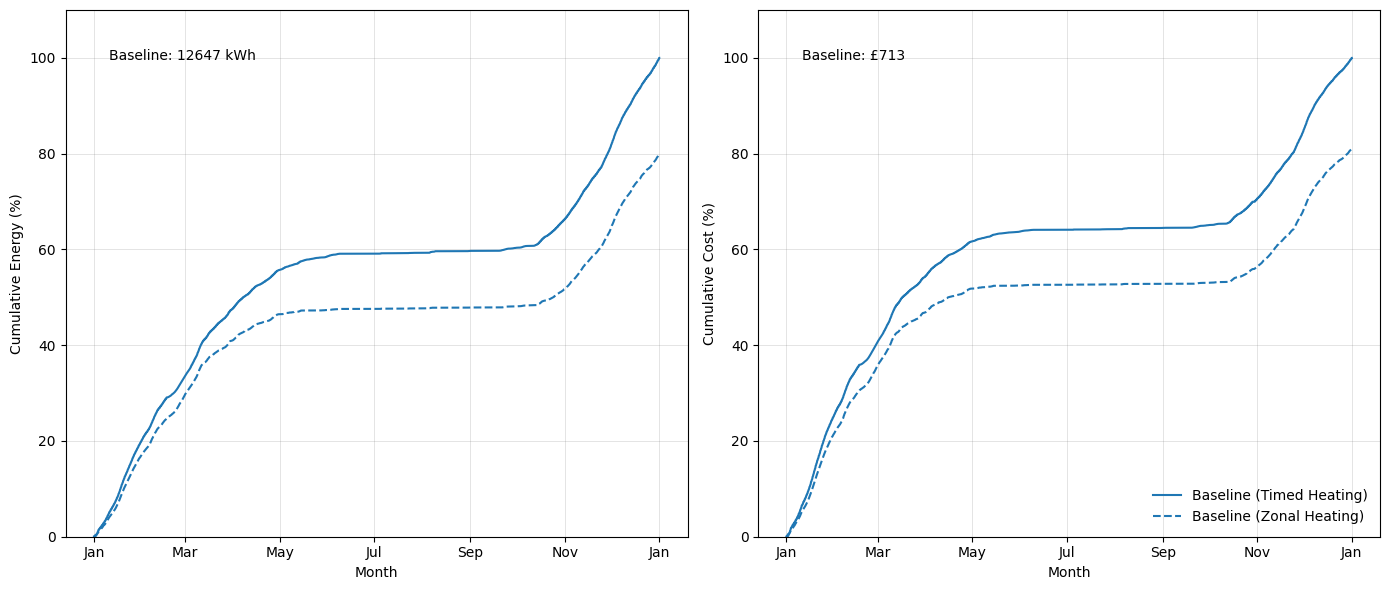

In [21]:
# Example usage with a custom case dictionary
case_dict = {
    0: "Baseline",
}

# Create a figure with two subplots (1 row, 2 columns)
fig, axs = plt.subplots(1, 2, figsize=(14, 6))

# Initialize global ymin and ymax
global_ymin, global_ymax = float('inf'), float('-inf')

# Plot the two metrics on separate subplots and update global ymin and ymax
global_ymin, global_ymax = plot_multiple_cases("energy", axs[0], case_dict, global_ymin, global_ymax, plot_zone_9=True)
global_ymin, global_ymax = plot_multiple_cases("cost", axs[1], case_dict, global_ymin, global_ymax, plot_zone_9=True)

# Apply global ymin and ymax to both subplots
for ax in axs:
    ax.set_ylim(global_ymin, global_ymax + 10)

# Adjust the layout and display the plot
plt.tight_layout()
plt.show()


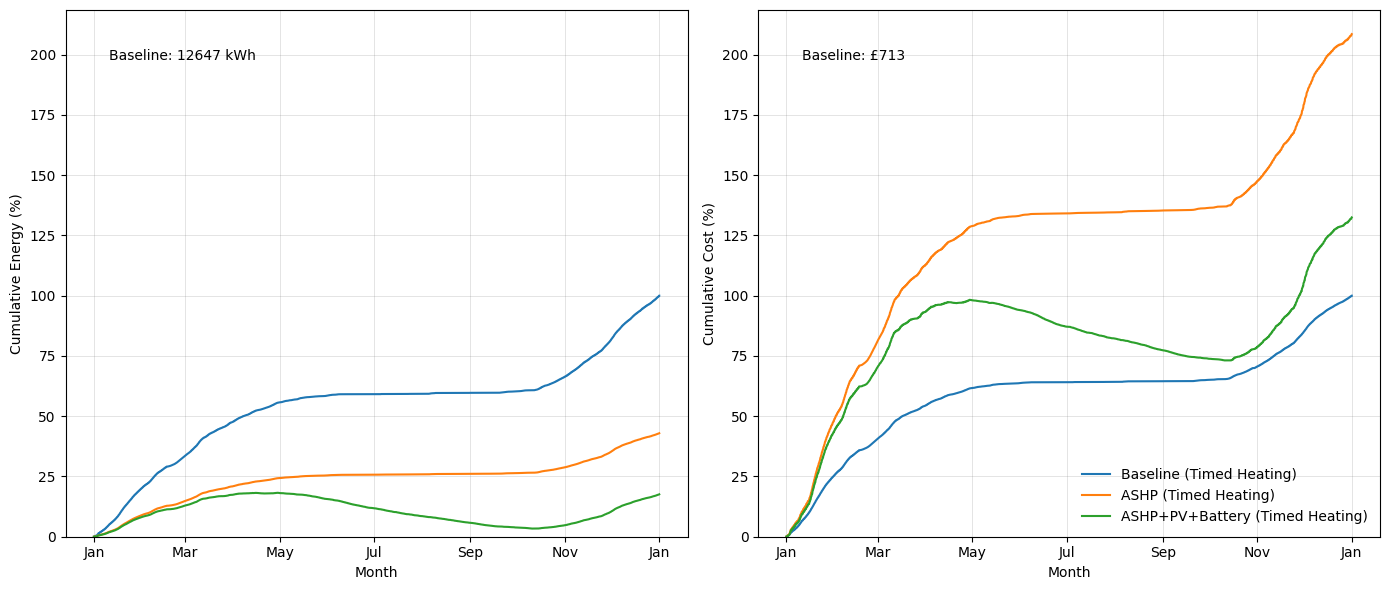

In [22]:
# Example usage with a custom case dictionary
case_dict = {
    0: "Baseline",
    5: "ASHP",
    10: "ASHP+PV+Battery"
}

# Create a figure with two subplots (1 row, 2 columns)
fig, axs = plt.subplots(1, 2, figsize=(14, 6))

# Initialize global ymin and ymax
global_ymin, global_ymax = float('inf'), float('-inf')

# Plot the two metrics on separate subplots and update global ymin and ymax
global_ymin, global_ymax = plot_multiple_cases("energy", axs[0], case_dict, global_ymin, global_ymax, plot_zone_9=False)
global_ymin, global_ymax = plot_multiple_cases("cost", axs[1], case_dict, global_ymin, global_ymax, plot_zone_9=False)

# Apply global ymin and ymax to both subplots
for ax in axs:
    ax.set_ylim(global_ymin, global_ymax+10)

# Adjust the layout and display the plot
plt.tight_layout()
plt.show()


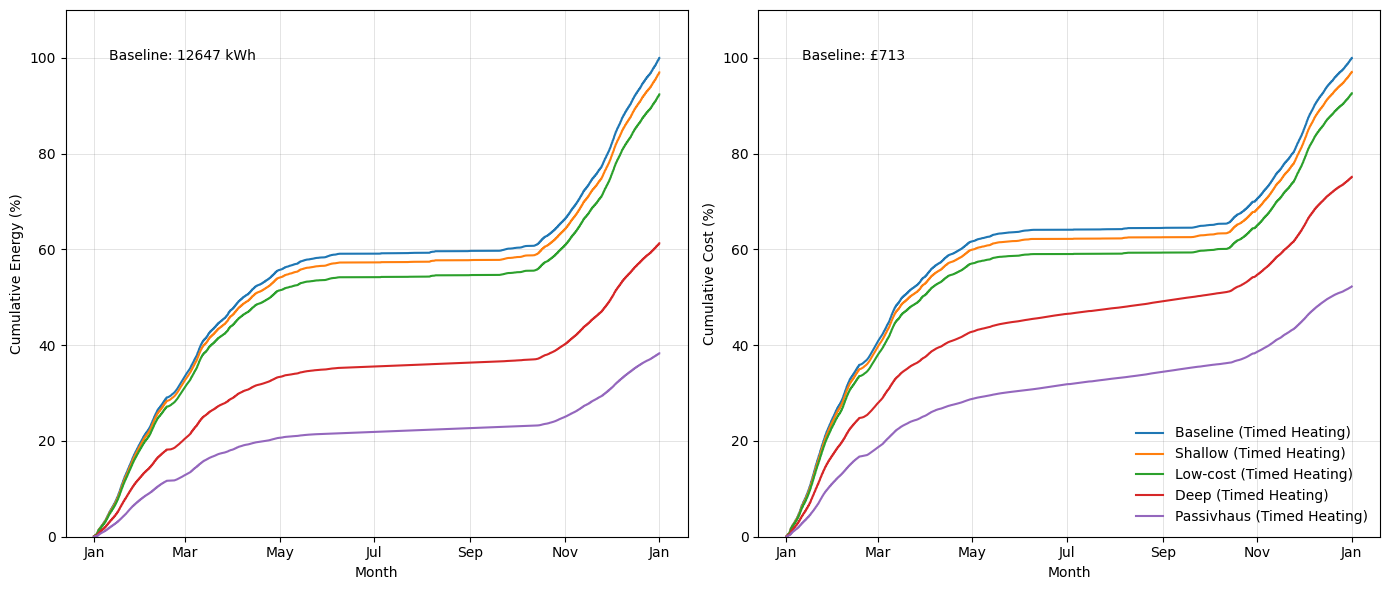

In [23]:
# Example usage with a custom case dictionary
case_dict = {
        0: "Baseline",
        1: "Shallow",
        2: "Low-cost",
        3: "Deep",
        4: "Passivhaus",
    }

# Create a figure with two subplots (1 row, 2 columns)
fig, axs = plt.subplots(1, 2, figsize=(14, 6))

# Initialize global ymin and ymax
global_ymin, global_ymax = float('inf'), float('-inf')

# Plot the two metrics on separate subplots and update global ymin and ymax
global_ymin, global_ymax = plot_multiple_cases("energy", axs[0], case_dict, global_ymin, global_ymax, plot_zone_9=False)
global_ymin, global_ymax = plot_multiple_cases("cost", axs[1], case_dict, global_ymin, global_ymax, plot_zone_9=False)

# Apply global ymin and ymax to both subplots
for ax in axs:
    ax.set_ylim(global_ymin, global_ymax+10)

# Adjust the layout and display the plot
plt.tight_layout()
plt.show()


In [12]:


def plot_metric_figure(metric):

    # Set normalisation factor based on the metric type
    if "cost" in metric:
        normalise = 100  # Convert pence to pounds
        unit = '£'
    elif "emission" in metric:
        normalise = 1000  # Convert grams to kilograms
        unit = 'tCO2'
    else:
        normalise = 1  # No normalisation needed
        unit = 'kWh'

    # Create the 5x3 plot grid
    fig, axes = plt.subplots(5, 3, figsize=(12, 20))
    axes = axes.flatten()

    # Define the order of cases for the rows
    #case_order = [10, 11, 12, 13, 14, 5, 6, 7, 8, 9, 0, 1, 2, 3, 4]
    # Define the order of cases for the rows
    case_order = [
        4, 9, 14,
        3, 8, 13,
        2, 7, 12,
        1, 6, 11,
        0, 5, 10
    ]

    # Create a DateTime index starting from Jan 1 of the year for 8760 hours (non-leap year)
    time_index = pd.date_range(start="2023-01-01", periods=8760, freq="H")

    # Load the JSON data for case 0, zone 0 (to plot on all subplots)
    data_case_0 = load_json_file("hourly_metrics", 0, zone_number=0)
    df_case_0 = pd.DataFrame(data_case_0['hourly_data'])

    # Truncate the DataFrame to match 8760 rows
    df_case_0 = df_case_0.iloc[:8760]
    df_case_0.index = time_index  # Assign the DateTime index

    if metric == "energy":
        df_case_0[f'cumulative_{metric}'] = (df_case_0['gas_energy'] + df_case_0['net_electricity_energy']).cumsum() / normalise
    else:
        df_case_0[f'cumulative_{metric}'] = df_case_0[f'{metric}'].cumsum() / normalise

    # Variables to track the global minimum and maximum y values
    global_max_y = float('-inf')
    global_min_y = float('inf')

    # Loop over the cases from 0 to 14, but use case_order to assign them to subplots
    for i, case_number in enumerate(case_order):
        # Load the JSON data for the current case, zone 0 and zone 9
        data_zone_0 = load_json_file("hourly_metrics", case_number, zone_number=0)
        data_zone_9 = load_json_file("hourly_metrics", case_number, zone_number=9)

        df_zone_0 = pd.DataFrame(data_zone_0['hourly_data'])
        df_zone_9 = pd.DataFrame(data_zone_9['hourly_data'])

        # Truncate the DataFrames to match 8760 rows
        df_zone_0 = df_zone_0.iloc[:8760]
        df_zone_9 = df_zone_9.iloc[:8760]

        df_zone_0.index = time_index  # Assign the DateTime index
        df_zone_9.index = time_index  # Assign the DateTime index

        # Calculate the cumulative sum of the specified metric for both zones
        if metric == "energy":
            df_zone_0[f'cumulative_{metric}'] = (df_zone_0['gas_energy'] + df_zone_0['net_electricity_energy']).cumsum() / normalise
            df_zone_9[f'cumulative_{metric}'] = (df_zone_9['gas_energy'] + df_zone_9['net_electricity_energy']).cumsum() / normalise
        else:
            df_zone_0[f'cumulative_{metric}'] = df_zone_0[f'{metric}'].cumsum() / normalise
            df_zone_9[f'cumulative_{metric}'] = df_zone_9[f'{metric}'].cumsum() / normalise

        # Update global_max_y and global_min_y with the current maximum and minimum y values
        global_max_y = max(global_max_y, df_zone_0[f'cumulative_{metric}'].max(), df_zone_9[f'cumulative_{metric}'].max())
        global_min_y = min(global_min_y, df_zone_0[f'cumulative_{metric}'].min(), df_zone_9[f'cumulative_{metric}'].min())

        # Plot the cumulative metric on the subplot for this case
        ax = axes[i]

        # Plot case 0 metric (zone 0) as a light grey dashed line in all subplots
        ax.plot(df_case_0.index, df_case_0[f'cumulative_{metric}'], color='lightgray', linestyle='--', label='Baseline + Timed')

        # Plot current case metric for zone 0 as a solid black line
        ax.plot(df_zone_0.index, df_zone_0[f'cumulative_{metric}'], color='black', label=f'Retrofit + Timed')

        # Plot current case metric for zone 9 as a solid blue line
        ax.plot(df_zone_9.index, df_zone_9[f'cumulative_{metric}'], color='blue', linestyle='--', label=f'Retrofit + Zonal')

        # Set the x-axis to show every 3 months
        ax.xaxis.set_major_locator(mdates.MonthLocator([1, 3, 5, 7, 9, 11]))
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))

        #ax.set_xlim([pd.Timestamp('2023-01-01'), pd.Timestamp('2023-12-31')])


        if i in [0, 3, 6, 9, 12]:
            if i == 0:
                case_desc = "Passivhaus"
            elif i == 3:
                case_desc = "Deep"
            elif i == 6:
                case_desc = "Low-cost"
            elif i == 9:
                case_desc = "Shallow"
            elif i == 12:
                case_desc = "Baseline"
            ax.set_ylabel(f'{case_desc}\nCumulative {metric.capitalize()} / {unit}', fontsize=12, weight='bold')

        if i in [12, 13, 14]:
            if i == 12:
                case_desc = "Gas boiler"
            elif i == 13:
                case_desc = "ASHP"
            elif i == 14:
                case_desc = "ASHP+PV+Battery"
            ax.set_xlabel(f'Month\n{case_desc}', fontsize=12, weight='bold')

        if i == 8:
            ax.legend(loc='upper left', frameon=False)


        ax.grid(True, color='gray', linestyle='-', linewidth=0.5, alpha=0.3)



    # Apply the global max and min y limits to all subplots
    for ax in axes:
        ax.set_ylim(global_min_y, global_max_y)

    # Adjust the layout and display the plot
    plt.tight_layout()
    plt.show()


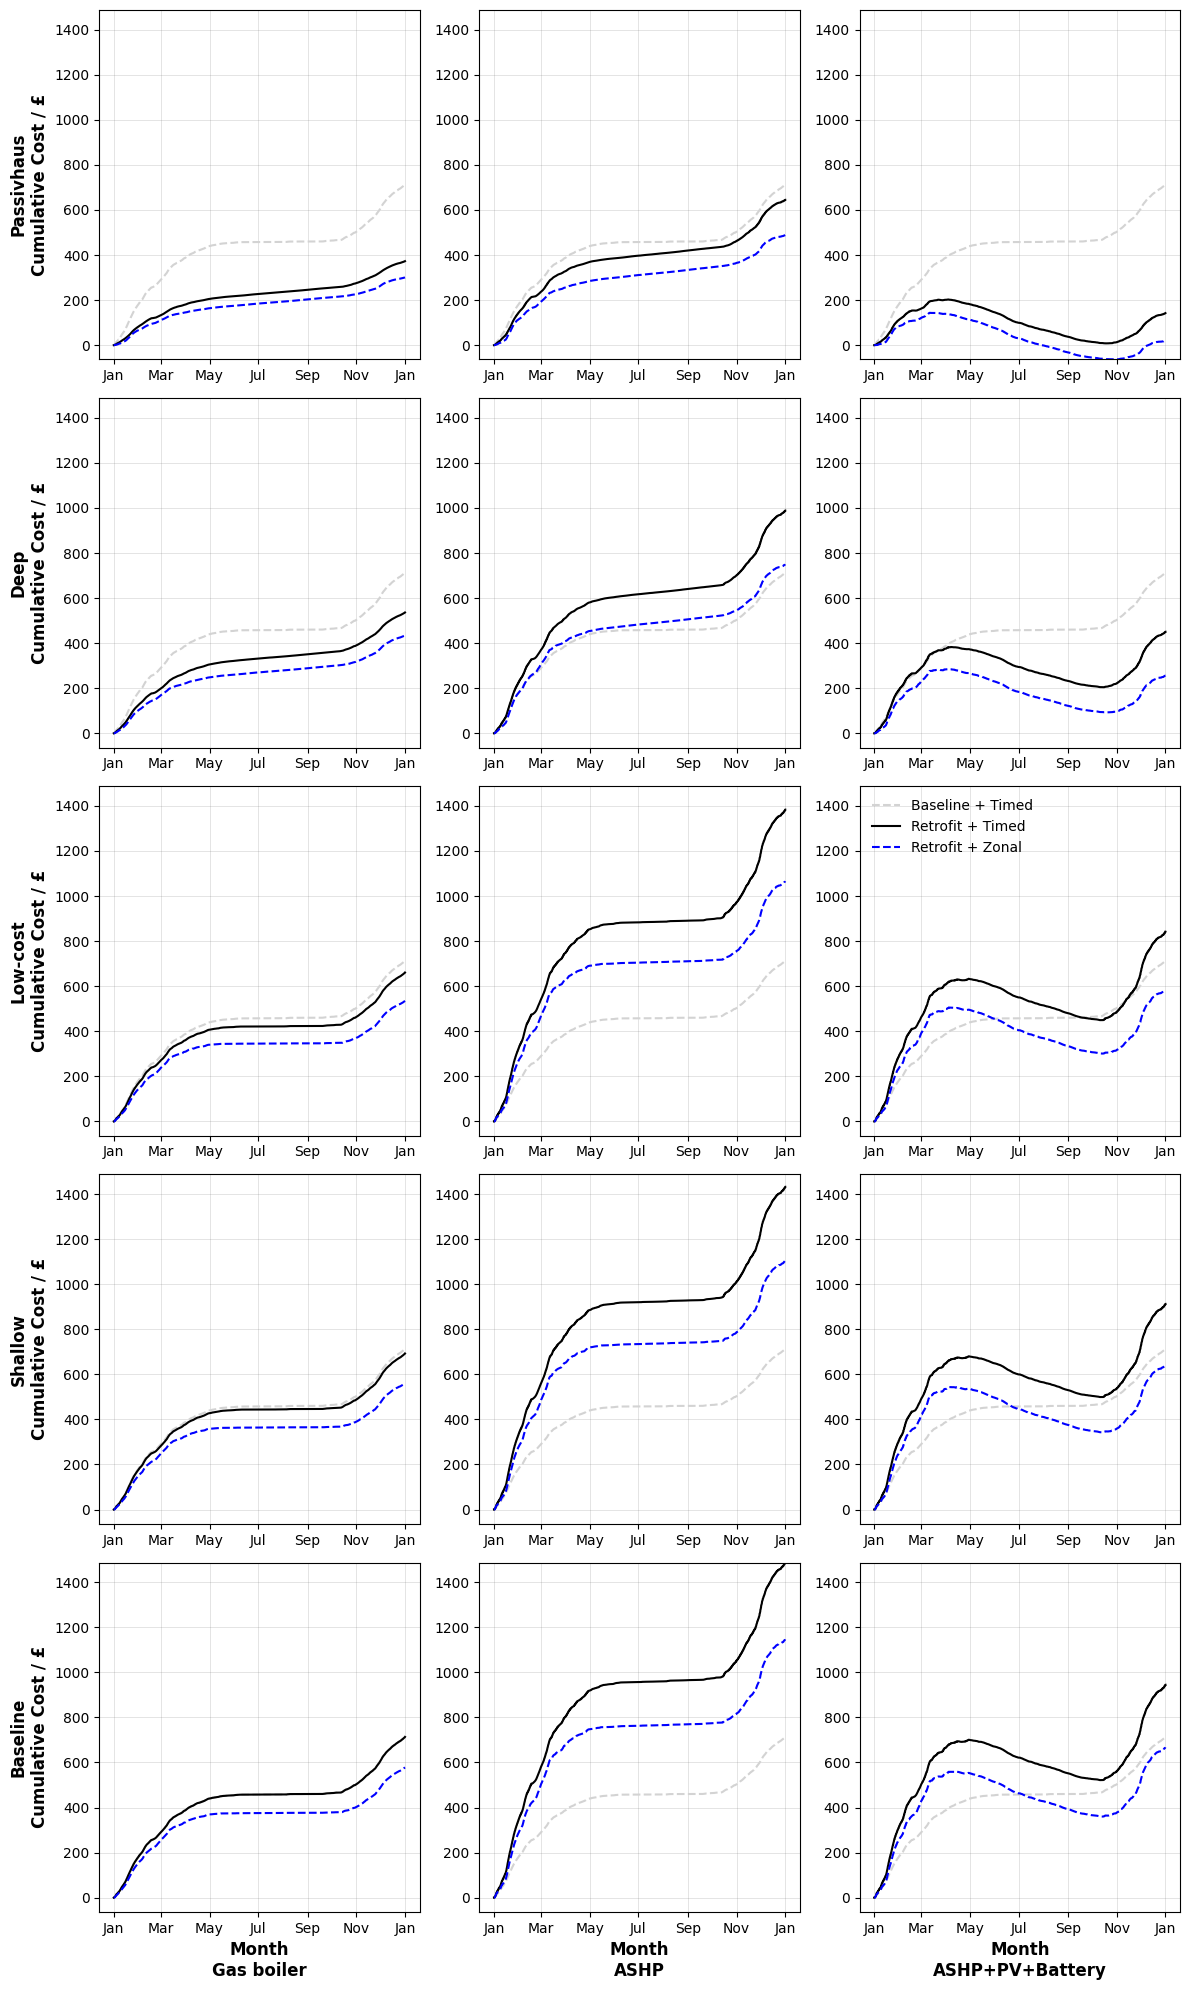

In [13]:
plot_metric_figure('cost')

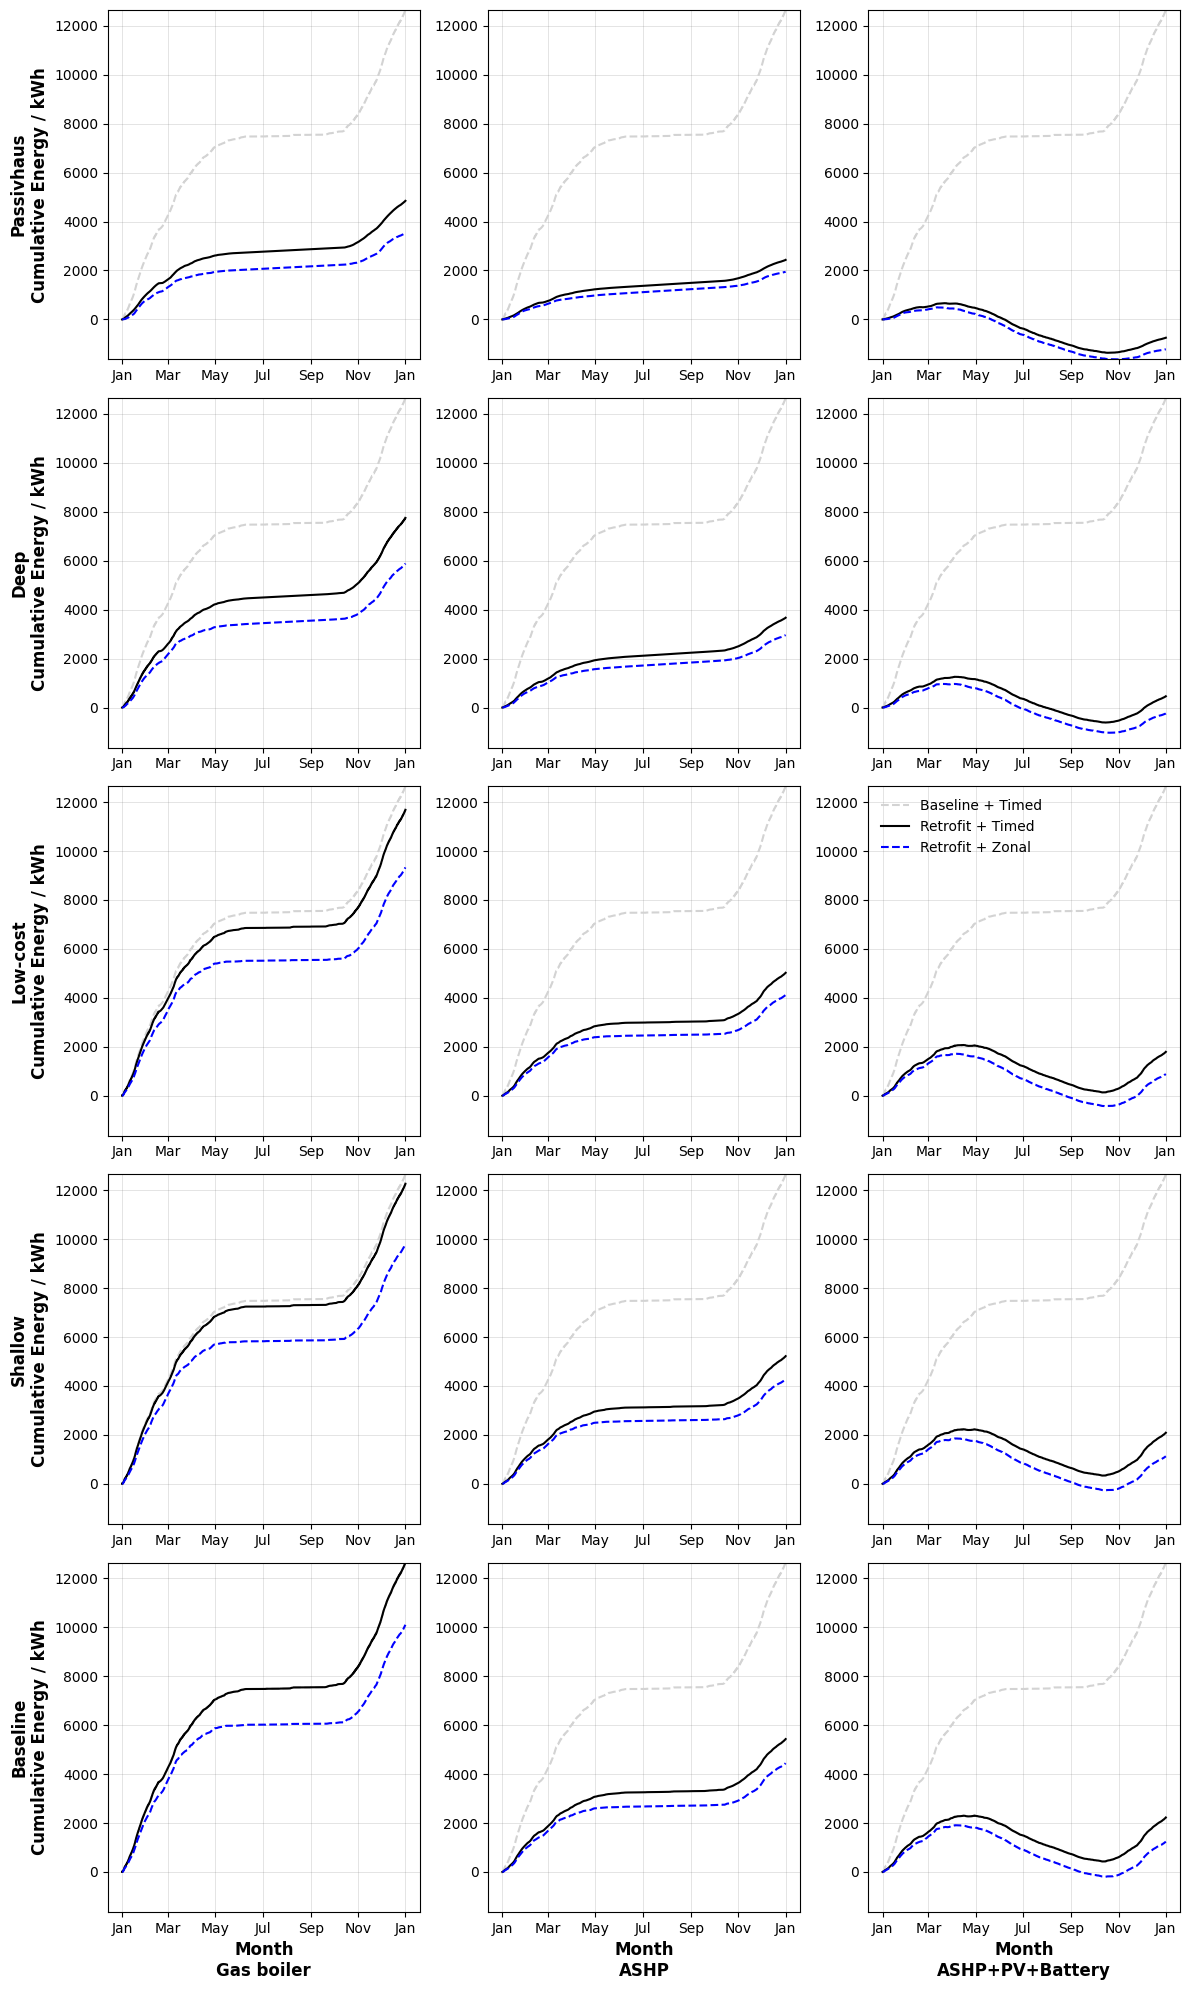

In [14]:
plot_metric_figure('energy')

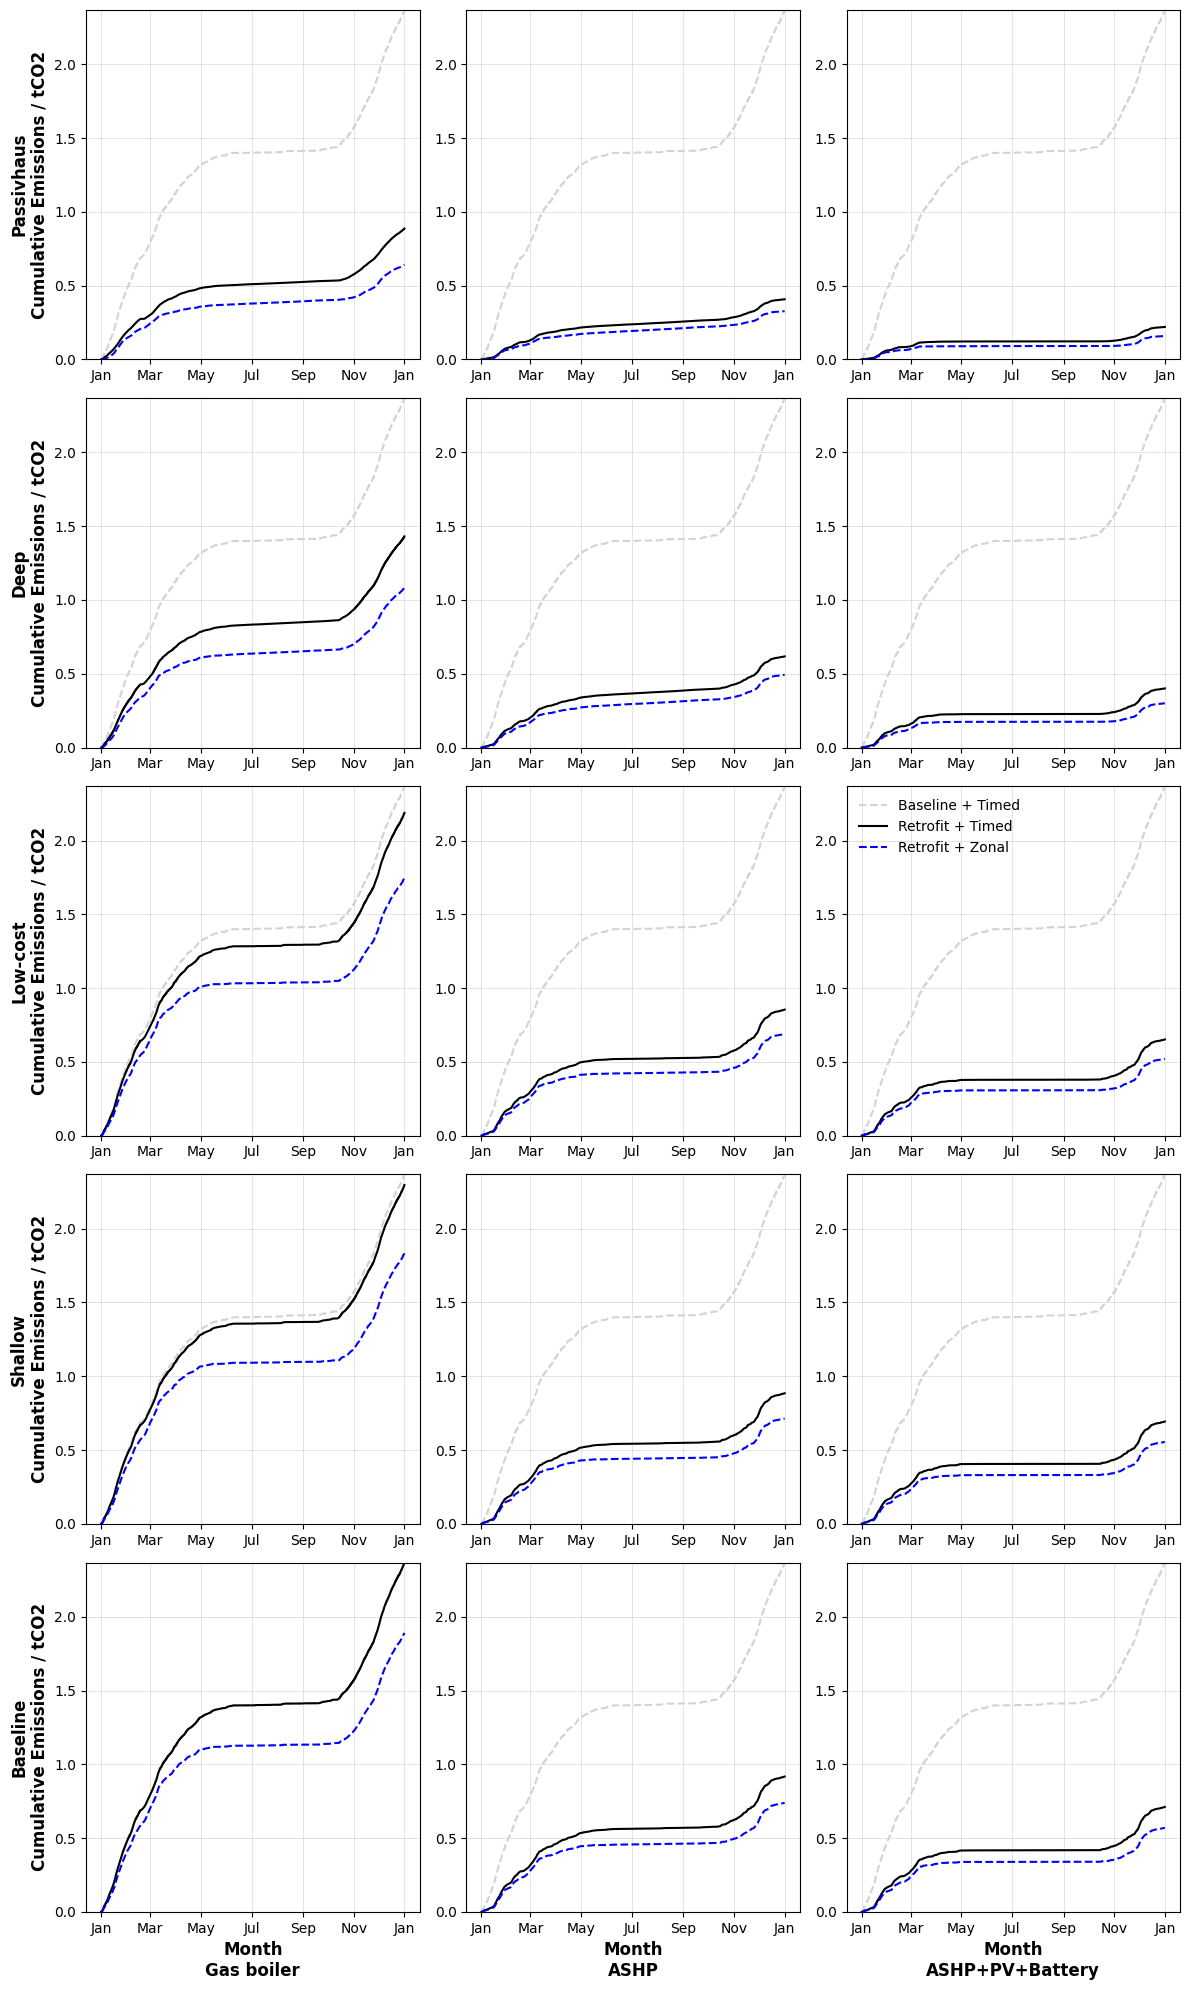

In [16]:
plot_metric_figure('emissions')

### Temperature plots

In [5]:

# Directory path where the cases are stored
base_dir = '/workspaces/CUBES/exp/jack/paper/thermostat_experiment/SI/sleep_hour_temps'

room_areas = {
        'kitchen': 11.34,
        'backroom': 11.34,
        'front_room': 14.04,
        'hall_downstairs': 7.02,
        'bathroom': 7.105,
        'hall_upstairs': 5.88,
        'bedroom_1': 11.51,
        'bedroom_2': 12.39,
        'bedroom_3': 6.86,
    }


def load_json_file(file_type, case_number, zone_number):
    # Use glob to find the correct file path dynamically
    json_file_pattern = f'{base_dir}/case_{case_number}_year_2023_rep_H28_zone_{zone_number}_*/{file_type}.json'

    # Get the list of files that match the pattern
    matching_files = glob.glob(json_file_pattern)

    # Load and return the JSON data from the matched file
    with open(matching_files[0], 'r') as file:
        return json.load(file)

# Function to normalise JSON data
def json_normalise_temperature(df):
    df[['Temperature', 'Percentage_Time']] = pd.json_normalize(df['percentage_time'])
    df = df.drop(columns=['percentage_time'])
    return df



def process_temperature_data(df, mins, room_areas):
    df['Counts_Time'] = df.apply(lambda row: [(pt * row['total_count']) / 100 for pt in row['Percentage_Time']], axis=1)
    df['Days_in_Year'] = df['Counts_Time'].apply(lambda counts: [(count / mins) * 365 for count in counts])

    df_exploded = df.explode(['Temperature', 'Counts_Time', 'Days_in_Year']).reset_index(drop=True)

    pivoted_df = df_exploded.pivot_table(
        index=df_exploded.index,
        columns='zone',
        values=['Temperature', 'Counts_Time', 'Days_in_Year']
    )

    pivoted_df.columns = [f"{metric}_{zone}" for metric, zone in pivoted_df.columns]
    pivoted_df.reset_index(drop=True, inplace=True)

    concat_df = pd.DataFrame()
    concat_df["Temperature"] = df_exploded["Temperature"].unique()

    for room in room_areas:
        if f"Days_in_Year_{room}" in pivoted_df.columns:
            zone_days = pivoted_df[f"Days_in_Year_{room}"].dropna().reset_index(drop=True)
            concat_df[f"{room}"] = zone_days

    return concat_df


def load_and_process_data(data_case, hour_category, mins):
    if hour_category not in ["awake_hours", "all"]:
        df_air = json_normalise_temperature(pd.DataFrame(data_case[f'{hour_category}']['air_temp']['percentage_time'].items(), columns=['zone', 'percentage_time']))
        df_opr = json_normalise_temperature(pd.DataFrame(data_case[f'{hour_category}']['operative_temp']['percentage_time'].items(), columns=['zone', 'percentage_time']))
        df_count_air = pd.DataFrame(data_case[f'{hour_category}']['air_temp']['total_count'].items(), columns=['zone', 'total_count'])
        df_count_opr = pd.DataFrame(data_case[f'{hour_category}']['operative_temp']['total_count'].items(), columns=['zone', 'total_count'])

        df_air = pd.merge(df_air, df_count_air)
        df_opr = pd.merge(df_opr, df_count_opr)
        concat_air = process_temperature_data(df_air, mins, room_areas)
        concat_opr = process_temperature_data(df_opr, mins, room_areas)

        return concat_air, concat_opr

    elif hour_category == "awake_hours":
        hour_categories = ["in_hours", "out_of_hours"]
        final_df_air = pd.DataFrame()
        final_df_opr = pd.DataFrame()

        for hour_cat in hour_categories:
            df_air = json_normalise_temperature(pd.DataFrame(data_case[f'{hour_cat}']['air_temp']['percentage_time'].items(), columns=['zone', 'percentage_time']))
            df_opr = json_normalise_temperature(pd.DataFrame(data_case[f'{hour_cat}']['operative_temp']['percentage_time'].items(), columns=['zone', 'percentage_time']))
            df_count_air = pd.DataFrame(data_case[f'{hour_cat}']['air_temp']['total_count'].items(), columns=['zone', 'total_count'])
            df_count_opr = pd.DataFrame(data_case[f'{hour_cat}']['operative_temp']['total_count'].items(), columns=['zone', 'total_count'])

            df_air = pd.merge(df_air, df_count_air)
            df_opr = pd.merge(df_opr, df_count_opr)
            concat_air = process_temperature_data(df_air, mins, room_areas)
            concat_opr = process_temperature_data(df_opr, mins, room_areas)

            final_df_air = pd.concat([final_df_air, concat_air])
            final_df_opr = pd.concat([final_df_opr, concat_opr])

        final_df_air = final_df_air.groupby("Temperature").sum().reset_index()
        final_df_opr = final_df_opr.groupby("Temperature").sum().reset_index()

        return final_df_air, final_df_opr


    elif hour_category == "all":
        hour_categories = ["in_hours", "out_of_hours", "sleep_hours"]
        final_df_air = pd.DataFrame()
        final_df_opr = pd.DataFrame()

        for hour_cat in hour_categories:
            df_air = json_normalise_temperature(pd.DataFrame(data_case[f'{hour_cat}']['air_temp']['percentage_time'].items(), columns=['zone', 'percentage_time']))
            df_opr = json_normalise_temperature(pd.DataFrame(data_case[f'{hour_cat}']['operative_temp']['percentage_time'].items(), columns=['zone', 'percentage_time']))
            df_count_air = pd.DataFrame(data_case[f'{hour_cat}']['air_temp']['total_count'].items(), columns=['zone', 'total_count'])
            df_count_opr = pd.DataFrame(data_case[f'{hour_cat}']['operative_temp']['total_count'].items(), columns=['zone', 'total_count'])

            df_air = pd.merge(df_air, df_count_air)
            df_opr = pd.merge(df_opr, df_count_opr)
            concat_air = process_temperature_data(df_air, mins, room_areas)
            concat_opr = process_temperature_data(df_opr, mins, room_areas)

            final_df_air = pd.concat([final_df_air, concat_air])
            final_df_opr = pd.concat([final_df_opr, concat_opr])

        final_df_air = final_df_air.groupby("Temperature").sum().reset_index()
        final_df_opr = final_df_opr.groupby("Temperature").sum().reset_index()

        return final_df_air, final_df_opr

def calculate_weighting(df, room_areas):
        total_count_year  = df.iloc[-1].drop("Temperature").sum()

        weighted_counts = pd.DataFrame()

        for room, area in room_areas.items():
            if f"{room}" in df.columns:
                weight = area / sum(room_areas.values())
                weighted_counts[room] = df[f"{room}"] * weight

        combined_df = pd.DataFrame()
        combined_df["Temperature"] = df["Temperature"]

        combined_df["Weighted"] = weighted_counts.sum(axis=1)

        combined_df["Weighted"] = combined_df["Weighted"] / combined_df["Weighted"].iloc[-1]

        fraction_of_year = total_count_year / 365

        combined_df["Weighted"] = (combined_df["Weighted"] * fraction_of_year ) * 365

        return combined_df



In [6]:
def plot_single_case_all_zones_temp(case_number, hour_category="in_hours", plot_zone_9=True, mins=(24*60*365)):
    # Load room areas for weighting
    room_areas = {
        'kitchen': 11.34,
        'backroom': 11.34,
        'front_room': 14.04,
        'hall_downstairs': 7.02,
        'bathroom': 7.105,
        'hall_upstairs': 5.88,
        'bedroom_1': 11.51,
        'bedroom_2': 12.39,
        'bedroom_3': 6.86,
    }

    # Load the JSON data for zone 0
    data_case_zone_0 = load_json_file("temp", case_number, zone_number=0)

    # Process data for zone 0
    df_air_zone_0, df_opr_zone_0 = load_and_process_data(data_case_zone_0, hour_category=hour_category, mins=mins)

    data_case_zone_9 = load_json_file("temp", case_number, zone_number=9)
    df_air_zone_9, df_opr_zone_9 = load_and_process_data(data_case_zone_9, hour_category=hour_category, mins=mins)

    # Create 3x3 subplot grid
    fig, axes = plt.subplots(3, 3, figsize=(15, 12))
    axes = axes.flatten()

    for i, zone in enumerate(room_areas.keys()):
        if i < 9:  # Limit to the first 9 zones for 3x3 grid
            # Filter data for the current zone
            zone_air_temp = df_air_zone_0[[col for col in df_air_zone_0.columns if "Temperature" in col or f"{zone}" in col]]
            zone_opr_temp = df_opr_zone_0[[col for col in df_opr_zone_0.columns if "Temperature" in col or f"{zone}" in col]]

            zone_air_temp_9 = df_air_zone_9[[col for col in df_air_zone_9.columns if "Temperature" in col or f"{zone}" in col]]
            zone_opr_temp_9 = df_opr_zone_9[[col for col in df_opr_zone_9.columns if "Temperature" in col or f"{zone}" in col]]

            ax = axes[i]

            ax.plot(zone_opr_temp_9['Temperature'], zone_opr_temp_9[f'{zone}'], label='Zonal Heating Operative Temp', color='blue')
            ax.plot(zone_opr_temp['Temperature'], zone_opr_temp[f'{zone}'], label='Timed Heating Operative Temp', color='black')
            # Plot air and operative temperatures for zone 0
            ax.plot(zone_air_temp_9['Temperature'], zone_air_temp_9[f'{zone}'], label='Zonal Heating Air Temp', color='blue', linestyle='--')
            ax.plot(zone_air_temp['Temperature'], zone_air_temp[f'{zone}'], label='Timed Heating Air Temp', color='black', linestyle='--')


            # Replace underscores with spaces and capitalise each word in the zone name
            formatted_zone_name = zone.replace('_', ' ').title()
            ax.set_title(f'{formatted_zone_name}')


            ax.grid(True, color='gray', linestyle='-', linewidth=0.5, alpha=0.3)
            if i == 5:
                ax.legend(loc='center right', frameon=False)

            if i in [0,3,6]:
                ax.set_ylabel('Number of Days')

            if i in [6,7,8]:
                ax.set_xlabel('Temperature (°C)')


    # Adjust the layout and display the plot
    plt.tight_layout()
    plt.show()

In [7]:
# plot_single_case_all_zones_temp(0, hour_category="in_hours", plot_zone_9=True, mins=(24*60*365))
# plot_single_case_all_zones_temp(0, hour_category="awake_hours", plot_zone_9=True, mins=(24*60*365))
# plot_single_case_all_zones_temp(0, hour_category="sleep_hours", plot_zone_9=True, mins=(24*60*365))

In [8]:

def plot_combined_zones_temp(case_number, hour_category="in_hours", plot_zone_9=True, mins=(24*60*365)):
    room_areas = {
        'kitchen': 11.34,
        'backroom': 11.34,
        'front_room': 14.04,
        'hall_downstairs': 7.02,
        'bathroom': 7.105,
        'hall_upstairs': 5.88,
        'bedroom_1': 11.51,
        'bedroom_2': 12.39,
        'bedroom_3': 6.86,
    }

    data_case_zone_0 = load_json_file("temp", case_number, zone_number=0)
    df_air_zone_0, df_opr_zone_0 = load_and_process_data(data_case_zone_0, hour_category=hour_category, mins=mins)

    data_case_zone_9 = load_json_file("temp", case_number, zone_number=9)
    df_air_zone_9, df_opr_zone_9 = load_and_process_data(data_case_zone_9, hour_category=hour_category, mins=mins)

    df_air_zone_0 = calculate_weighting(df_air_zone_0, room_areas)
    df_air_zone_9 = calculate_weighting(df_air_zone_9, room_areas)
    df_opr_zone_0 = calculate_weighting(df_opr_zone_0, room_areas)
    df_opr_zone_9 = calculate_weighting(df_opr_zone_9, room_areas)

    fig, ax = plt.subplots(figsize=(10, 6))

    ax.plot(df_opr_zone_9["Temperature"], df_opr_zone_9['Weighted'], label='Zonal Heating Operative Temperature', color='blue')
    ax.plot(df_opr_zone_0["Temperature"], df_opr_zone_0['Weighted'], label='Timed Heating Operative Temperature', color='black')

    ax.plot(df_air_zone_0["Temperature"], df_air_zone_0['Weighted'], label='Timed Heating Air Temperature', color='black', linestyle='--')
    ax.plot(df_air_zone_9["Temperature"], df_air_zone_9['Weighted'], label='Zonal Heating Air Temperature', color='blue', linestyle='--')

    ax.set_xlabel('Temperature (°C)')
    ax.set_ylabel('Number of Days')

    ax.legend(loc='center right', frameon=False )
    ax.grid(True, color='gray', linestyle='-', linewidth=0.5, alpha=0.3)

    plt.tight_layout()
    plt.show()

    return


In [9]:
# plot_combined_zones_temp(0, hour_category="in_hours", plot_zone_9=True, mins=(24*60*365))
# plot_combined_zones_temp(0, hour_category="awake_hours", plot_zone_9=True, mins=(24*60*365))
# plot_combined_zones_temp(0, hour_category="sleep_hours", plot_zone_9=True, mins=(24*60*365))

In [13]:
def plot_figure(temp_type, hour_category, mins=24*60*365):

    # Create the 5x3 plot grid
    fig, axes = plt.subplots(5, 3, figsize=(12, 20))
    axes = axes.flatten()

    # Define the order of cases for the rows
    case_order = [
        4, 9, 14,
        3, 8, 13,
        2, 7, 12,
        1, 6, 11,
        0, 5, 10
    ]
    #case_order = [10, 11, 12, 13, 14, 5, 6, 7, 8, 9, 0, 1, 2, 3, 4]

    # Load the data for case 0, zone 0 and calculate its weighted percentage time
    data_case_0_zone_0 = load_json_file("temp",0, zone_number=0)

    df_air_case_0_zone_0, df_opr_case_0_zone_0 = load_and_process_data(data_case_0_zone_0, hour_category=hour_category, mins=mins)


    if temp_type == "air":
        df_case_0_zone_0 = calculate_weighting(df_air_case_0_zone_0, room_areas)

    else:
        df_case_0_zone_0 = calculate_weighting(df_opr_case_0_zone_0, room_areas)


    # Loop over the cases from 0 to 14, but use case_order to assign them to subplots
    for i, case_number in enumerate(case_order):
        #Load the JSON data for the current case, zone 0 and zone 9
        data_zone_0 = load_json_file("temp",case_number, zone_number=0)  # For zone 0
        data_zone_9 = load_json_file("temp",case_number, zone_number=9)  # For zone 9

        df_air_zone_0, df_opr_zone_0 = load_and_process_data(data_zone_0, hour_category=hour_category, mins=mins)
        df_air_zone_9, df_opr_zone_9 = load_and_process_data(data_zone_9, hour_category=hour_category, mins=mins)

        if temp_type == "air":
            df_case_zone_0 = calculate_weighting(df_air_zone_0, room_areas)
            df_case_zone_9 = calculate_weighting(df_air_zone_9, room_areas)
        else:
            df_case_zone_0 = calculate_weighting(df_opr_zone_0, room_areas)
            df_case_zone_9 = calculate_weighting(df_opr_zone_9, room_areas)


        # Plot the results on the subplot for this case
        ax = axes[i]  # Use the current index 'i' in the axes array

        ax.plot(df_case_0_zone_0["Temperature"], df_case_0_zone_0['Weighted'], label='Baseline', color='lightgray', linestyle='--')

        ax.plot(df_case_zone_0["Temperature"], df_case_zone_0['Weighted'], label='Retrofit + Timed', color='black', linestyle='-')

        ax.plot(df_case_zone_9["Temperature"], df_case_zone_9['Weighted'], label='Retrofit + Zonal', color='blue', linestyle='--')

        if i in [0, 3, 6, 9, 12]:
            if i == 0:
                case_desc = "Passivhaus"
            elif i == 3:
                case_desc = "Deep"
            elif i == 6:
                case_desc = "Low-cost"
            elif i == 9:
                case_desc = "Shallow"
            elif i == 12:
                case_desc = "Baseline"
            ax.set_ylabel(f'{case_desc}\nNumber of Days', fontsize=12, weight='bold')

        if i in [12, 13, 14]:
            if i == 12:
                case_desc = "Gas boiler"
            elif i == 13:
                case_desc = "ASHP"
            elif i == 14:
                case_desc = "ASHP+PV+Battery"
            ax.set_xlabel(f'Temperature (°C)\n{case_desc}', fontsize=12, weight='bold')

        if i == 8:
            ax.legend(loc='center right', frameon=False)


        ax.grid(True, color='gray', linestyle='-', linewidth=0.5, alpha=0.3)

    # Adjust the layout and display the plot
    plt.tight_layout()
    plt.show()

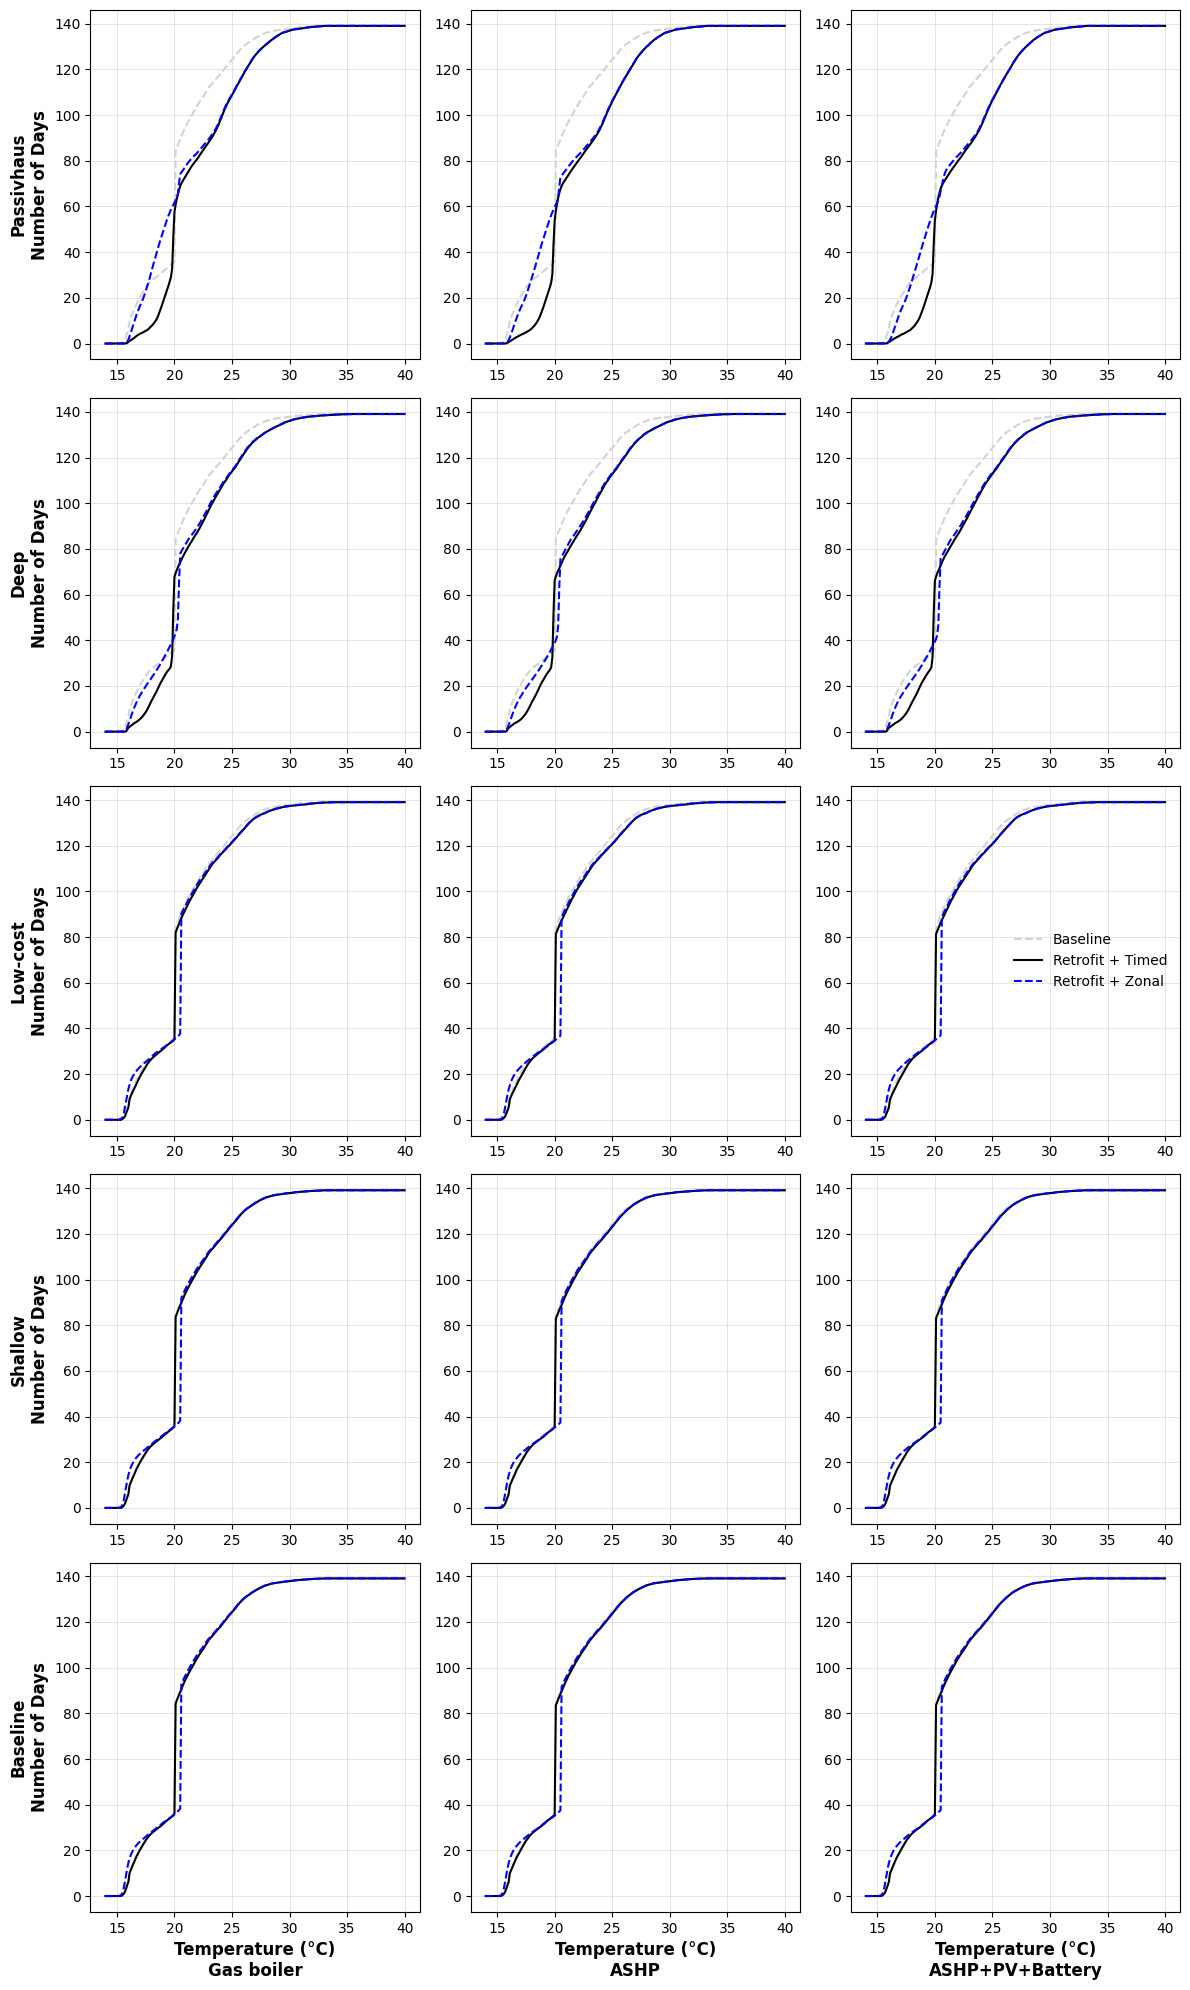

In [16]:
plot_figure(temp_type = 'air', hour_category = 'awake_hours')

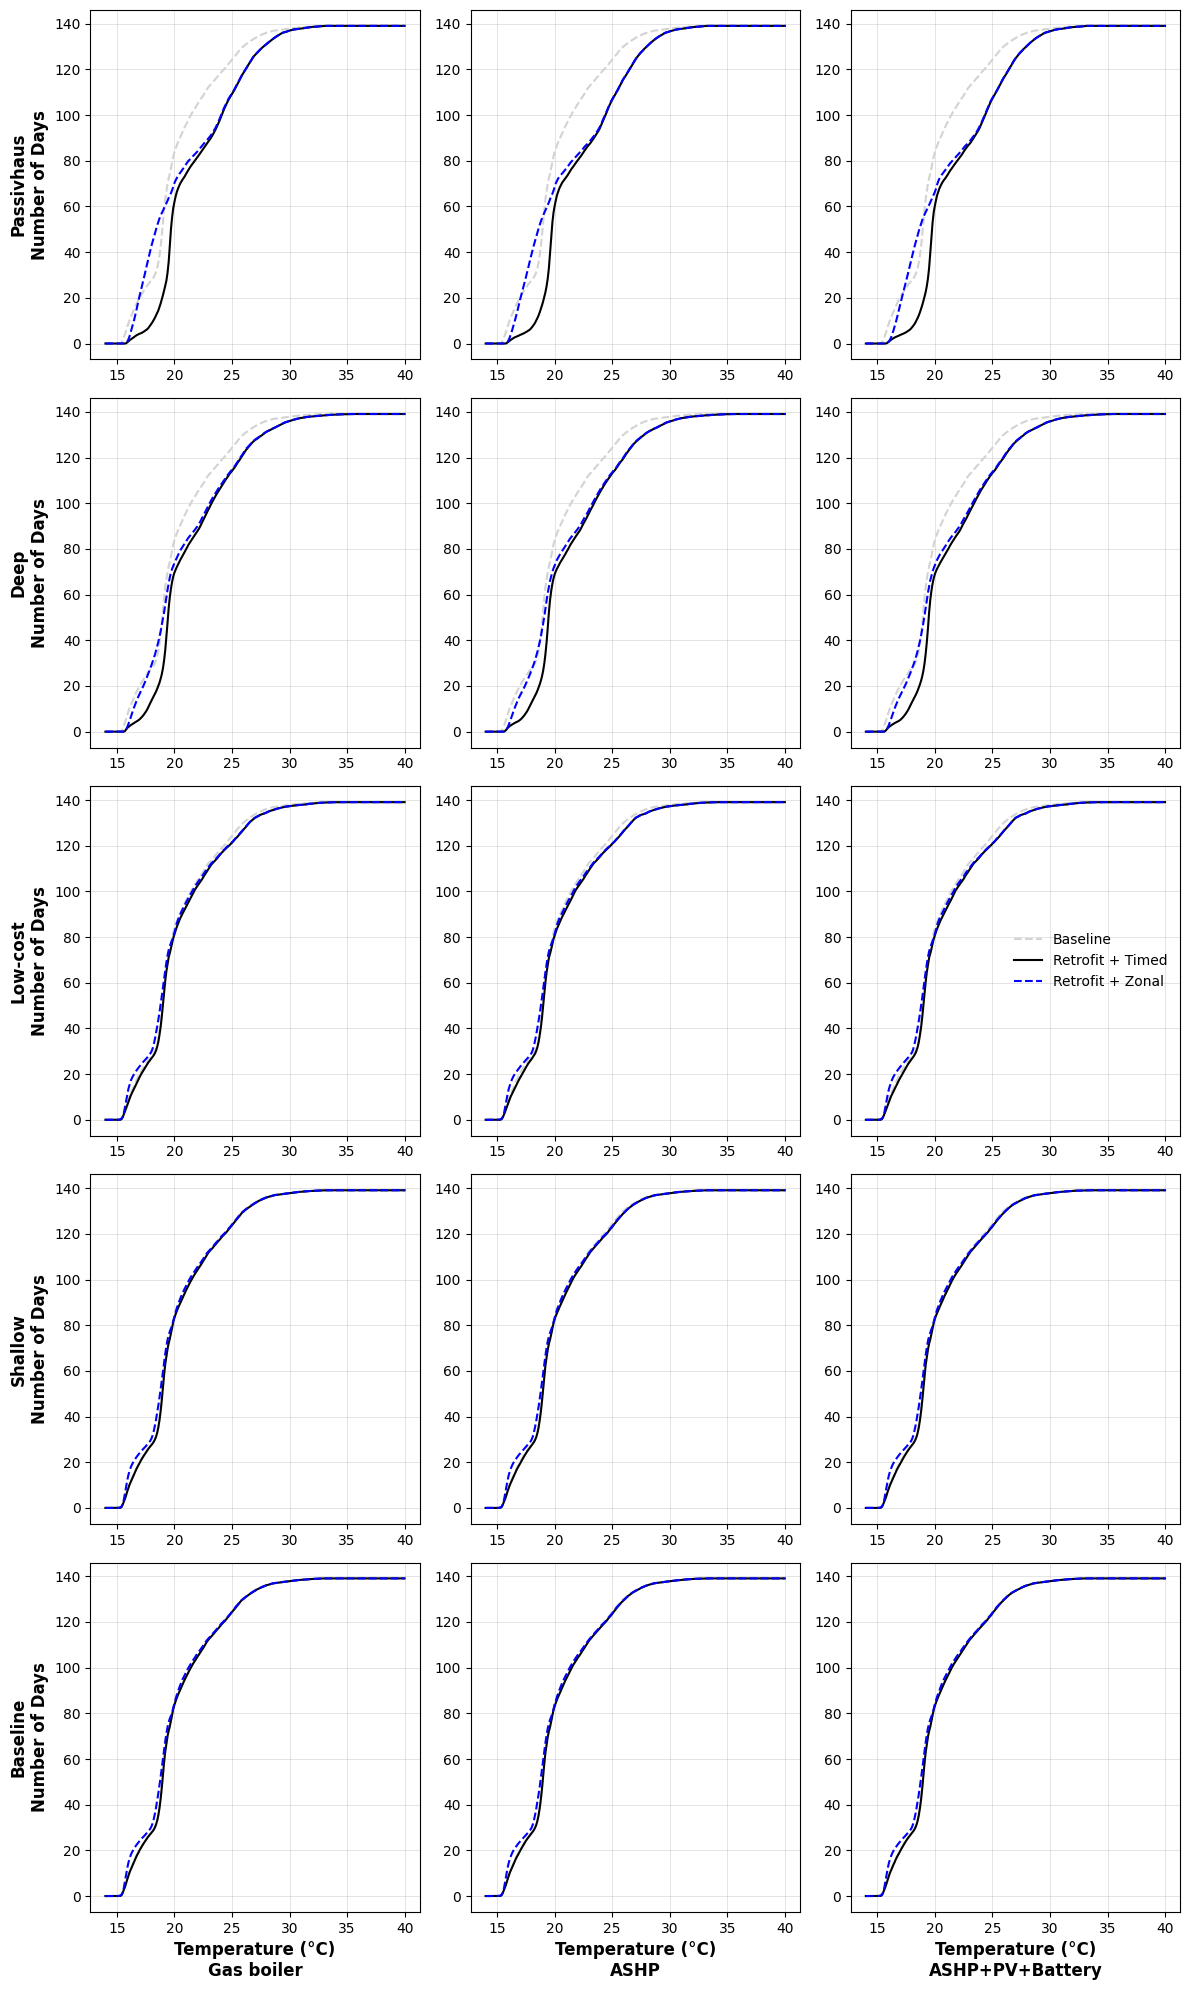

In [17]:
plot_figure(temp_type = 'opr', hour_category = 'awake_hours')

In [ ]:


# Function to calculate the combined counts and percentages
def calculate_combined_percentage(in_df, out_df, count_df_in, count_df_out):
    combined_data = []
    for zone in in_df['zone']:
        in_percentage = in_df.loc[in_df['zone'] == zone, 'Percentage_Time'].values[0]
        out_percentage = out_df.loc[out_df['zone'] == zone, 'Percentage_Time'].values[0]
        in_count = count_df_in.loc[count_df_in['zone'] == zone, 'total_count'].values[0]
        out_count = count_df_out.loc[count_df_out['zone'] == zone, 'total_count'].values[0]
        actual_in_time = np.array(in_percentage) * in_count
        actual_out_time = np.array(out_percentage) * out_count
        total_time_at_temp = actual_in_time + actual_out_time
        percentage_time = (total_time_at_temp / minutes_in_year) * 100
        combined_data.append({
            'zone': zone,
            'Temperature': in_df.loc[in_df['zone'] == zone, 'Temperature'].values[0],
            'Percentage_Time': percentage_time.tolist(),
            'total_count': in_count + out_count
        })
    return pd.DataFrame(combined_data)

# Function to calculate the weighted average percentage time across rooms
def calculate_weighted_percentage(df, zone_to_area, total_floor_area,):
    total_weighted_time = np.zeros(len(df['Temperature'].iloc[0]))
    for _, row in df.iterrows():
        zone = row['zone']
        area = zone_to_area.get(zone, 0)
        total_count = row['total_count']
        weighted_time = (np.array(row['Percentage_Time']) * total_count) * (area / total_floor_area)
        total_weighted_time += weighted_time
    weighted_percentage = total_weighted_time / minutes_in_year
    return weighted_percentage

# Number of minutes in a year (non-leap year)
minutes_in_year = 525600 * (17/24)

# Room areas
room_areas = {
    'front_room': 14.04,
    'kitchen': 11.34,
    'backroom': 11.34,
    'hall_downstairs': 7.02,
    'bedroom_1': 11.51,
    'bedroom_2': 12.39,
    'bedroom_3': 6.86,
    'bathroom': 7.105,
    'hall_upstairs': 5.88
}
total_floor_area = sum(room_areas.values())

# Map zones to room areas
zone_to_area = {
    'front_room': room_areas['front_room'],
    'kitchen': room_areas['kitchen'],
    'backroom': room_areas['backroom'],
    'hall_downstairs': room_areas['hall_downstairs'],
    'bedroom_1': room_areas['bedroom_1'],
    'bedroom_2': room_areas['bedroom_2'],
    'bedroom_3': room_areas['bedroom_3'],
    'bathroom': room_areas['bathroom'],
    'hall_upstairs': room_areas['hall_upstairs'],
}


def plot_figure(temp_type):
    if temp_type == "air":
        temp_type = f"{temp_type}_temp"
    else:
        temp_type = "operative_temp"

    # Create the 5x3 plot grid
    fig, axes = plt.subplots(3, 5, figsize=(20, 12))
    axes = axes.flatten()

    # Define the order of cases for the rows
    case_order = [10, 11, 12, 13, 14, 5, 6, 7, 8, 9, 0, 1, 2, 3, 4]

    # Load the data for case 0, zone 0 and calculate its weighted percentage time
    data_case_0_zone_0 = load_json_file("temp",0, zone_number=0)

    df_in_hours_air_temp_percentage_0 = json_normalise_temperature(pd.DataFrame(data_case_0_zone_0['in_hours'][f'{temp_type}']['percentage_time'].items(), columns=['zone', 'percentage_time']))
    df_out_of_hours_air_temp_percentage_0 = json_normalise_temperature(pd.DataFrame(data_case_0_zone_0['out_of_hours'][f'{temp_type}']['percentage_time'].items(), columns=['zone', 'percentage_time']))
    df_in_hours_air_temp_count_0 = pd.DataFrame(data_case_0_zone_0['in_hours'][f'{temp_type}']['total_count'].items(), columns=['zone', 'total_count'])
    df_out_of_hours_air_temp_count_0 = pd.DataFrame(data_case_0_zone_0['out_of_hours'][f'{temp_type}']['total_count'].items(), columns=['zone', 'total_count'])

    # Calculate the combined percentage time for case 0, zone 0
    df_combined_air_temp_percentage_0 = calculate_combined_percentage(
        df_in_hours_air_temp_percentage_0,
        df_out_of_hours_air_temp_percentage_0,
        df_in_hours_air_temp_count_0,
        df_out_of_hours_air_temp_count_0
    )

    # Calculate the weighted percentage time for case 0, zone 0 air temperature
    weighted_percentage_air_temp_0 = calculate_weighted_percentage(df_combined_air_temp_percentage_0, zone_to_area, total_floor_area)

    # Get the temperature range for case 0, zone 0
    temperature_range_0 = df_combined_air_temp_percentage_0['Temperature'].iloc[0]

    # Loop over the cases from 0 to 14, but use case_order to assign them to subplots
    for i, case_number in enumerate(case_order):
        # Load the JSON data for the current case, zone 0 and zone 9
        data_zone_0 = load_json_file("temp",case_number, zone_number=0)  # For zone 0
        data_zone_9 = load_json_file("temp",case_number, zone_number=9)  # For zone 9

        # Normalise the temperature data for zone 0
        df_in_hours_air_temp_percentage_0_case = json_normalise_temperature(pd.DataFrame(data_zone_0['in_hours'][f'{temp_type}']['percentage_time'].items(), columns=['zone', 'percentage_time']))
        df_out_of_hours_air_temp_percentage_0_case = json_normalise_temperature(pd.DataFrame(data_zone_0['out_of_hours'][f'{temp_type}']['percentage_time'].items(), columns=['zone', 'percentage_time']))
        df_in_hours_air_temp_count_0_case = pd.DataFrame(data_zone_0['in_hours'][f'{temp_type}']['total_count'].items(), columns=['zone', 'total_count'])
        df_out_of_hours_air_temp_count_0_case = pd.DataFrame(data_zone_0['out_of_hours'][f'{temp_type}']['total_count'].items(), columns=['zone', 'total_count'])

        # Normalise the temperature data for zone 9
        df_in_hours_air_temp_percentage_9_case = json_normalise_temperature(pd.DataFrame(data_zone_9['in_hours'][f'{temp_type}']['percentage_time'].items(), columns=['zone', 'percentage_time']))
        df_out_of_hours_air_temp_percentage_9_case = json_normalise_temperature(pd.DataFrame(data_zone_9['out_of_hours'][f'{temp_type}']['percentage_time'].items(), columns=['zone', 'percentage_time']))
        df_in_hours_air_temp_count_9_case = pd.DataFrame(data_zone_9['in_hours'][f'{temp_type}']['total_count'].items(), columns=['zone', 'total_count'])
        df_out_of_hours_air_temp_count_9_case = pd.DataFrame(data_zone_9['out_of_hours'][f'{temp_type}']['total_count'].items(), columns=['zone', 'total_count'])

        # Calculate the combined percentage time for zone 0 and zone 9 of the current case
        df_combined_air_temp_percentage_0_case = calculate_combined_percentage(
            df_in_hours_air_temp_percentage_0_case,
            df_out_of_hours_air_temp_percentage_0_case,
            df_in_hours_air_temp_count_0_case,
            df_out_of_hours_air_temp_count_0_case
        )
        df_combined_air_temp_percentage_9_case = calculate_combined_percentage(
            df_in_hours_air_temp_percentage_9_case,
            df_out_of_hours_air_temp_percentage_9_case,
            df_in_hours_air_temp_count_9_case,
            df_out_of_hours_air_temp_count_9_case
        )

        # Calculate the weighted percentage time for zone 0 and zone 9 of the current case
        weighted_percentage_air_temp_0_case = calculate_weighted_percentage(df_combined_air_temp_percentage_0_case, zone_to_area, total_floor_area)
        weighted_percentage_air_temp_9_case = calculate_weighted_percentage(df_combined_air_temp_percentage_9_case, zone_to_area, total_floor_area)

        # Get the temperature range for the current case (zone 0 and zone 9 use the same range)
        temperature_range_case = df_combined_air_temp_percentage_0_case['Temperature'].iloc[0]

        # Plot the results on the subplot for this case
        ax = axes[i]  # Use the current index 'i' in the axes array

        # Plot case 0, zone 0 data as a light grey dashed line in all subplots
        ax.plot(temperature_range_0, weighted_percentage_air_temp_0, color='lightgray', linestyle='--', label='Case 0, Zone 0')

        # Plot the current case, zone 0 data as a solid black line
        ax.plot(temperature_range_case, weighted_percentage_air_temp_0_case, color='black', label=f'Case {case_number}, Zone 0')

        # Plot the current case, zone 9 data as a solid blue line
        ax.plot(temperature_range_case, weighted_percentage_air_temp_9_case, color='blue',linestyle='--', label=f'Case {case_number}, Zone 9')

        ax.set_title(f'Case {case_number}')
        ax.set_xlabel('Temperature (°C)')
        ax.set_ylabel('Weighted Percentage Time (%)')
        ax.grid(True)

    # Adjust the layout and display the plot
    plt.tight_layout()
    plt.show()


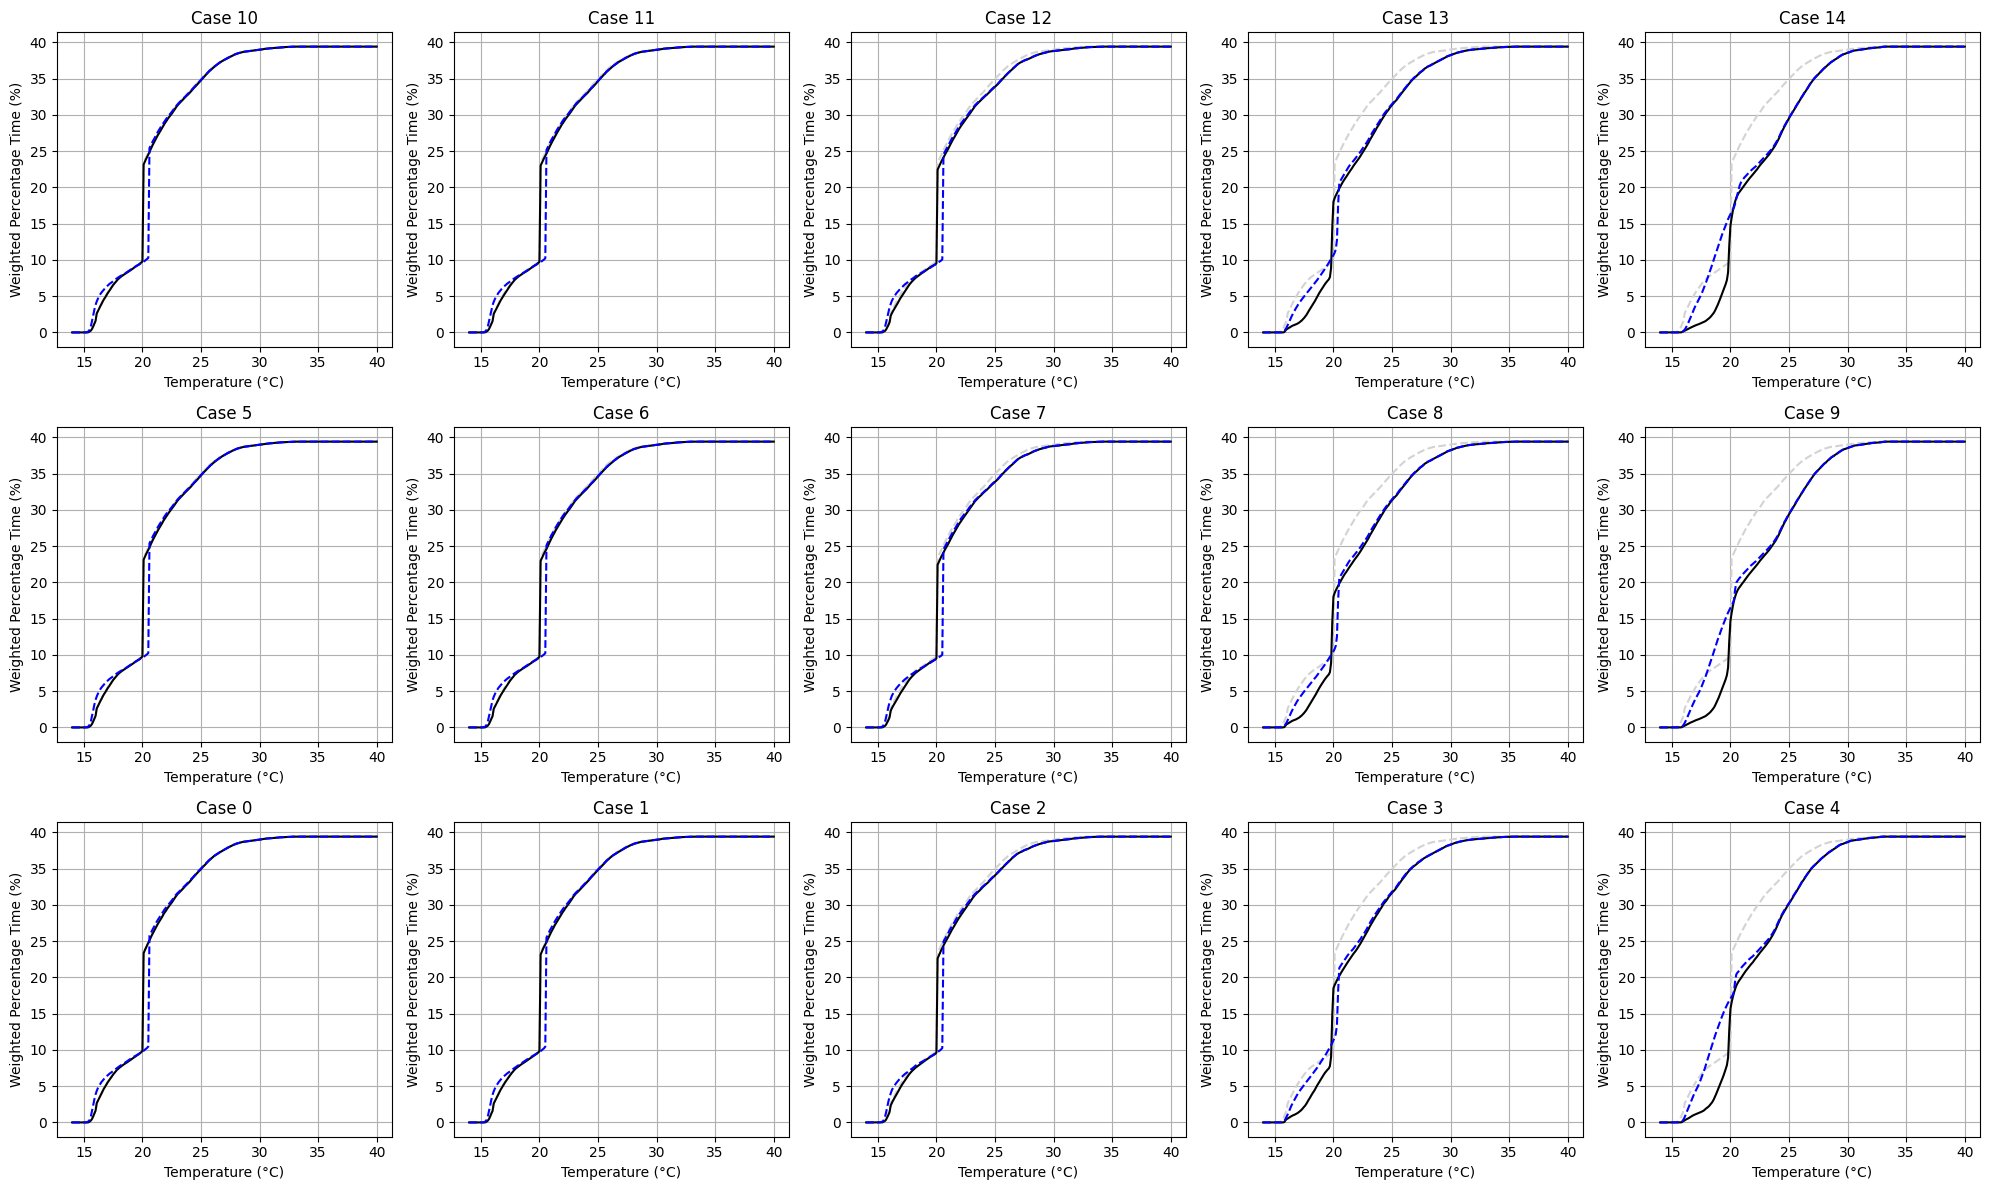

In [28]:
plot_figure("air")

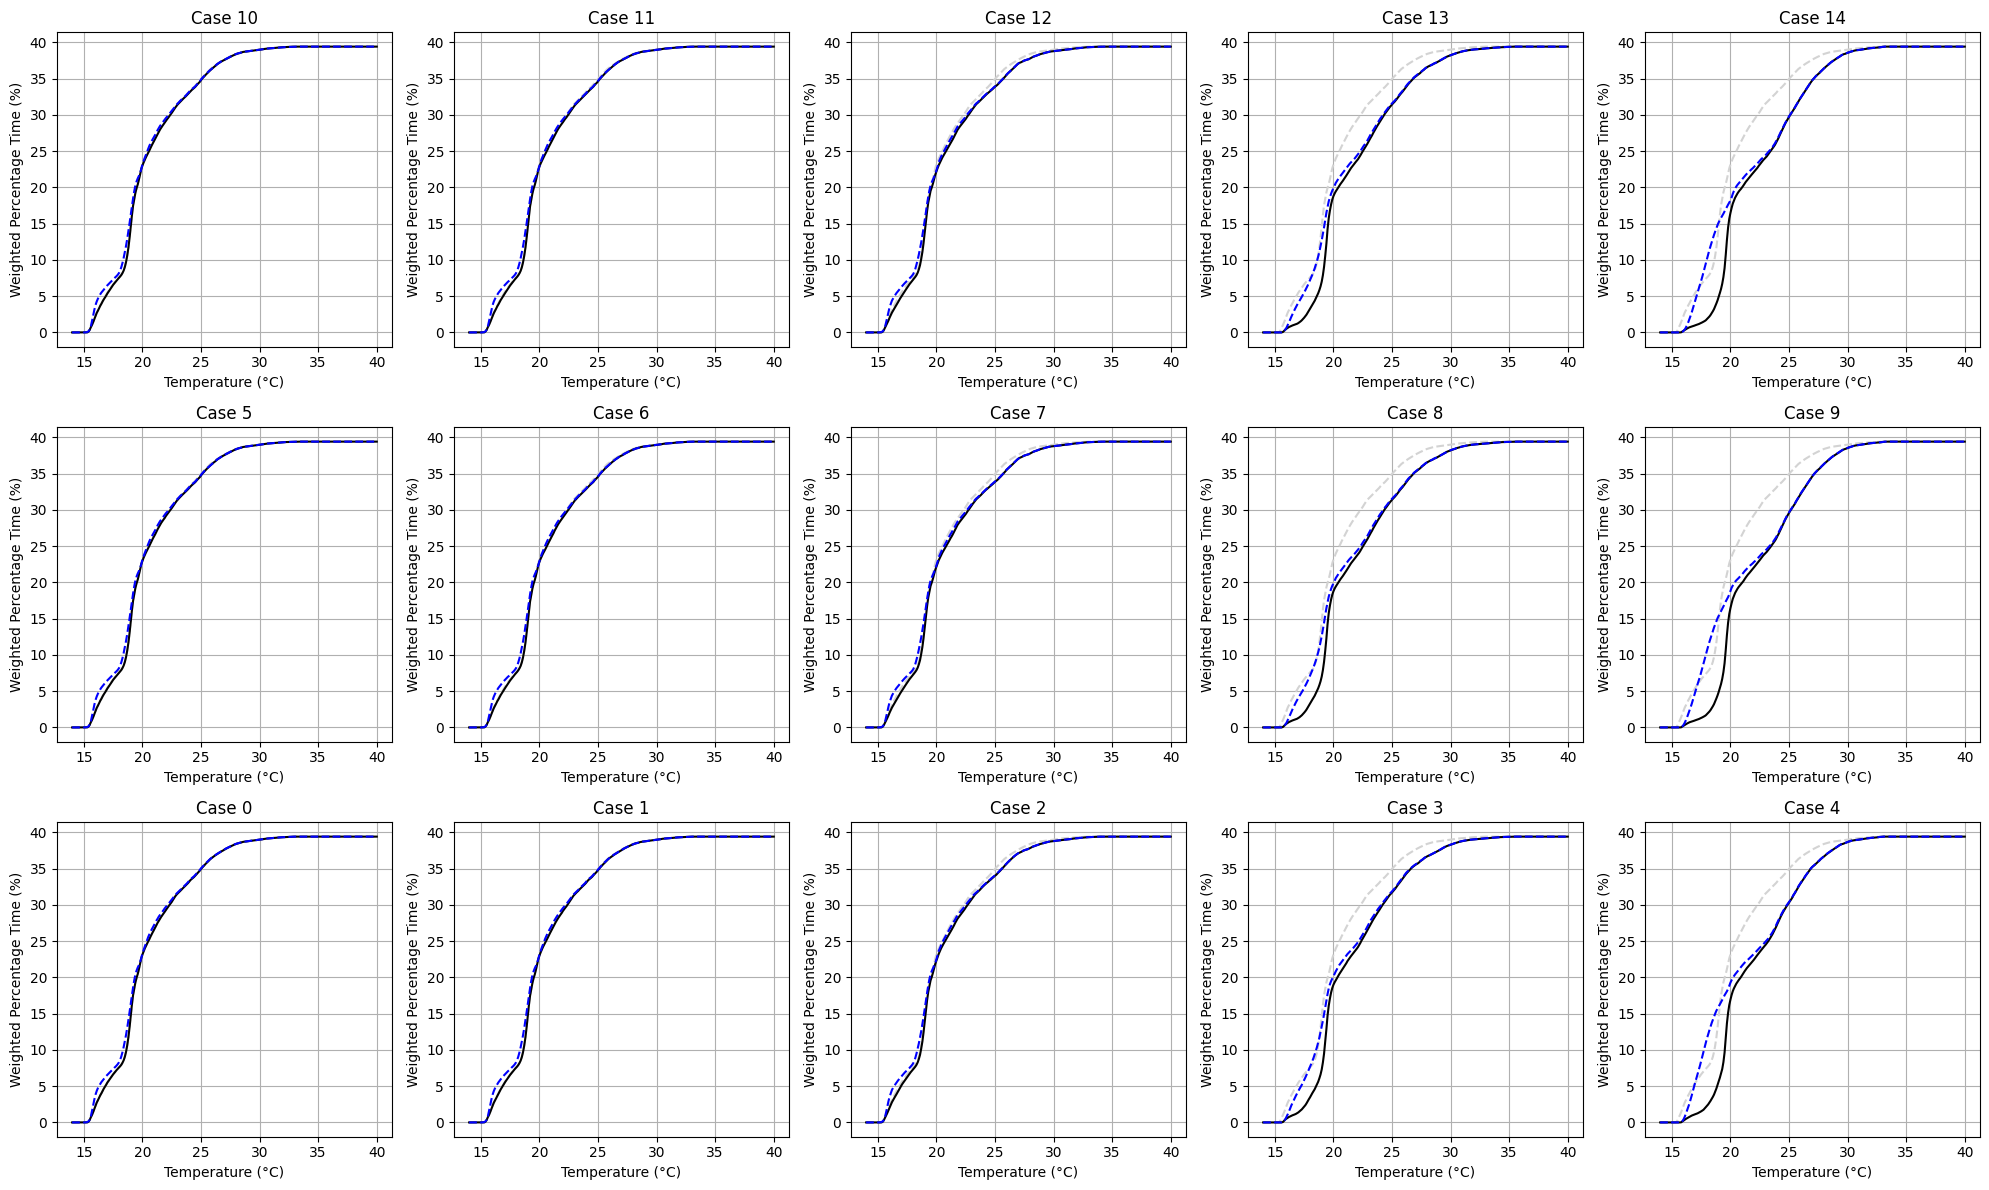

In [29]:
plot_figure("opr")

#### Single case, all rooms, temp distribution OUTDATED

In [32]:

# def plot_single_case_temp(case_number, plot_zone_9=False):

#     # Load the JSON data for the specified case and zone 0
#     data_case_zone_0 = load_json_file("temp", case_number, zone_number=0)

#     # Normalise the air temperature data for zone 0
#     df_in_hours_air_zone_0 = json_normalise_temperature(pd.DataFrame(data_case_zone_0['in_hours']['air_temp']['percentage_time'].items(), columns=['zone', 'percentage_time']))
#     df_out_of_hours_air_zone_0 = json_normalise_temperature(pd.DataFrame(data_case_zone_0['out_of_hours']['air_temp']['percentage_time'].items(), columns=['zone', 'percentage_time']))

#     # Normalise the operative temperature data for zone 0
#     df_in_hours_opr_zone_0 = json_normalise_temperature(pd.DataFrame(data_case_zone_0['in_hours']['operative_temp']['percentage_time'].items(), columns=['zone', 'percentage_time']))
#     df_out_of_hours_opr_zone_0 = json_normalise_temperature(pd.DataFrame(data_case_zone_0['out_of_hours']['operative_temp']['percentage_time'].items(), columns=['zone', 'percentage_time']))

#     # Combine air and operative temp for zone 0 into one DataFrame for ease
#     df_combined_air_temp_zone_0 = pd.concat([df_in_hours_air_zone_0, df_out_of_hours_air_zone_0])
#     df_combined_opr_temp_zone_0 = pd.concat([df_in_hours_opr_zone_0, df_out_of_hours_opr_zone_0])

#     # Optionally load and normalise the data for zone 9 if required
#     if plot_zone_9:
#         data_case_zone_9 = load_json_file("temp", case_number, zone_number=9)

#         # Normalise the air temperature data for zone 9
#         df_in_hours_air_zone_9 = json_normalise_temperature(pd.DataFrame(data_case_zone_9['in_hours']['air_temp']['percentage_time'].items(), columns=['zone', 'percentage_time']))
#         df_out_of_hours_air_zone_9 = json_normalise_temperature(pd.DataFrame(data_case_zone_9['out_of_hours']['air_temp']['percentage_time'].items(), columns=['zone', 'percentage_time']))

#         # Normalise the operative temperature data for zone 9
#         df_in_hours_opr_zone_9 = json_normalise_temperature(pd.DataFrame(data_case_zone_9['in_hours']['operative_temp']['percentage_time'].items(), columns=['zone', 'percentage_time']))
#         df_out_of_hours_opr_zone_9 = json_normalise_temperature(pd.DataFrame(data_case_zone_9['out_of_hours']['operative_temp']['percentage_time'].items(), columns=['zone', 'percentage_time']))

#         # Combine air and operative temp for zone 9
#         df_combined_air_temp_zone_9 = pd.concat([df_in_hours_air_zone_9, df_out_of_hours_air_zone_9])
#         df_combined_opr_temp_zone_9 = pd.concat([df_in_hours_opr_zone_9, df_out_of_hours_opr_zone_9])

#     # Create 3x3 subplot grid
#     fig, axes = plt.subplots(3, 3, figsize=(15, 12))
#     axes = axes.flatten()

#     # Plot each zone's air and operative temperatures for zone 0 and optionally zone 9
#     # Room areas
#     room_areas = {
#         'kitchen': 11.34,
#         'front_room': 14.04,
#         'backroom': 11.34,
#         'hall_downstairs': 7.02,
#         'bedroom_1': 11.51,
#         'bedroom_2': 12.39,
#         'bedroom_3': 6.86,
#         'bathroom': 7.105,
#         'hall_upstairs': 5.88
#     }

#     for i, zone in enumerate(room_areas.keys()):
#         if i < 9:  # Limit to the first 9 zones for 3x3 grid
#             # Filter data for the current zone (zone 0)
#             zone_air_temp_zone_0 = df_combined_air_temp_zone_0[df_combined_air_temp_zone_0['zone'] == zone]
#             zone_opr_temp_zone_0 = df_combined_opr_temp_zone_0[df_combined_opr_temp_zone_0['zone'] == zone]

#             ax = axes[i]

#             # Plot air and operative temperatures for zone 0
#             ax.plot(zone_air_temp_zone_0['Temperature'].iloc[0], zone_air_temp_zone_0['Percentage_Time'].iloc[0], label='Air Temp (Zone 0)', color='black', linestyle='--')
#             ax.plot(zone_opr_temp_zone_0['Temperature'].iloc[0], zone_opr_temp_zone_0['Percentage_Time'].iloc[0], label='Operative Temp (Zone 0)', color='black')

#             # Optionally plot zone 9 data in the same subplot with the same colours
#             if plot_zone_9:
#                 # Filter data for the current zone (zone 9)
#                 zone_air_temp_zone_9 = df_combined_air_temp_zone_9[df_combined_air_temp_zone_9['zone'] == zone]
#                 zone_opr_temp_zone_9 = df_combined_opr_temp_zone_9[df_combined_opr_temp_zone_9['zone'] == zone]

#                 # Plot air and operative temperatures for zone 9 in the same subplot
#                 ax.plot(zone_air_temp_zone_9['Temperature'].iloc[0], zone_air_temp_zone_9['Percentage_Time'].iloc[0], label='Air Temp (Zone 9)', color='blue', linestyle='--')
#                 ax.plot(zone_opr_temp_zone_9['Temperature'].iloc[0], zone_opr_temp_zone_9['Percentage_Time'].iloc[0], label='Operative Temp (Zone 9)', color='blue', )

#             # Replace underscores with spaces and capitalise each word in the zone name
#             formatted_zone_name = zone.replace('_', ' ').title()
#             ax.set_title(f'{formatted_zone_name}')

#             ax.set_xlabel('Temperature (°C)')
#             ax.set_ylabel('Percentage Time (%)')
#             ax.grid(True)
#             if i == 5:
#                 ax.legend(loc='center right', frameon=False)

#     # Adjust the layout and display the plot
#     plt.tight_layout()
#     plt.show()

# plot_single_case_temp(0,True)


#### Background check on math for room weighting

In [ ]:
# mins_in_year = 24*60*365
# data_case_zone_0 = load_json_file("temp", 0, zone_number=0)

# # Load in-hours data
# df_in_hours_air = json_normalise_temperature(pd.DataFrame(data_case_zone_0['in_hours']['air_temp']['percentage_time'].items(), columns=['zone', 'percentage_time']))
# df_in_hours_air_count = pd.DataFrame(data_case_zone_0['in_hours']['air_temp']['total_count'].items(), columns=['zone', 'total_count'])

# df_air_in_hour = pd.merge(df_in_hours_air, df_in_hours_air_count)

# df_air_in_hour['Counts_Time'] = df_air_in_hour.apply(
#     lambda row: [(pt * row['total_count']) / 100 for pt in row['Percentage_Time']], axis=1
# )

# df_air_in_hour['Days_in_Year'] = df_air_in_hour.apply(
#     lambda row: [((pt / mins_in_year) * 365) for pt in row['Counts_Time']], axis=1
# )

# # Load out-of-hours data
# df_out_of_hours_air = json_normalise_temperature(pd.DataFrame(data_case_zone_0['out_of_hours']['air_temp']['percentage_time'].items(), columns=['zone', 'percentage_time']))
# df_out_of_hours_air_count = pd.DataFrame(data_case_zone_0['out_of_hours']['air_temp']['total_count'].items(), columns=['zone', 'total_count'])

# df_air_out_of_hour = pd.merge(df_out_of_hours_air, df_out_of_hours_air_count)

# df_air_out_of_hour['Counts_Time'] = df_air_out_of_hour.apply(
#     lambda row: [(pt * row['total_count']) / 100 for pt in row['Percentage_Time']], axis=1
# )

# df_air_out_of_hour['Days_in_Year'] = df_air_out_of_hour.apply(
#     lambda row: [((pt / mins_in_year) * 365) for pt in row['Counts_Time']], axis=1
# )

# # Combine in-hours and out-of-hours data for Days_in_Year by summing element-wise
# df_air_combined = pd.DataFrame()
# df_air_combined["zone"] = df_air_in_hour["zone"]

# df_air_combined["Days_in_Year"] = df_air_in_hour.apply(
#     lambda row: [a + b for a, b in zip(row['Days_in_Year'], df_air_out_of_hour.loc[df_air_out_of_hour['zone'] == row['zone'], 'Days_in_Year'].values[0])],
#     axis=1
# )


In [44]:
import pandas as pd
import matplotlib.pyplot as plt

def load_json_file(file_type, case_number, zone_number):
    # Use glob to find the correct file path dynamically
    json_file_pattern = f'{base_dir}/case_{case_number}_year_2023_rep_H28_zone_{zone_number}_*/{file_type}.json'

    # Get the list of files that match the pattern
    matching_files = glob.glob(json_file_pattern)

    # Load and return the JSON data from the matched file
    with open(matching_files[0], 'r') as file:
        return json.load(file)

# Function to normalise JSON data
def json_normalise_temperature(df):
    df[['Temperature', 'Percentage_Time']] = pd.json_normalize(df['percentage_time'])
    df = df.drop(columns=['percentage_time'])
    return df

# Function to calculate the combined counts and percentages
def calculate_combined_percentage(in_df, out_df, count_df_in, count_df_out):
    combined_data = []
    for zone in in_df['zone']:
        in_percentage = in_df.loc[in_df['zone'] == zone, 'Percentage_Time'].values[0]
        out_percentage = out_df.loc[out_df['zone'] == zone, 'Percentage_Time'].values[0]
        in_count = count_df_in.loc[count_df_in['zone'] == zone, 'total_count'].values[0]
        out_count = count_df_out.loc[count_df_out['zone'] == zone, 'total_count'].values[0]
        actual_in_time = np.array(in_percentage) * in_count
        actual_out_time = np.array(out_percentage) * out_count
        total_time_at_temp = actual_in_time + actual_out_time
        percentage_time = (total_time_at_temp / minutes_in_year) * 100
        combined_data.append({
            'zone': zone,
            'Temperature': in_df.loc[in_df['zone'] == zone, 'Temperature'].values[0],
            'Percentage_Time': percentage_time.tolist(),
            'total_count': in_count + out_count
        })
    return pd.DataFrame(combined_data)

# Function to calculate the weighted average percentage time across rooms
def calculate_weighted_percentage(df, zone_to_area, total_floor_area,):
    total_weighted_time = np.zeros(len(df['Temperature'].iloc[0]))
    for _, row in df.iterrows():
        zone = row['zone']
        area = zone_to_area.get(zone, 0)
        total_count = row['total_count']
        weighted_time = (np.array(row['Percentage_Time']) * total_count) * (area / total_floor_area)
        total_weighted_time += weighted_time
    weighted_percentage = total_weighted_time / minutes_in_year
    return weighted_percentage

# Number of minutes in a year (non-leap year)
minutes_in_year = 525600 * (17/24)

# Room areas
room_areas = {
    'front_room': 14.04,
    'kitchen': 11.34,
    'backroom': 11.34,
    'hall_downstairs': 7.02,
    'bedroom_1': 11.51,
    'bedroom_2': 12.39,
    'bedroom_3': 6.86,
    'bathroom': 7.105,
    'hall_upstairs': 5.88
}
total_floor_area = sum(room_areas.values())

# Map zones to room areas
zone_to_area = {
    'front_room': room_areas['front_room'],
    'kitchen': room_areas['kitchen'],
    'backroom': room_areas['backroom'],
    'hall_downstairs': room_areas['hall_downstairs'],
    'bedroom_1': room_areas['bedroom_1'],
    'bedroom_2': room_areas['bedroom_2'],
    'bedroom_3': room_areas['bedroom_3'],
    'bathroom': room_areas['bathroom'],
    'hall_upstairs': room_areas['hall_upstairs'],
}

def plot_single_case_temp(case_number, plot_zone_9=False):

    # Load the JSON data for the specified case and zone 0
    data_case_zone_0 = load_json_file("temp", case_number, zone_number=0)

    # Normalise the air temperature data for zone 0
    df_in_hours_air_zone_0 = json_normalise_temperature(pd.DataFrame(data_case_zone_0['in_hours']['air_temp']['percentage_time'].items(), columns=['zone', 'percentage_time']))
    df_out_of_hours_air_zone_0 = json_normalise_temperature(pd.DataFrame(data_case_zone_0['out_of_hours']['air_temp']['percentage_time'].items(), columns=['zone', 'percentage_time']))
    df_in_hours_air_count_zone_0 = pd.DataFrame(data_case_zone_0['in_hours']['air_temp']['total_count'].items(), columns=['zone', 'total_count'])
    df_out_of_hours_air_count_zone_0 = pd.DataFrame(data_case_zone_0['out_of_hours']['air_temp']['total_count'].items(), columns=['zone', 'total_count'])

    # Normalise the operative temperature data for zone 0
    df_in_hours_opr_zone_0 = json_normalise_temperature(pd.DataFrame(data_case_zone_0['in_hours']['operative_temp']['percentage_time'].items(), columns=['zone', 'percentage_time']))
    df_out_of_hours_opr_zone_0 = json_normalise_temperature(pd.DataFrame(data_case_zone_0['out_of_hours']['operative_temp']['percentage_time'].items(), columns=['zone', 'percentage_time']))
    df_in_hours_opr_count_zone_0 = pd.DataFrame(data_case_zone_0['in_hours']['operative_temp']['total_count'].items(), columns=['zone', 'total_count'])
    df_out_of_hours_opr_count_zone_0 = pd.DataFrame(data_case_zone_0['out_of_hours']['operative_temp']['total_count'].items(), columns=['zone', 'total_count'])

    # Optionally load and normalise the data for zone 9 if required
    if plot_zone_9:
        data_case_zone_9 = load_json_file("temp", case_number, zone_number=9)

        # Normalise the air temperature data for zone 9
        df_in_hours_air_zone_9 = json_normalise_temperature(pd.DataFrame(data_case_zone_9['in_hours']['air_temp']['percentage_time'].items(), columns=['zone', 'percentage_time']))
        df_out_of_hours_air_zone_9 = json_normalise_temperature(pd.DataFrame(data_case_zone_9['out_of_hours']['air_temp']['percentage_time'].items(), columns=['zone', 'percentage_time']))
        df_in_hours_air_count_zone_9 = pd.DataFrame(data_case_zone_9['in_hours']['air_temp']['total_count'].items(), columns=['zone', 'total_count'])
        df_out_of_hours_air_count_zone_9 = pd.DataFrame(data_case_zone_9['out_of_hours']['air_temp']['total_count'].items(), columns=['zone', 'total_count'])

        # Normalise the operative temperature data for zone 9
        df_in_hours_opr_zone_9 = json_normalise_temperature(pd.DataFrame(data_case_zone_9['in_hours']['operative_temp']['percentage_time'].items(), columns=['zone', 'percentage_time']))
        df_out_of_hours_opr_zone_9 = json_normalise_temperature(pd.DataFrame(data_case_zone_9['out_of_hours']['operative_temp']['percentage_time'].items(), columns=['zone', 'percentage_time']))
        df_in_hours_opr_count_zone_9 = pd.DataFrame(data_case_zone_9['in_hours']['operative_temp']['total_count'].items(), columns=['zone', 'total_count'])
        df_out_of_hours_opr_count_zone_9 = pd.DataFrame(data_case_zone_9['out_of_hours']['operative_temp']['total_count'].items(), columns=['zone', 'total_count'])

    # Calculate the combined percentage time for air temperature (zone 0)
    df_combined_air_temp_zone_0 = calculate_combined_percentage(
        df_in_hours_air_zone_0,
        df_out_of_hours_air_zone_0,
        df_in_hours_air_count_zone_0,
        df_out_of_hours_air_count_zone_0
    )

    # Calculate the combined percentage time for operative temperature (zone 0)
    df_combined_opr_temp_zone_0 = calculate_combined_percentage(
        df_in_hours_opr_zone_0,
        df_out_of_hours_opr_zone_0,
        df_in_hours_opr_count_zone_0,
        df_out_of_hours_opr_count_zone_0
    )

    # If zone 9 is being plotted, calculate the percentage time for air and operative temps for zone 9
    if plot_zone_9:
        df_combined_air_temp_zone_9 = calculate_combined_percentage(
            df_in_hours_air_zone_9,
            df_out_of_hours_air_zone_9,
            df_in_hours_air_count_zone_9,
            df_out_of_hours_air_count_zone_9
        )
        df_combined_opr_temp_zone_9 = calculate_combined_percentage(
            df_in_hours_opr_zone_9,
            df_out_of_hours_opr_zone_9,
            df_in_hours_opr_count_zone_9,
            df_out_of_hours_opr_count_zone_9
        )

    # Calculate the weighted percentage time for both air and operative temperatures
    weighted_percentage_air_temp_zone_0 = calculate_weighted_percentage(df_combined_air_temp_zone_0, zone_to_area, total_floor_area)
    weighted_percentage_opr_temp_zone_0 = calculate_weighted_percentage(df_combined_opr_temp_zone_0, zone_to_area, total_floor_area)

    if plot_zone_9:
        weighted_percentage_air_temp_zone_9 = calculate_weighted_percentage(df_combined_air_temp_zone_9, zone_to_area, total_floor_area)
        weighted_percentage_opr_temp_zone_9 = calculate_weighted_percentage(df_combined_opr_temp_zone_9, zone_to_area, total_floor_area)

    # Get the temperature range (assuming both air and operative temp have the same range)
    temperature_range_air = df_combined_air_temp_zone_0['Temperature'].iloc[0]
    temperature_range_opr = df_combined_opr_temp_zone_0['Temperature'].iloc[0]

    # Plot the cumulative temperature for air and operative temp (zone 0)
    plt.figure(figsize=(10, 6))
    plt.plot(temperature_range_air, weighted_percentage_air_temp_zone_0, color='black', linestyle=':', label='Air Temperature (Zone 0)')
    plt.plot(temperature_range_opr, weighted_percentage_opr_temp_zone_0, color='black',  label='Operative Temperature (Zone 0)')

    # If plotting zone 9, plot those temperatures on the same plot
    if plot_zone_9:
        plt.plot(temperature_range_air, weighted_percentage_air_temp_zone_9, color='blue', linestyle=':',  label='Air Temperature (Zone 9)')
        plt.plot(temperature_range_opr, weighted_percentage_opr_temp_zone_9, color='blue',  label='Operative Temperature (Zone 9)')

    plt.xticks(ticks=range(14, int(max(temperature_range_air)) + 2, 2))

    plt.xlabel('Temperature (°C)')
    plt.ylabel('Percentage Time During Awake Hours (%)')
    plt.grid(True)
    plt.legend(loc='center right', frameon=False)

    # Display the plot
    plt.tight_layout()
    plt.show()


In [ ]:


def plot_single_case_temp(case_number, plot_zone_9=False, plot_type="combined"):

    # Load the JSON data for the specified case and zone 0
    data_case_zone_0 = load_json_file("temp", case_number, zone_number=0)

    # Normalise the air and operative temperature data for zone 0
    df_in_hours_opr_zone_0 = json_normalise_temperature(pd.DataFrame(data_case_zone_0['in_hours']['operative_temp']['percentage_time'].items(), columns=['zone', 'percentage_time']))

    df_in_hours_opr_count_zone_0 = pd.DataFrame(data_case_zone_0['in_hours']['operative_temp']['total_count'].items(), columns=['zone', 'total_count'])


    # Optionally load and normalise the data for zone 9 if required
    if plot_zone_9:
        data_case_zone_9 = load_json_file("temp", case_number, zone_number=9)

        df_in_hours_opr_zone_9 = json_normalise_temperature(pd.DataFrame(data_case_zone_9['in_hours']['operative_temp']['percentage_time'].items(), columns=['zone', 'percentage_time']))

        df_in_hours_opr_count_zone_9 = pd.DataFrame(data_case_zone_9['in_hours']['operative_temp']['total_count'].items(), columns=['zone', 'total_count'])


    # Choose which type of plot to create: "in_hours", "out_of_hours", or "combined"
    if plot_type == "in_hours":
        df_opr_zone_0 = df_in_hours_opr_zone_0
        df_opr_count_zone_0 = df_in_hours_opr_count_zone_0

        if plot_zone_9:
            df_opr_zone_9 = df_in_hours_opr_zone_9
            df_opr_count_zone_9 = df_in_hours_opr_count_zone_9

    # Calculate combined percentage time using the `calculate_combined_percentage` function
    def calculate_combined_percentage( df_opr,  count_df_opr):
        combined_data = []
        for zone in df_air['zone']:

            in_percentage_opr = df_opr.loc[df_opr['zone'] == zone, 'Percentage_Time'].values[0]

            in_count_opr = count_df_opr.loc[count_df_opr['zone'] == zone, 'total_count'].values[0]

            # Calculate actual in-time for each temperature based on counts

            actual_time_opr = np.array(in_percentage_opr) * in_count_opr

            # Total time at temperature
            total_time_opr = actual_time_opr

            # Calculate percentage of year for air and operative

            percentage_time_opr = (total_time_opr / minutes_in_year) * 100

            combined_data.append({
                'zone': zone,
                'Temperature': df_air.loc[df_air['zone'] == zone, 'Temperature'].values[0],
                'Percentage_Time_Air': percentage_time_air.tolist(),
                'Percentage_Time_Opr': percentage_time_opr.tolist()
            })

        return pd.DataFrame(combined_data)

    df_combined_zone_0 = calculate_combined_percentage( df_opr_zone_0,  df_opr_count_zone_0)

    if plot_zone_9:
        df_combined_zone_9 = calculate_combined_percentage(df_air_zone_9, df_opr_zone_9, df_air_count_zone_9, df_opr_count_zone_9)

    # Plot the cumulative temperature for air and operative temp (zone 0)
    plt.figure(figsize=(10, 6))
    plt.plot(df_combined_zone_0['Temperature'], df_combined_zone_0['Percentage_Time_Air'], color='black', linestyle=':', label='Air Temperature (Zone 0)')
    plt.plot(df_combined_zone_0['Temperature'], df_combined_zone_0['Percentage_Time_Opr'], color='black', label='Operative Temperature (Zone 0)')

    # If plotting zone 9, plot those temperatures

    # If plotting zone 9, plot those temperatures on the same plot
    if plot_zone_9:
        plt.plot(df_air_zone_9['Temperature'].iloc[0], df_air_zone_9['Percentage_Time'].iloc[0], color='blue', linestyle=':', label='Air Temperature (Zone 9)')
        plt.plot(df_opr_zone_9['Temperature'].iloc[0], df_opr_zone_9['Percentage_Time'].iloc[0], color='blue', label='Operative Temperature (Zone 9)')

    plt.xticks(ticks=range(14, int(max(df_air_zone_0['Temperature'].iloc[0])) + 2, 2))

    plt.xlabel('Temperature (°C)')
    plt.ylabel('Percentage Time During Awake Hours (%)')
    return df_air_zone_9



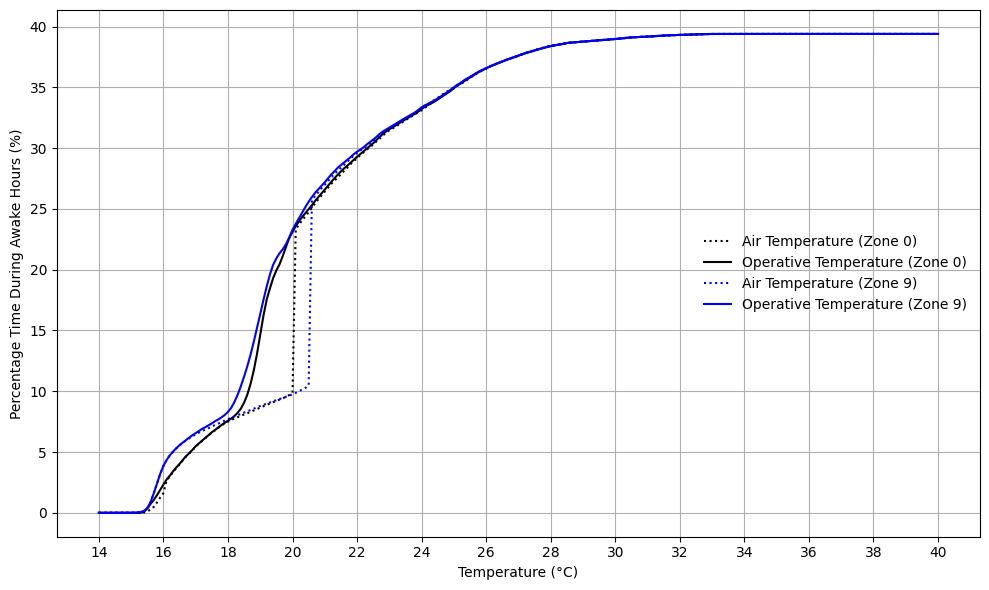

In [36]:
plot_single_case_temp(0, True)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Function to calculate the combined counts and percentages
def calculate_combined_count(in_df, out_df, count_df_in, count_df_out, hours="combined"):
    combined_data = []
    for zone in in_df['zone']:
        in_percentage = in_df.loc[in_df['zone'] == zone, 'Percentage_Time'].values[0]
        out_percentage = out_df.loc[out_df['zone'] == zone, 'Percentage_Time'].values[0]
        in_count = count_df_in.loc[count_df_in['zone'] == zone, 'total_count'].values[0]
        out_count = count_df_out.loc[count_df_out['zone'] == zone, 'total_count'].values[0]
        actual_in_time = np.array(in_percentage) * (in_count/100)
        actual_out_time = np.array(out_percentage) * (out_count/100)
        if hours == "in_hour":
            total_time_at_temp = actual_in_time
            count = in_count

        elif hours == "out_of_hours":
            total_time_at_temp =  actual_out_time
            count = out_count
        else:
            total_time_at_temp = actual_in_time + actual_out_time
            count = in_count + out_count

        #percentage_time = (total_time_at_temp / minutes_in_year) * 100
        combined_data.append({
            'zone': zone,
            'Temperature': in_df.loc[in_df['zone'] == zone, 'Temperature'].values[0],
            'counts': total_time_at_temp.tolist()
        })
    return pd.DataFrame(combined_data)

# Function to calculate the weighted average percentage time across rooms
def calculate_weighted_percentage(df, zone_to_area, total_floor_area):
    total_weighted_time = np.zeros(len(df['Temperature'].iloc[0]))
    for _, row in df.iterrows():
        zone = row['zone']
        area = zone_to_area.get(zone, 0)
        total_count = row['counts'].sum()
        weighted_time = (np.array(row['Percentage_Time']) * total_count) * (area / total_floor_area)
        total_weighted_time += weighted_time
    weighted_percentage = total_weighted_time / minutes_in_year
    return weighted_percentage

def plot_temp_for_cases(case_dict, hours):

    # Create a figure with two subplots (1 row, 2 columns)
    fig, axs = plt.subplots(1, 2, figsize=(14, 6))

    # Loop through the specified cases from the case dictionary
    for case_number, case_name in case_dict.items():
        # Load the JSON data for the specified case and zone 0
        data_case = load_json_file("temp", case_number, zone_number=0)

        # Normalise the air temperature data
        df_in_hours_air = json_normalise_temperature(pd.DataFrame(data_case['in_hours']['air_temp']['percentage_time'].items(), columns=['zone', 'percentage_time']))
        df_out_of_hours_air = json_normalise_temperature(pd.DataFrame(data_case['out_of_hours']['air_temp']['percentage_time'].items(), columns=['zone', 'percentage_time']))
        df_in_hours_air_count = pd.DataFrame(data_case['in_hours']['air_temp']['total_count'].items(), columns=['zone', 'total_count'])
        df_out_of_hours_air_count = pd.DataFrame(data_case['out_of_hours']['air_temp']['total_count'].items(), columns=['zone', 'total_count'])

        # Normalise the operative temperature data
        df_in_hours_opr = json_normalise_temperature(pd.DataFrame(data_case['in_hours']['operative_temp']['percentage_time'].items(), columns=['zone', 'percentage_time']))
        df_out_of_hours_opr = json_normalise_temperature(pd.DataFrame(data_case['out_of_hours']['operative_temp']['percentage_time'].items(), columns=['zone', 'percentage_time']))
        df_in_hours_opr_count = pd.DataFrame(data_case['in_hours']['operative_temp']['total_count'].items(), columns=['zone', 'total_count'])
        df_out_of_hours_opr_count = pd.DataFrame(data_case['out_of_hours']['operative_temp']['total_count'].items(), columns=['zone', 'total_count'])

        # Calculate the combined percentage time for air and operative temperatures
        df_combined_air_temp = calculate_combined_count(
            df_in_hours_air,
            df_out_of_hours_air,
            df_in_hours_air_count,
            df_out_of_hours_air_count,
            hours
        )
        df_combined_opr_temp = calculate_combined_count(
            df_in_hours_opr,
            df_out_of_hours_opr,
            df_in_hours_opr_count,
            df_out_of_hours_opr_count,
            hours
        )

        # Get the percentage time for both air and operative temperature
        weighted_percentage_air_temp = calculate_weighted_percentage(df_combined_air_temp, zone_to_area, total_floor_area)
        weighted_percentage_opr_temp = calculate_weighted_percentage(df_combined_opr_temp, zone_to_area, total_floor_area)

        # Get the temperature range (assuming both air and operative temp have the same range)
        temperature_range_air = df_combined_air_temp['Temperature'].iloc[0]
        temperature_range_opr = df_combined_opr_temp['Temperature'].iloc[0]

        # Plot air temperature on the left subplot
        axs[0].plot(temperature_range_air, weighted_percentage_air_temp, label=case_name)

        # Plot operative temperature on the right subplot
        axs[1].plot(temperature_range_opr, weighted_percentage_opr_temp, label=case_name)

    # Set x-ticks and labels for both subplots
    for ax in axs:
        ax.set_xticks(range(14, 42, 2))  # Customize this range as needed
        ax.set_xlabel('Temperature (°C)')
        ax.set_ylabel('Percentage Time During Awake Hours (%)')
        ax.grid(True)

    if ax == axs[1]:  # Only add the legend to the first subplot
        ax.legend(frameon=False, bbox_to_anchor=(1.05, 0.5), loc='center left')

    # Set subplot titles
    axs[0].set_title('Air Temperature')
    axs[1].set_title('Operative Temperature')

    # Adjust the layout and display the plot
    plt.tight_layout()
    plt.show()



In [7]:
# Room areas
room_areas = {
    'front_room': 14.04,
    'kitchen': 11.34,
    'backroom': 11.34,
    'hall_downstairs': 7.02,
    'bedroom_1': 11.51,
    'bedroom_2': 12.39,
    'bedroom_3': 6.86,
    'bathroom': 7.105,
    'hall_upstairs': 5.88
}
total_floor_area = sum(room_areas.values())


data_case = load_json_file("temp", 0, zone_number=0)

# Normalise air temperature data
df_in_hours_air = json_normalise_temperature(pd.DataFrame(data_case['in_hours']['air_temp']['percentage_time'].items(), columns=['zone', 'percentage_time']))
df_out_of_hours_air = json_normalise_temperature(pd.DataFrame(data_case['out_of_hours']['air_temp']['percentage_time'].items(), columns=['zone', 'percentage_time']))
df_in_hours_air_count = pd.DataFrame(data_case['in_hours']['air_temp']['total_count'].items(), columns=['zone', 'total_count'])
df_out_of_hours_air_count = pd.DataFrame(data_case['out_of_hours']['air_temp']['total_count'].items(), columns=['zone', 'total_count'])

# Normalise operative temperature data
df_in_hours_opr = json_normalise_temperature(pd.DataFrame(data_case['in_hours']['operative_temp']['percentage_time'].items(), columns=['zone', 'percentage_time']))
df_out_of_hours_opr = json_normalise_temperature(pd.DataFrame(data_case['out_of_hours']['operative_temp']['percentage_time'].items(), columns=['zone', 'percentage_time']))
df_in_hours_opr_count = pd.DataFrame(data_case['in_hours']['operative_temp']['total_count'].items(), columns=['zone', 'total_count'])
df_out_of_hours_opr_count = pd.DataFrame(data_case['out_of_hours']['operative_temp']['total_count'].items(), columns=['zone', 'total_count'])

room_areas_df = pd.DataFrame(list(room_areas.items()), columns=['zone', 'area'])


mins = 60*365 *24


def calculate_weighting(mins, df, df_count, room_areas_df):
    merged_df = pd.merge(df, df_count, how='inner', on='zone')
    merged_df = pd.merge(merged_df, room_areas_df, on='zone', how='left')

    merged_df["Percentage_Period"] = merged_df.apply(lambda row: [p * (row["total_count"] / mins) for p in row["Percentage_Time"]], axis=1)
    merged_df["Weighted_Percentage_Period"] = merged_df.apply(lambda row: [tc * (row["area"] / merged_df["area"].sum()) for tc in row["Percentage_Period"]], axis=1)

    return merged_df

def calculate_final_percent_array(merged_df, mins):
    final_array = np.sum(merged_df["Weighted_Percentage_Period"].values.tolist(), axis=0)
    scaling_factor = (merged_df["total_count"].sum() / mins) * 100 / final_array[-1]
    final_percentage_array = final_array * scaling_factor
    return final_percentage_array

def plot_percentage_data(option, mins, df_in_hours_opr, df_in_hours_opr_count, df_out_of_hours_opr, df_out_of_hours_opr_count, room_areas_df):
    if option == "in_hours":
        mdf_in = calculate_weighting(mins, df_in_hours_opr, df_in_hours_opr_count, room_areas_df)
        fpa_in = calculate_final_percent_array(mdf_in, mins)
        final_percentage_array = fpa_in

    elif option == "out_of_hours":
        mdf_out = calculate_weighting(mins, df_out_of_hours_opr, df_out_of_hours_opr_count, room_areas_df)
        fpa_out = calculate_final_percent_array(mdf_out, mins)
        final_percentage_array = fpa_out

    elif option == "combined":
        mdf_in = calculate_weighting(mins, df_in_hours_opr, df_in_hours_opr_count, room_areas_df)
        fpa_in = calculate_final_percent_array(mdf_in, mins)

        mdf_out = calculate_weighting(mins, df_out_of_hours_opr, df_out_of_hours_opr_count, room_areas_df)
        fpa_out = calculate_final_percent_array(mdf_out, mins)

        final_percentage_array = ((fpa_in + fpa_out) / 100) * 365

    else:
        raise ValueError("Invalid option. Choose 'in_hours', 'out_of_hours', or 'combined'.")

    plt.figure(figsize=(10, 6))
    plt.plot(final_percentage_array, label=f'{option.capitalize()} Data')
    plt.xlabel('Time')
    plt.ylabel('Percentage')
    plt.title(f'{option.capitalize()} Percentage Data')
    plt.grid(True)
    plt.legend()
    plt.show()



In [ ]:
import pandas as pd

# Function to load and normalise temperature data
def load_and_normalise_temperature_data(data_case, temp_type):
    df_in_hours = json_normalise_temperature(pd.DataFrame(data_case['in_hours'][temp_type]['percentage_time'].items(), columns=['zone', 'percentage_time']))
    df_out_of_hours = json_normalise_temperature(pd.DataFrame(data_case['out_of_hours'][temp_type]['percentage_time'].items(), columns=['zone', 'percentage_time']))

    df_in_hours_count = pd.DataFrame(data_case['in_hours'][temp_type]['total_count'].items(), columns=['zone', 'total_count'])
    df_out_of_hours_count = pd.DataFrame(data_case['out_of_hours'][temp_type]['total_count'].items(), columns=['zone', 'total_count'])

    return df_in_hours, df_out_of_hours, df_in_hours_count, df_out_of_hours_count

# Function to load and process data for both air and operative temperatures
def load_and_process_data(option, case_number):
    data_case = load_json_file("temp", case_number, zone_number=0)

    # Room areas
    room_areas = {
        'front_room': 14.04,
        'kitchen': 11.34,
        'backroom': 11.34,
        'hall_downstairs': 7.02,
        'bedroom_1': 11.51,
        'bedroom_2': 12.39,
        'bedroom_3': 6.86,
        'bathroom': 7.105,
        'hall_upstairs': 5.88
    }
    room_areas_df = pd.DataFrame(list(room_areas.items()), columns=['zone', 'area'])

    df_in_hours_opr, df_out_of_hours_opr, df_in_hours_opr_count, df_out_of_hours_opr_count = load_and_normalise_temperature_data(data_case, 'operative_temp')
    df_in_hours_air, df_out_of_hours_air, df_in_hours_air_count, df_out_of_hours_air_count = load_and_normalise_temperature_data(data_case, 'air_temp')

    if option == 'opr':
        return df_in_hours_opr, df_out_of_hours_opr, df_in_hours_opr_count, df_out_of_hours_opr_count, room_areas_df
    elif option == 'air':
        return df_in_hours_air, df_out_of_hours_air, df_in_hours_air_count, df_out_of_hours_air_count, room_areas_df
    elif option == 'both':
        return {
            'opr': (df_in_hours_opr, df_out_of_hours_opr, df_in_hours_opr_count, df_out_of_hours_opr_count),
            'air': (df_in_hours_air, df_out_of_hours_air, df_in_hours_air_count, df_out_of_hours_air_count),
            'room_areas_df': room_areas_df
        }
    else:
        raise ValueError("Invalid option. Choose 'opr', 'air', or 'both'.")

# Function to plot temperature data dynamically
def plot_percentage_data(option, mins, data_type='opr', temperature_data=None):
    if temperature_data is None:
        raise ValueError("Temperature data must be provided.")

    # Extract data based on the selected type ('opr', 'air', or 'both')
    if data_type == 'opr':
        df_in_hours, df_out_of_hours, df_in_hours_count, df_out_of_hours_count = temperature_data['opr']
    elif data_type == 'air':
        df_in_hours, df_out_of_hours, df_in_hours_count, df_out_of_hours_count = temperature_data['air']
    elif data_type == 'both':
        df_in_hours_opr, df_out_of_hours_opr, df_in_hours_opr_count, df_out_of_hours_opr_count = temperature_data['opr']
        df_in_hours_air, df_out_of_hours_air, df_in_hours_air_count, df_out_of_hours_air_count = temperature_data['air']
    else:
        raise ValueError("Invalid data type. Choose 'opr', 'air', or 'both'.")

    room_areas_df = temperature_data['room_areas_df']

    # Helper function to process the data
    def process_data(df_in_hours, df_out_of_hours, df_in_hours_count, df_out_of_hours_count):
        if option == "in_hours":
            mdf_in = calculate_weighting(mins, df_in_hours, df_in_hours_count, room_areas_df)
            fpa_in = calculate_final_percent_array(mdf_in, mins)
            return fpa_in

        elif option == "out_of_hours":
            mdf_out = calculate_weighting(mins, df_out_of_hours, df_out_of_hours_count, room_areas_df)
            fpa_out = calculate_final_percent_array(mdf_out, mins)
            return fpa_out

        elif option == "combined":
            mdf_in = calculate_weighting(mins, df_in_hours, df_in_hours_count, room_areas_df)
            fpa_in = calculate_final_percent_array(mdf_in, mins)

            mdf_out = calculate_weighting(mins, df_out_of_hours, df_out_of_hours_count, room_areas_df)
            fpa_out = calculate_final_percent_array(mdf_out, mins)

            return ((fpa_in + fpa_out) / 100) * 365

    # Plotting settings
    plt.figure(figsize=(10, 6))

    # Process data for one or both temperature types
    if data_type in ['opr', 'air']:
        final_percentage_array = process_data(df_in_hours, df_out_of_hours, df_in_hours_count, df_out_of_hours_count)
        plt.plot(final_percentage_array, label=f'{data_type.capitalize()} {option.capitalize()} Data')
    elif data_type == 'both':
        final_percentage_array_opr = process_data(df_in_hours_opr, df_out_of_hours_opr, df_in_hours_opr_count, df_out_of_hours_opr_count)
        final_percentage_array_air = process_data(df_in_hours_air, df_out_of_hours_air, df_in_hours_air_count, df_out_of_hours_air_count)

        plt.plot(final_percentage_array_opr, label=f'Operative {option.capitalize()} Data')
        plt.plot(final_percentage_array_air, label=f'Air {option.capitalize()} Data')

    plt.xlabel('Time')
    plt.ylabel('Percentage')
    plt.title(f'{option.capitalize()} Percentage Data ({data_type.capitalize()})')
    plt.grid(True)
    plt.legend()  # Ensure the legend is called after the plots
    plt.show()


# Example usage with a custom case dictionary
case_dict = {
        0: "Baseline",
        1: "Shallow",
        2: "Low-cost",
        3: "Deep",
        4: "Passivhaus",
    }

# Example usage
temperature_data = load_and_process_data('both', case_dict, zone_9=True)
plot_percentage_data("combined", mins, data_type='both', temperature_data=temperature_data)




In [1]:
import pandas as pd
import matplotlib.pyplot as plt

def load_and_normalise_temperature_data(data_case, temp_type):
    df_in_hours = json_normalise_temperature(pd.DataFrame(data_case['in_hours'][temp_type]['percentage_time'].items(), columns=['zone', 'percentage_time']))
    df_out_of_hours = json_normalise_temperature(pd.DataFrame(data_case['out_of_hours'][temp_type]['percentage_time'].items(), columns=['zone', 'percentage_time']))

    df_in_hours_count = pd.DataFrame(data_case['in_hours'][temp_type]['total_count'].items(), columns=['zone', 'total_count'])
    df_out_of_hours_count = pd.DataFrame(data_case['out_of_hours'][temp_type]['total_count'].items(), columns=['zone', 'total_count'])

    return df_in_hours, df_out_of_hours, df_in_hours_count, df_out_of_hours_count

def load_and_process_data(option, case_number, zone_9=False):
    # Load data for zone 0
    data_case_0 = load_json_file(f"temp", case_number, zone_number=0)

    # Optionally load data for zone 9
    if zone_9:
        data_case_9 = load_json_file(f"temp", case_number, zone_number=9)

    # Define room areas (common for both zones)
    room_areas = {
        'front_room': 14.04, 'kitchen': 11.34, 'backroom': 11.34,
        'hall_downstairs': 7.02, 'bedroom_1': 11.51, 'bedroom_2': 12.39,
        'bedroom_3': 6.86, 'bathroom': 7.105, 'hall_upstairs': 5.88
    }
    room_areas_df = pd.DataFrame(list(room_areas.items()), columns=['zone', 'area'])

    # Process data for zone 0
    df_in_hours_opr_0, df_out_of_hours_opr_0, df_in_hours_opr_count_0, df_out_of_hours_opr_count_0 = load_and_normalise_temperature_data(data_case_0, 'operative_temp')
    df_in_hours_air_0, df_out_of_hours_air_0, df_in_hours_air_count_0, df_out_of_hours_air_count_0 = load_and_normalise_temperature_data(data_case_0, 'air_temp')

    if zone_9:
        # Process data for zone 9 if applicable
        df_in_hours_opr_9, df_out_of_hours_opr_9, df_in_hours_opr_count_9, df_out_of_hours_opr_count_9 = load_and_normalise_temperature_data(data_case_9, 'operative_temp')
        df_in_hours_air_9, df_out_of_hours_air_9, df_in_hours_air_count_9, df_out_of_hours_air_count_9 = load_and_normalise_temperature_data(data_case_9, 'air_temp')

    # Return data based on the selected option and zone
    if option == 'opr':
        if zone_9:
            return (df_in_hours_opr_0, df_out_of_hours_opr_0, df_in_hours_opr_count_0, df_out_of_hours_opr_count_0,
                    df_in_hours_opr_9, df_out_of_hours_opr_9, df_in_hours_opr_count_9, df_out_of_hours_opr_count_9,
                    room_areas_df)
        return df_in_hours_opr_0, df_out_of_hours_opr_0, df_in_hours_opr_count_0, df_out_of_hours_opr_count_0, room_areas_df
    elif option == 'air':
        if zone_9:
            return (df_in_hours_air_0, df_out_of_hours_air_0, df_in_hours_air_count_0, df_out_of_hours_air_count_0,
                    df_in_hours_air_9, df_out_of_hours_air_9, df_in_hours_air_count_9, df_out_of_hours_air_count_9,
                    room_areas_df)
        return df_in_hours_air_0, df_out_of_hours_air_0, df_in_hours_air_count_0, df_out_of_hours_air_count_0, room_areas_df
    elif option == 'both':
        if zone_9:
            return {
                'opr': (df_in_hours_opr_0, df_out_of_hours_opr_0, df_in_hours_opr_count_0, df_out_of_hours_opr_count_0,
                        df_in_hours_opr_9, df_out_of_hours_opr_9, df_in_hours_opr_count_9, df_out_of_hours_opr_count_9),
                'air': (df_in_hours_air_0, df_out_of_hours_air_0, df_in_hours_air_count_0, df_out_of_hours_air_count_0,
                        df_in_hours_air_9, df_out_of_hours_air_9, df_in_hours_air_count_9, df_out_of_hours_air_count_9),
                'room_areas_df': room_areas_df
            }
        return {
            'opr': (df_in_hours_opr_0, df_out_of_hours_opr_0, df_in_hours_opr_count_0, df_out_of_hours_opr_count_0),
            'air': (df_in_hours_air_0, df_out_of_hours_air_0, df_in_hours_air_count_0, df_out_of_hours_air_count_0),
            'room_areas_df': room_areas_df
        }
    else:
        raise ValueError("Invalid option. Choose 'opr', 'air', or 'both'.")


import matplotlib.pyplot as plt
import numpy as np

def plot_percentage_data_subplots_all_cases(option, mins, temperature_data_dict, zone_9=False):
    # Set colour palette to maintain consistent colours between zones for the same case
    color_palette = plt.get_cmap('tab10')

    # Create subplots with 2 columns and as many rows as the number of cases
    n_cases = len(temperature_data_dict)
    fig, axes = plt.subplots(nrows=n_cases, ncols=2, figsize=(14, 6 * n_cases))

    # Ensure axes is always 2D for consistent indexing when there's only one case
    if n_cases == 1:
        axes = np.array([axes])

    # Helper function to process data
    def process_data(df_in_hours, df_out_of_hours, df_in_hours_count, df_out_of_hours_count, room_areas_df):
        if option == "in_hours":
            mdf_in = calculate_weighting(mins, df_in_hours, df_in_hours_count, room_areas_df)
            fpa_in = calculate_final_percent_array(mdf_in, mins)
            return (fpa_in / 100) * 365
        elif option == "out_of_hours":
            mdf_out = calculate_weighting(mins, df_out_of_hours, df_out_of_hours_count, room_areas_df)
            fpa_out = calculate_final_percent_array(mdf_out, mins)
            return (fpa_out / 100) * 365
        elif option == "combined":
            mdf_in = calculate_weighting(mins, df_in_hours, df_in_hours_count, room_areas_df)
            fpa_in = calculate_final_percent_array(mdf_in, mins)
            mdf_out = calculate_weighting(mins, df_out_of_hours, df_out_of_hours_count, room_areas_df)
            fpa_out = calculate_final_percent_array(mdf_out, mins)
            return ((fpa_in + fpa_out) / 100) * 365

    # Loop through the temperature data for all cases and plot each in a separate row
    for i, (case_label, temperature_data) in enumerate(temperature_data_dict.items()):

        room_areas_df = temperature_data['room_areas_df']
        color = color_palette(i % 10)  # Ensure we have enough colours in the palette

        # Air temperature data (left column)
        if zone_9:
            (df_in_hours_air_0, df_out_of_hours_air_0, df_in_hours_air_count_0, df_out_of_hours_air_count_0,
             df_in_hours_air_9, df_out_of_hours_air_9, df_in_hours_air_count_9, df_out_of_hours_air_count_9) = temperature_data['air']
        else:
            (df_in_hours_air_0, df_out_of_hours_air_0, df_in_hours_air_count_0, df_out_of_hours_air_count_0) = temperature_data['air']

        final_percentage_array_air_0 = process_data(df_in_hours_air_0, df_out_of_hours_air_0, df_in_hours_air_count_0, df_out_of_hours_air_count_0, room_areas_df)
        x_values = np.arange(14, 14 + 0.1 * len(final_percentage_array_air_0), 0.1)

        axes[i, 0].plot(x_values, final_percentage_array_air_0, label=f'Zone 0 {case_label}', color=color)

        if zone_9:
            final_percentage_array_air_9 = process_data(df_in_hours_air_9, df_out_of_hours_air_9, df_in_hours_air_count_9, df_out_of_hours_air_count_9, room_areas_df)
            axes[i, 0].plot(x_values, final_percentage_array_air_9, label=f'Zone 9 {case_label}', color=color, linestyle=':')

        axes[i, 0].set_title(f'Air Temperature - {case_label}')
        axes[i, 0].set_xlabel('Temperature')
        axes[i, 0].set_ylabel('Number of Days')
        axes[i, 0].grid(True)
        axes[i, 0].legend()

        # Operative temperature data (right column)
        if zone_9:
            (df_in_hours_opr_0, df_out_of_hours_opr_0, df_in_hours_opr_count_0, df_out_of_hours_opr_count_0,
             df_in_hours_opr_9, df_out_of_hours_opr_9, df_in_hours_opr_count_9, df_out_of_hours_opr_count_9) = temperature_data['opr']
        else:
            (df_in_hours_opr_0, df_out_of_hours_opr_0, df_in_hours_opr_count_0, df_out_of_hours_opr_count_0) = temperature_data['opr']

        final_percentage_array_opr_0 = process_data(df_in_hours_opr_0, df_out_of_hours_opr_0, df_in_hours_opr_count_0, df_out_of_hours_opr_count_0, room_areas_df)

        axes[i, 1].plot(x_values, final_percentage_array_opr_0, label=f'Zone 0 {case_label}', color=color)

        if zone_9:
            final_percentage_array_opr_9 = process_data(df_in_hours_opr_9, df_out_of_hours_opr_9, df_in_hours_opr_count_9, df_out_of_hours_opr_count_9, room_areas_df)
            axes[i, 1].plot(x_values, final_percentage_array_opr_9, label=f'Zone 9 {case_label}', color=color, linestyle=':')

        axes[i, 1].set_title(f'Operative Temperature - {case_label}')
        axes[i, 1].set_xlabel('Temperature')
        axes[i, 1].set_ylabel('Number of Days')
        axes[i, 1].grid(True)
        axes[i, 1].legend()

    plt.tight_layout()
    plt.show()


<jemalloc>: MADV_DONTNEED does not work (memset will be used instead)
<jemalloc>: (This is the expected behaviour if you are running under QEMU)


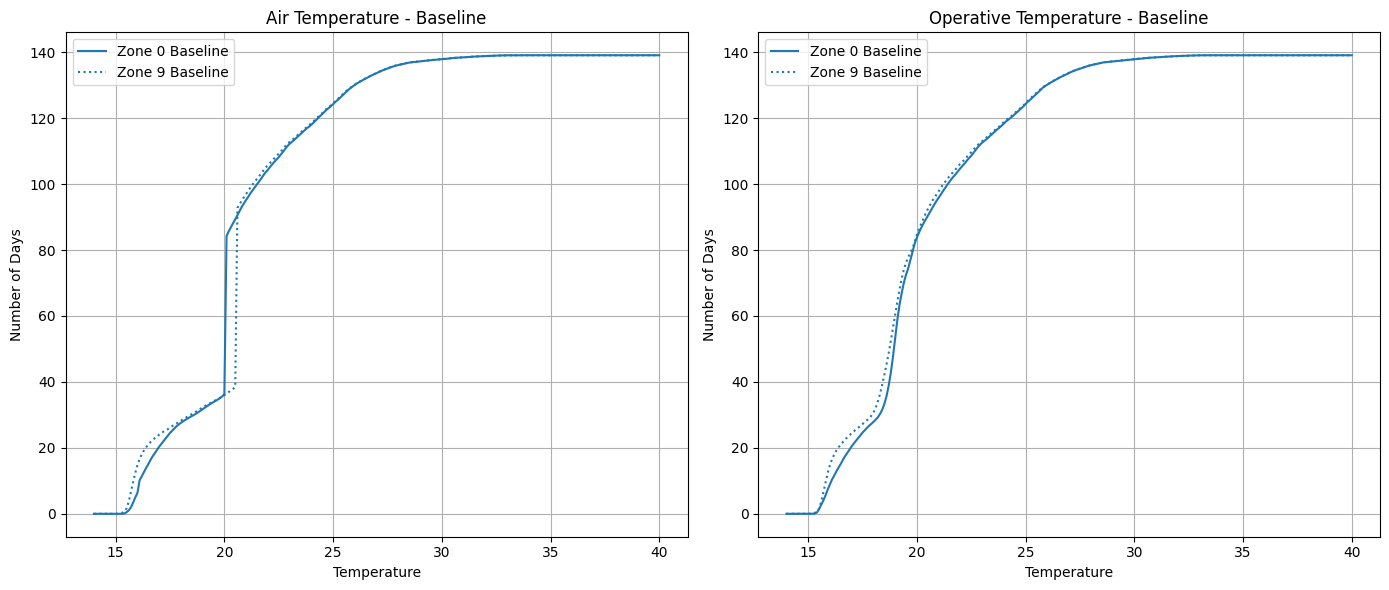

In [8]:


# Example usage for multiple cases
case_dict = {0: "Baseline"}

# Load and process data for all cases and store them in a dictionary
temperature_data_dict = {}
for case_number, case_label in case_dict.items():
    temperature_data = load_and_process_data('both', case_number=case_number, zone_9=True)
    temperature_data_dict[case_label] = temperature_data

# Plot each case in its own row with air temperature on the left and operative temperature on the right
plot_percentage_data_subplots_all_cases("combined", mins=mins, temperature_data_dict=temperature_data_dict, zone_9=True)


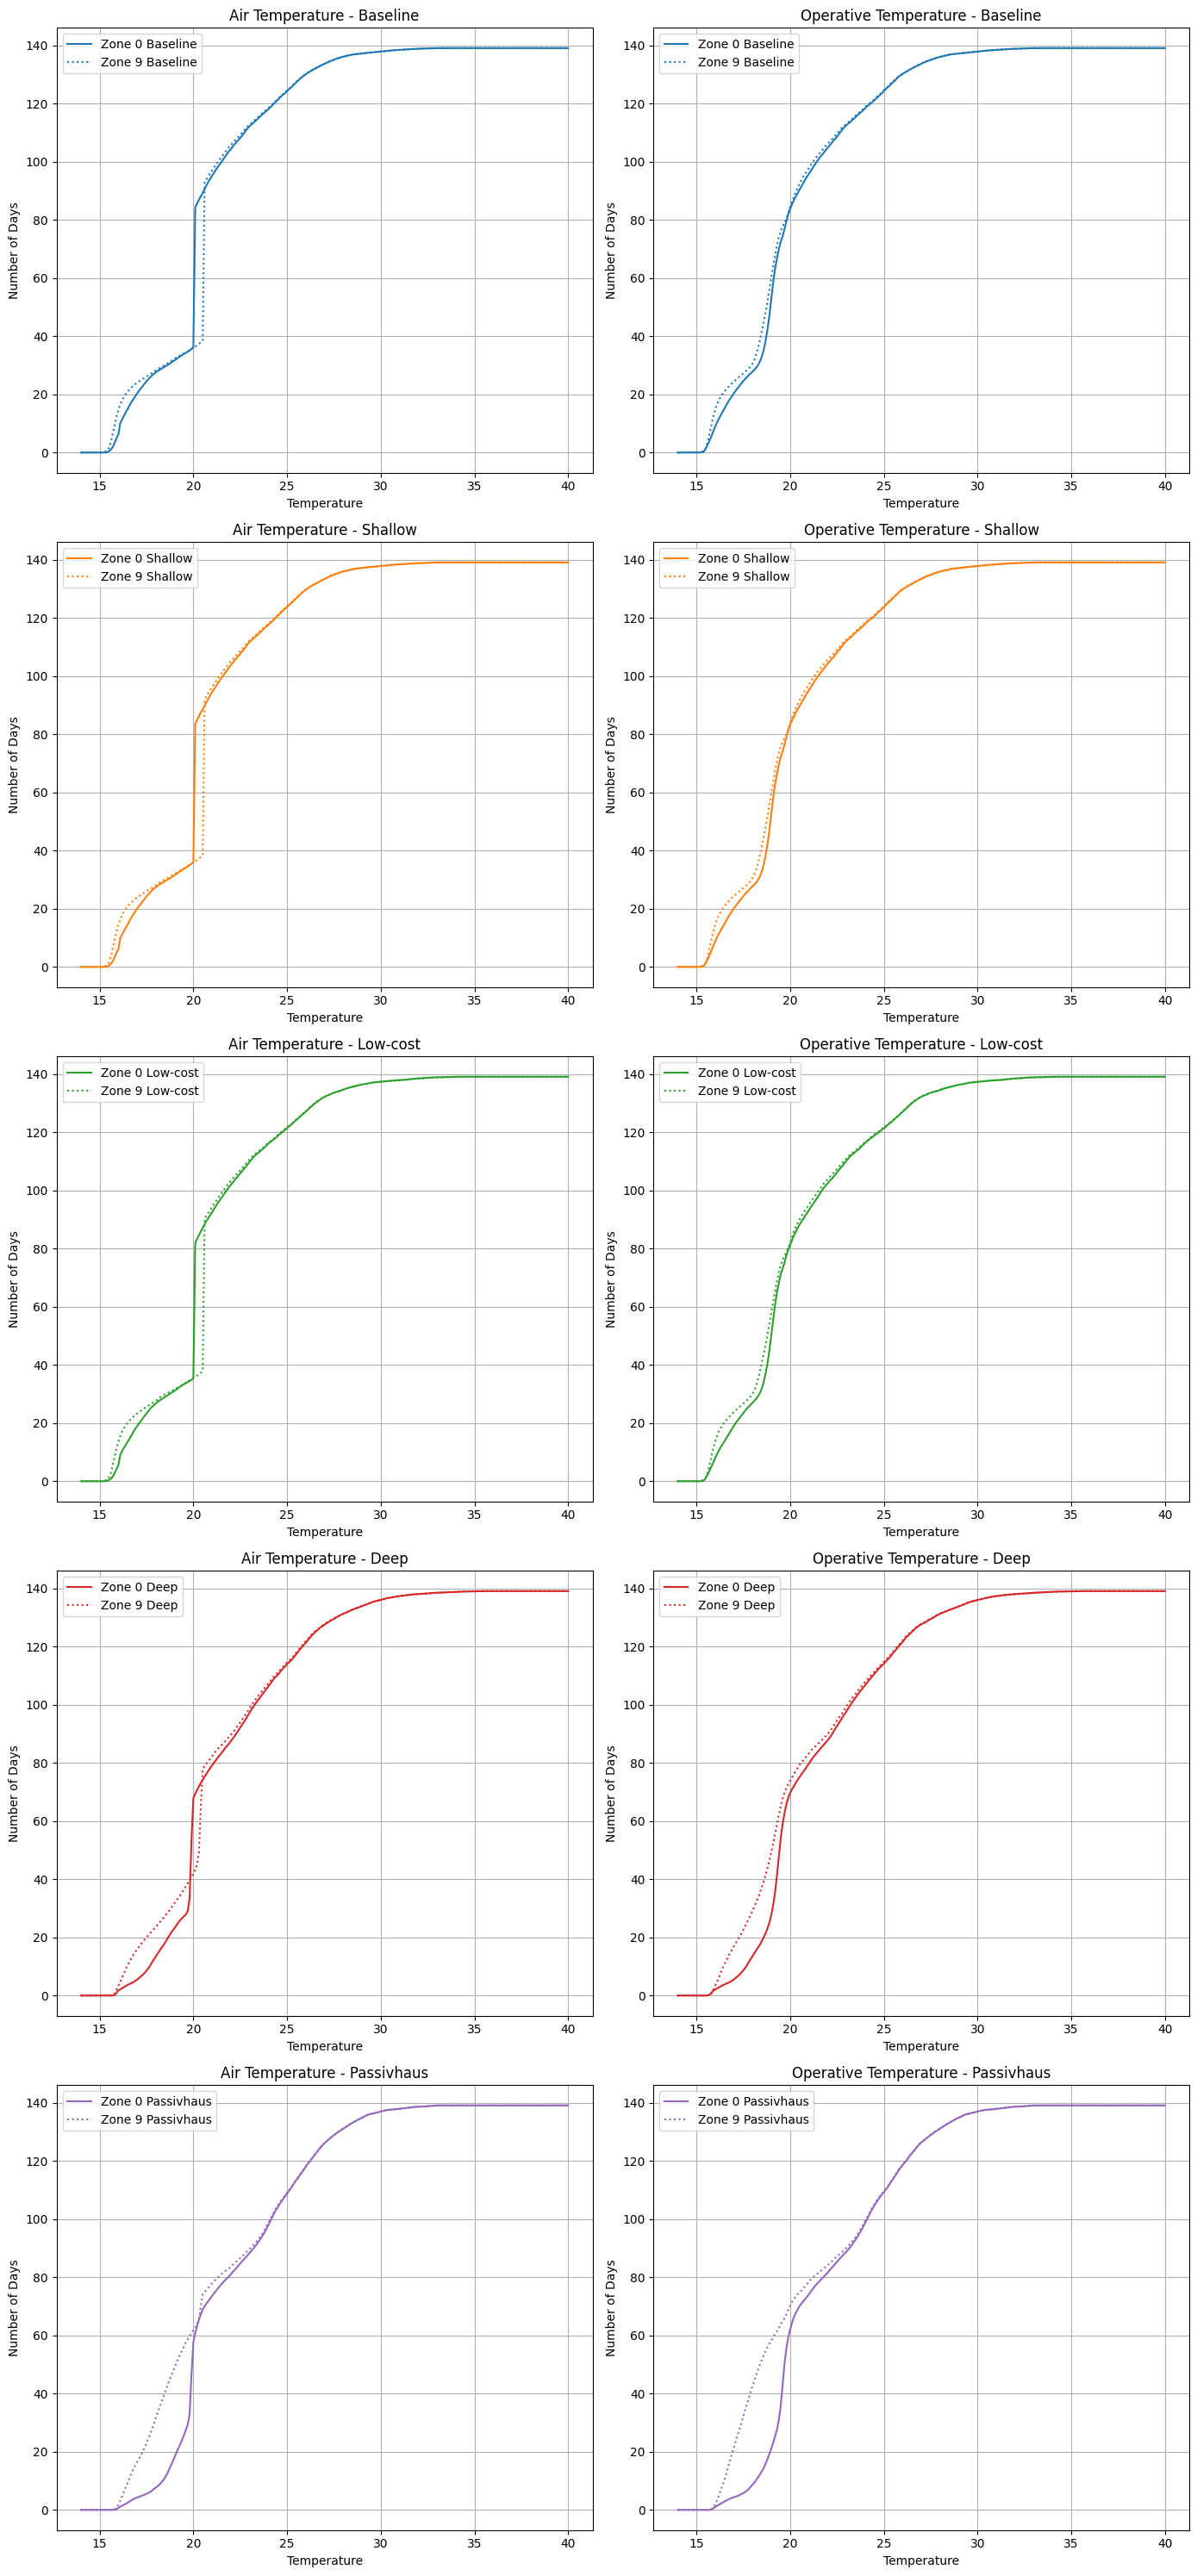

In [254]:


# Example usage for multiple cases
case_dict = {0: "Baseline", 1: "Shallow", 2: "Low-cost", 3: "Deep", 4: "Passivhaus"}

# Load and process data for all cases and store them in a dictionary
temperature_data_dict = {}
for case_number, case_label in case_dict.items():
    temperature_data = load_and_process_data('both', case_number=case_number, zone_9=True)
    temperature_data_dict[case_label] = temperature_data

# Plot each case in its own row with air temperature on the left and operative temperature on the right
plot_percentage_data_subplots_all_cases("combined", mins=mins, temperature_data_dict=temperature_data_dict, zone_9=True)


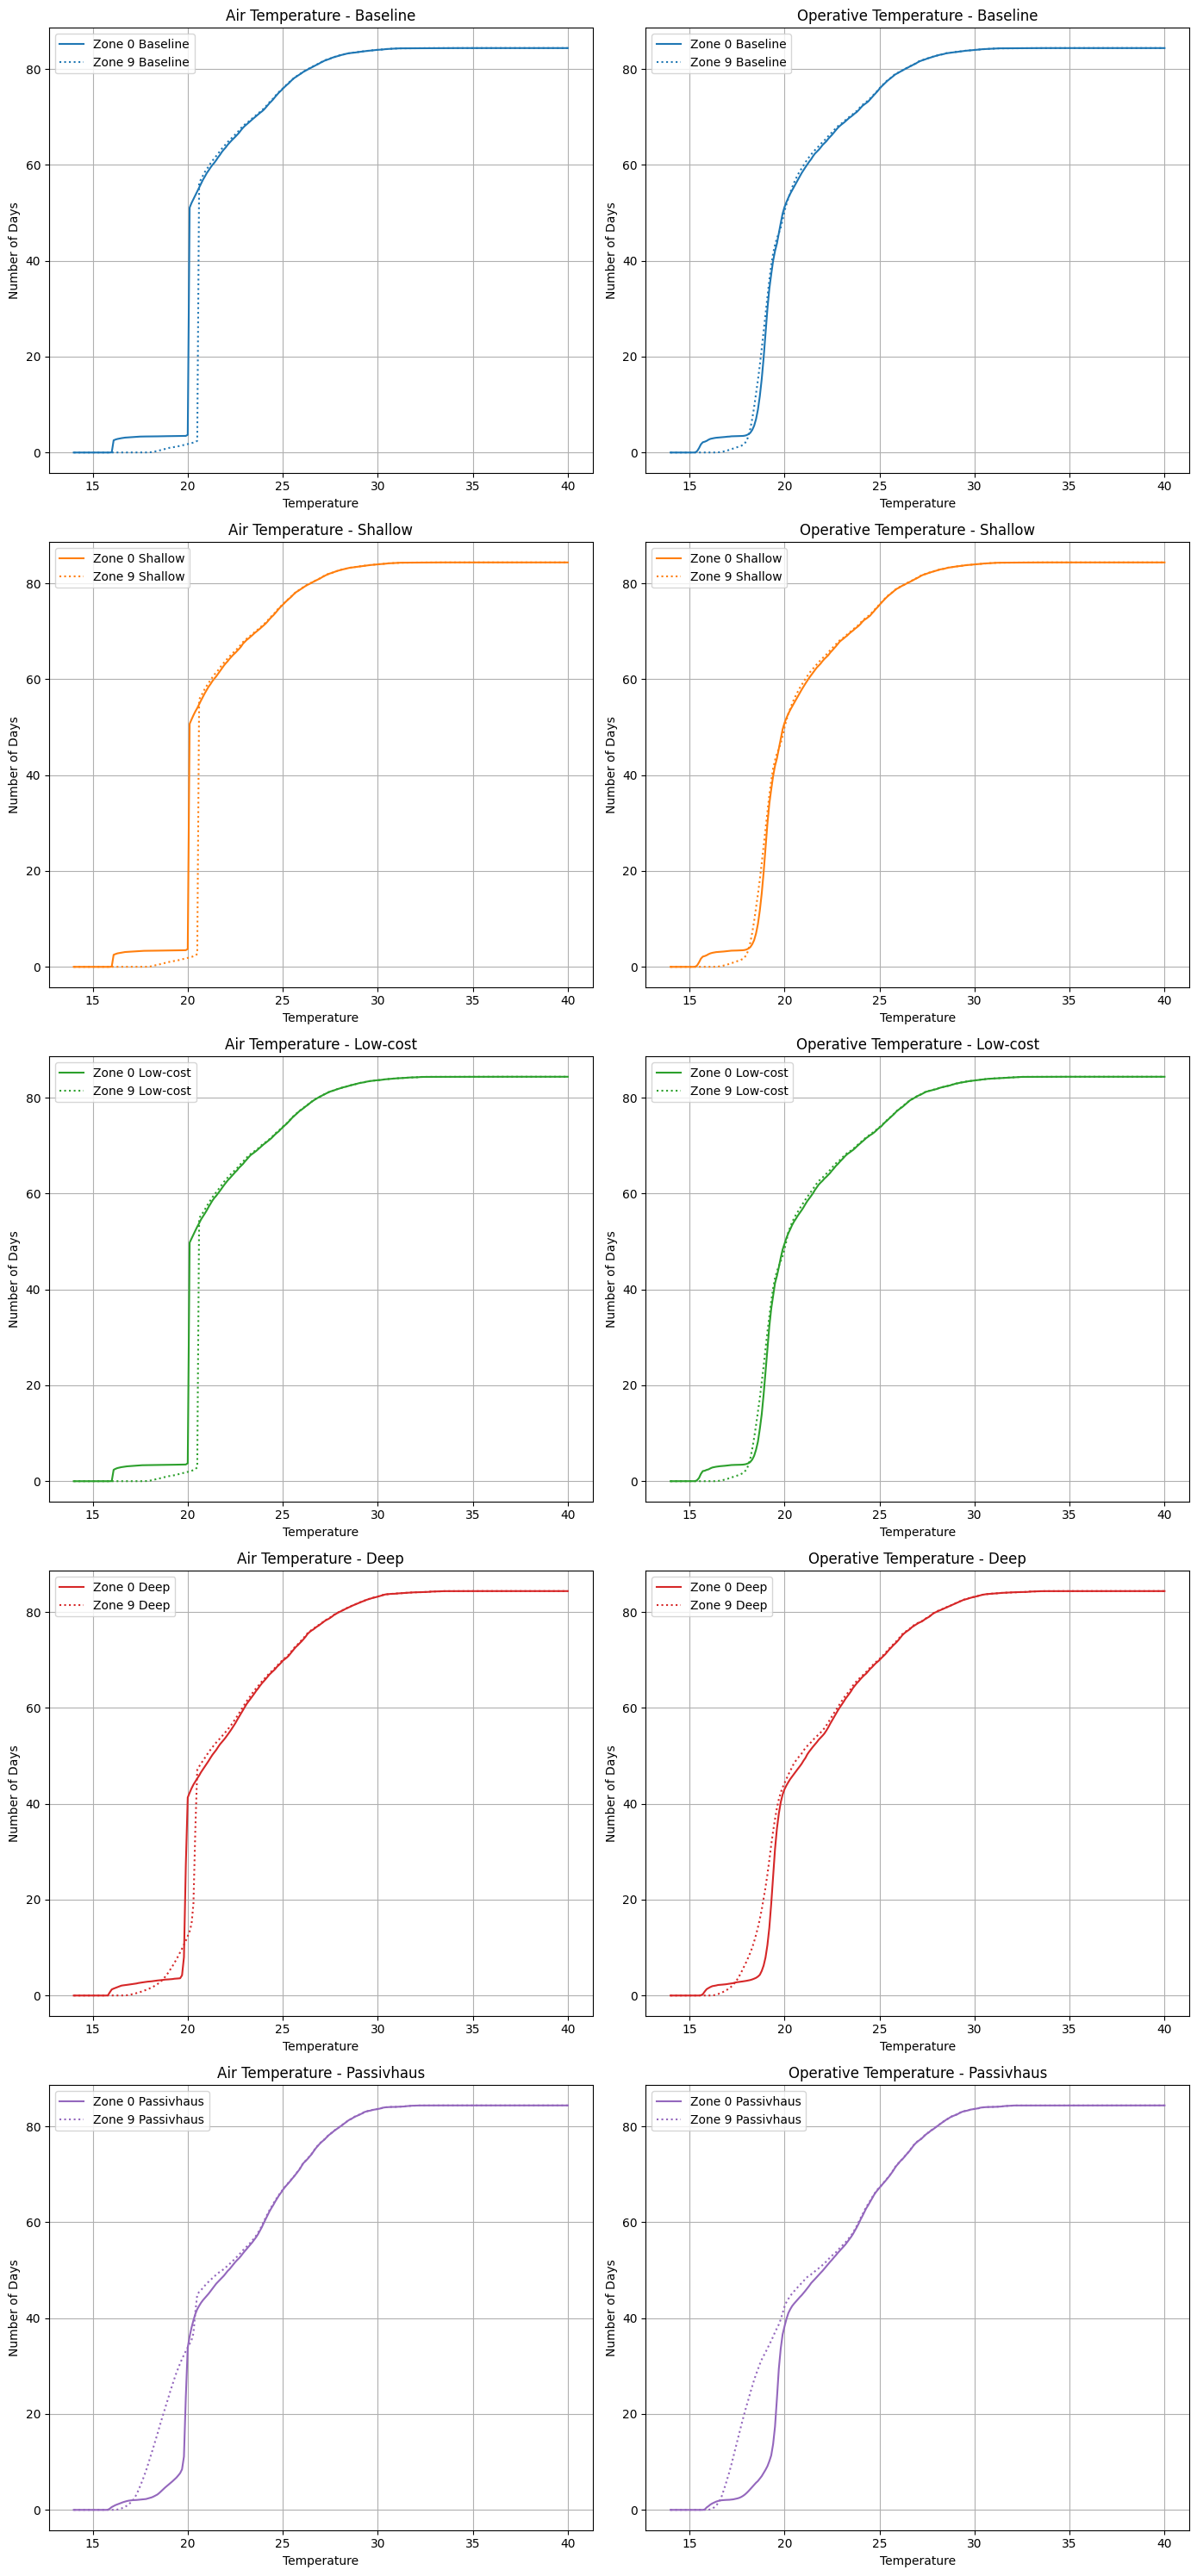

In [244]:


# Example usage for multiple cases
case_dict = {0: "Baseline", 1: "Shallow", 2: "Low-cost", 3: "Deep", 4: "Passivhaus"}

# Load and process data for all cases and store them in a dictionary
temperature_data_dict = {}
for case_number, case_label in case_dict.items():
    temperature_data = load_and_process_data('both', case_number=case_number, zone_9=True)
    temperature_data_dict[case_label] = temperature_data

# Plot each case in its own row with air temperature on the left and operative temperature on the right
plot_percentage_data_subplots_all_cases("in_hours", mins=mins, temperature_data_dict=temperature_data_dict, zone_9=True)


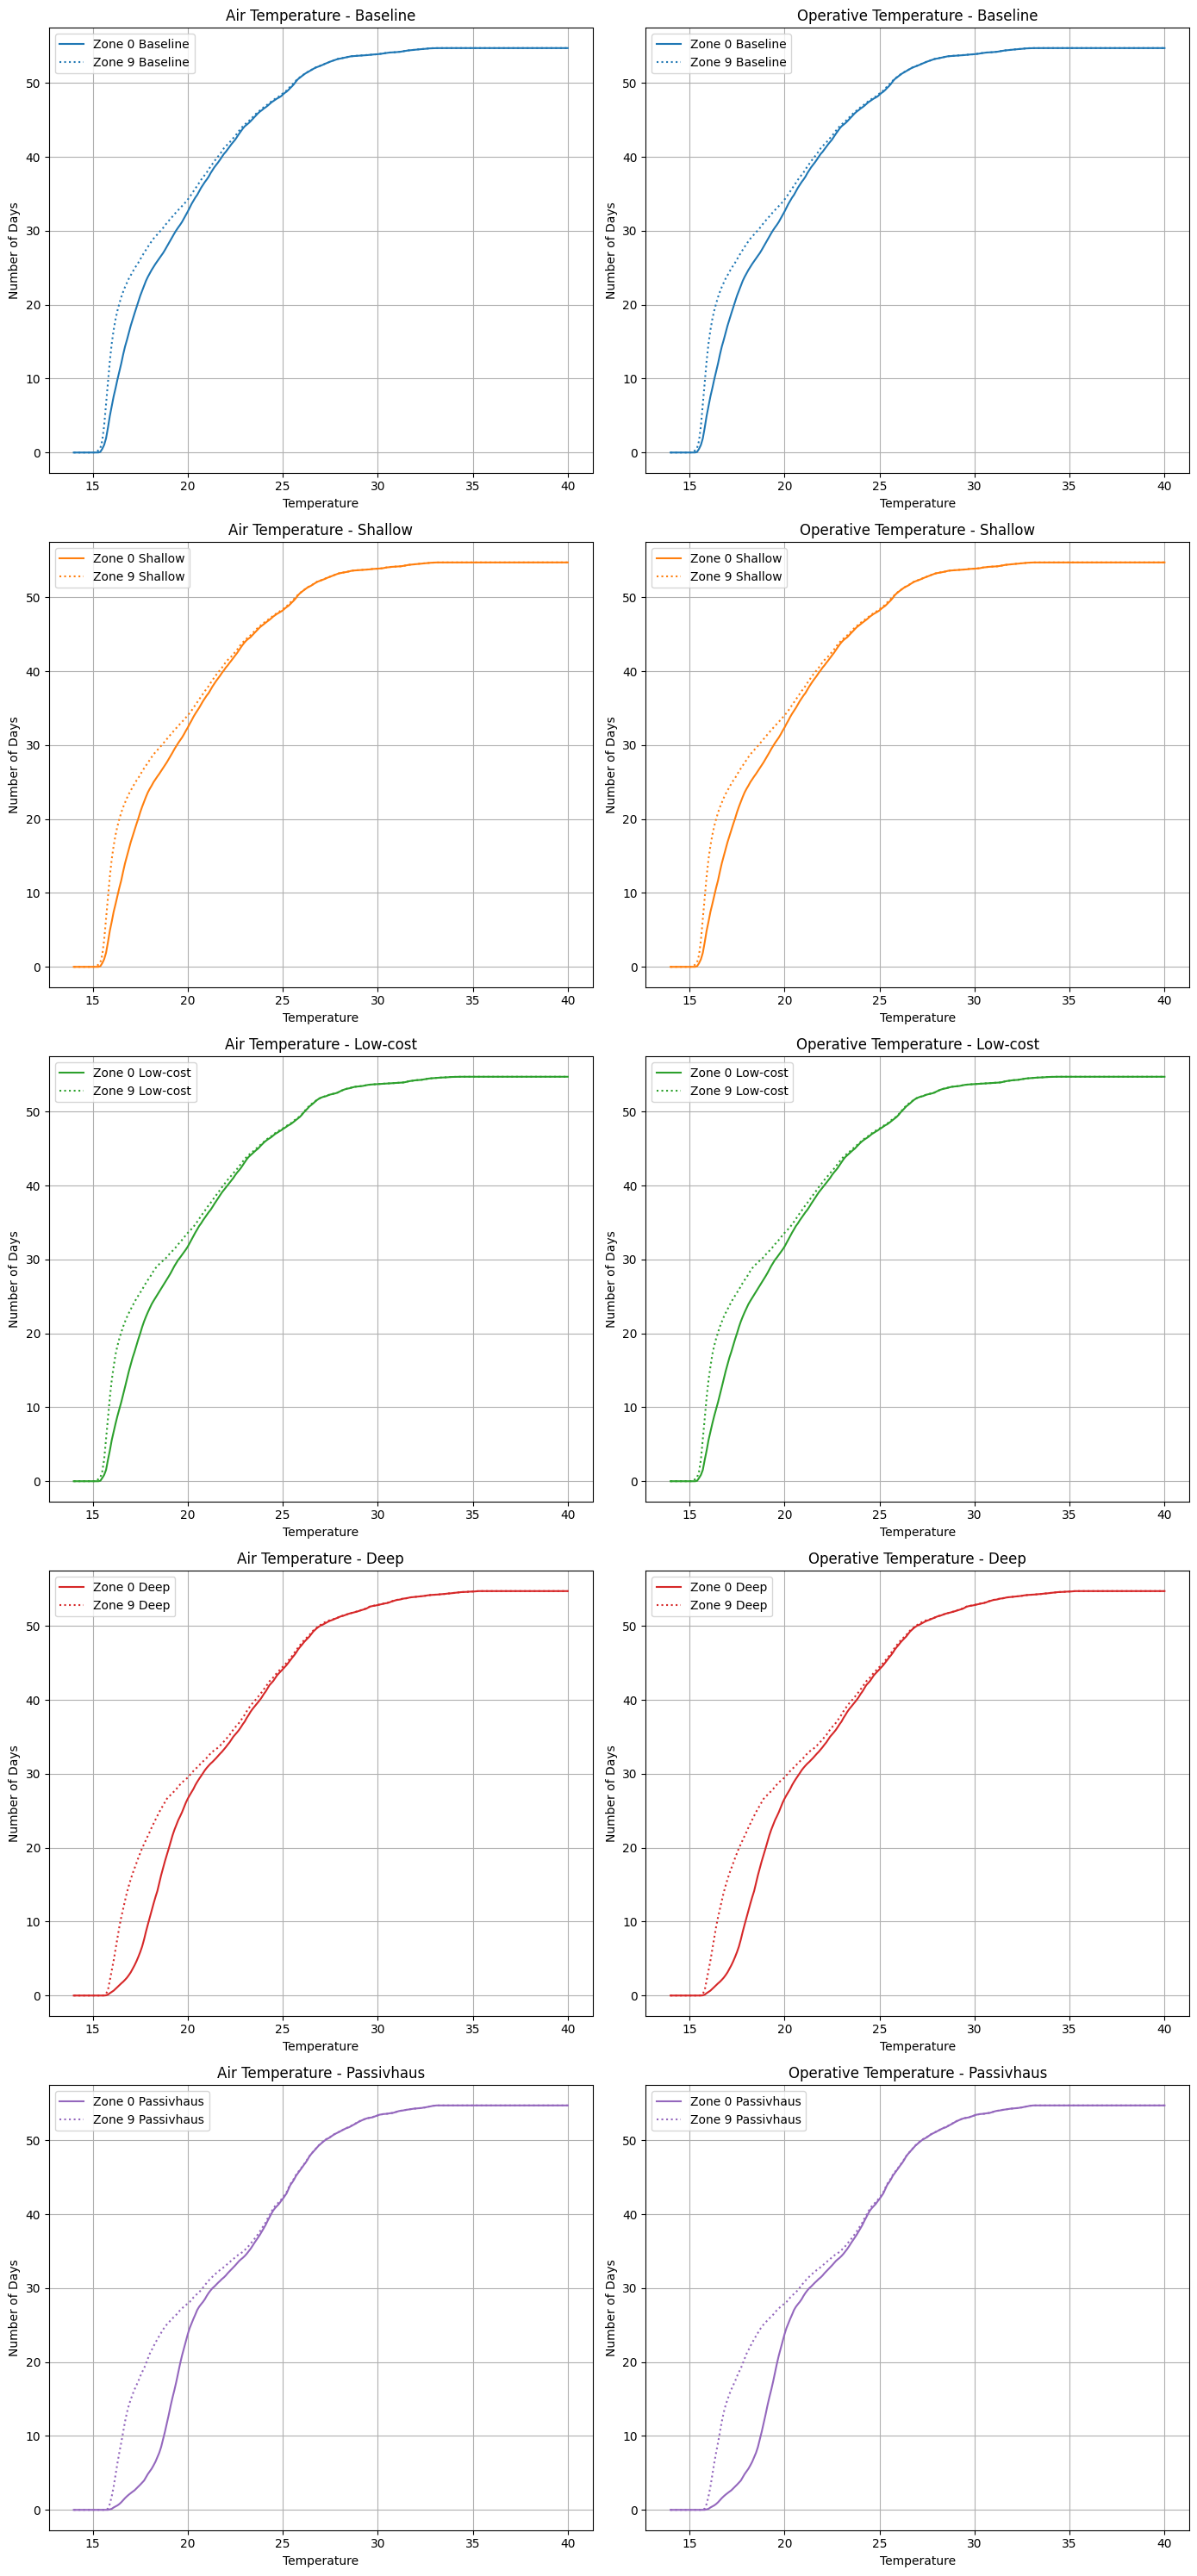

In [246]:


# Example usage for multiple cases
case_dict = {0: "Baseline", 1: "Shallow", 2: "Low-cost", 3: "Deep", 4: "Passivhaus"}

# Load and process data for all cases and store them in a dictionary
temperature_data_dict = {}
for case_number, case_label in case_dict.items():
    temperature_data = load_and_process_data('both', case_number=case_number, zone_9=True)
    temperature_data_dict[case_label] = temperature_data

# Plot each case in its own row with air temperature on the left and operative temperature on the right
plot_percentage_data_subplots_all_cases("out_of_hours", mins=mins, temperature_data_dict=temperature_data_dict, zone_9=True)


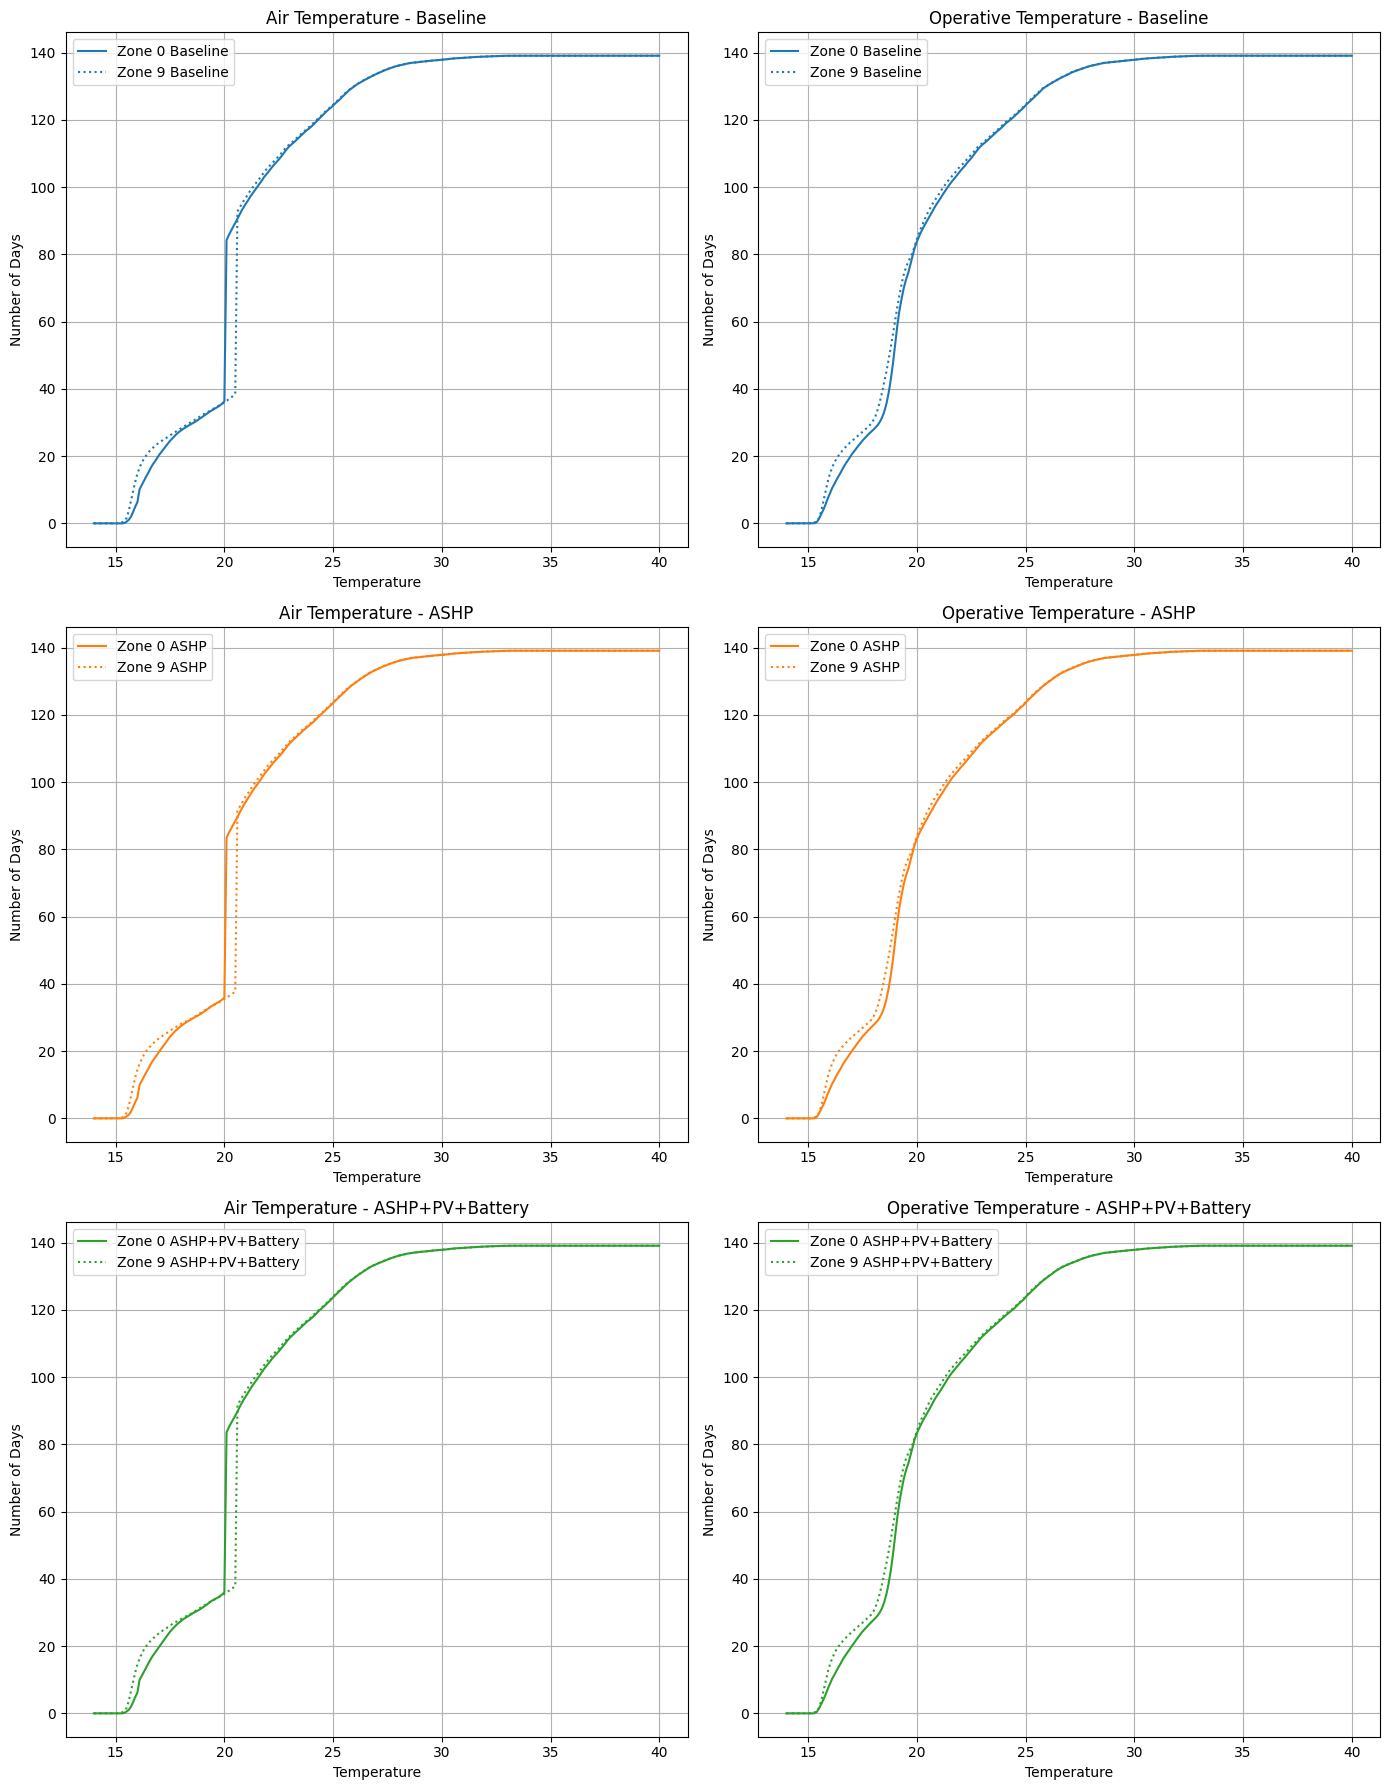

In [9]:


# Example usage for multiple cases
case_dict = {0: "Baseline", 5: "ASHP", 10: "ASHP+PV+Battery"}

# Load and process data for all cases and store them in a dictionary
temperature_data_dict = {}
for case_number, case_label in case_dict.items():
    temperature_data = load_and_process_data('both', case_number=case_number, zone_9=True)
    temperature_data_dict[case_label] = temperature_data

# Plot each case in its own row with air temperature on the left and operative temperature on the right
plot_percentage_data_subplots_all_cases("combined", mins=mins, temperature_data_dict=temperature_data_dict, zone_9=True)


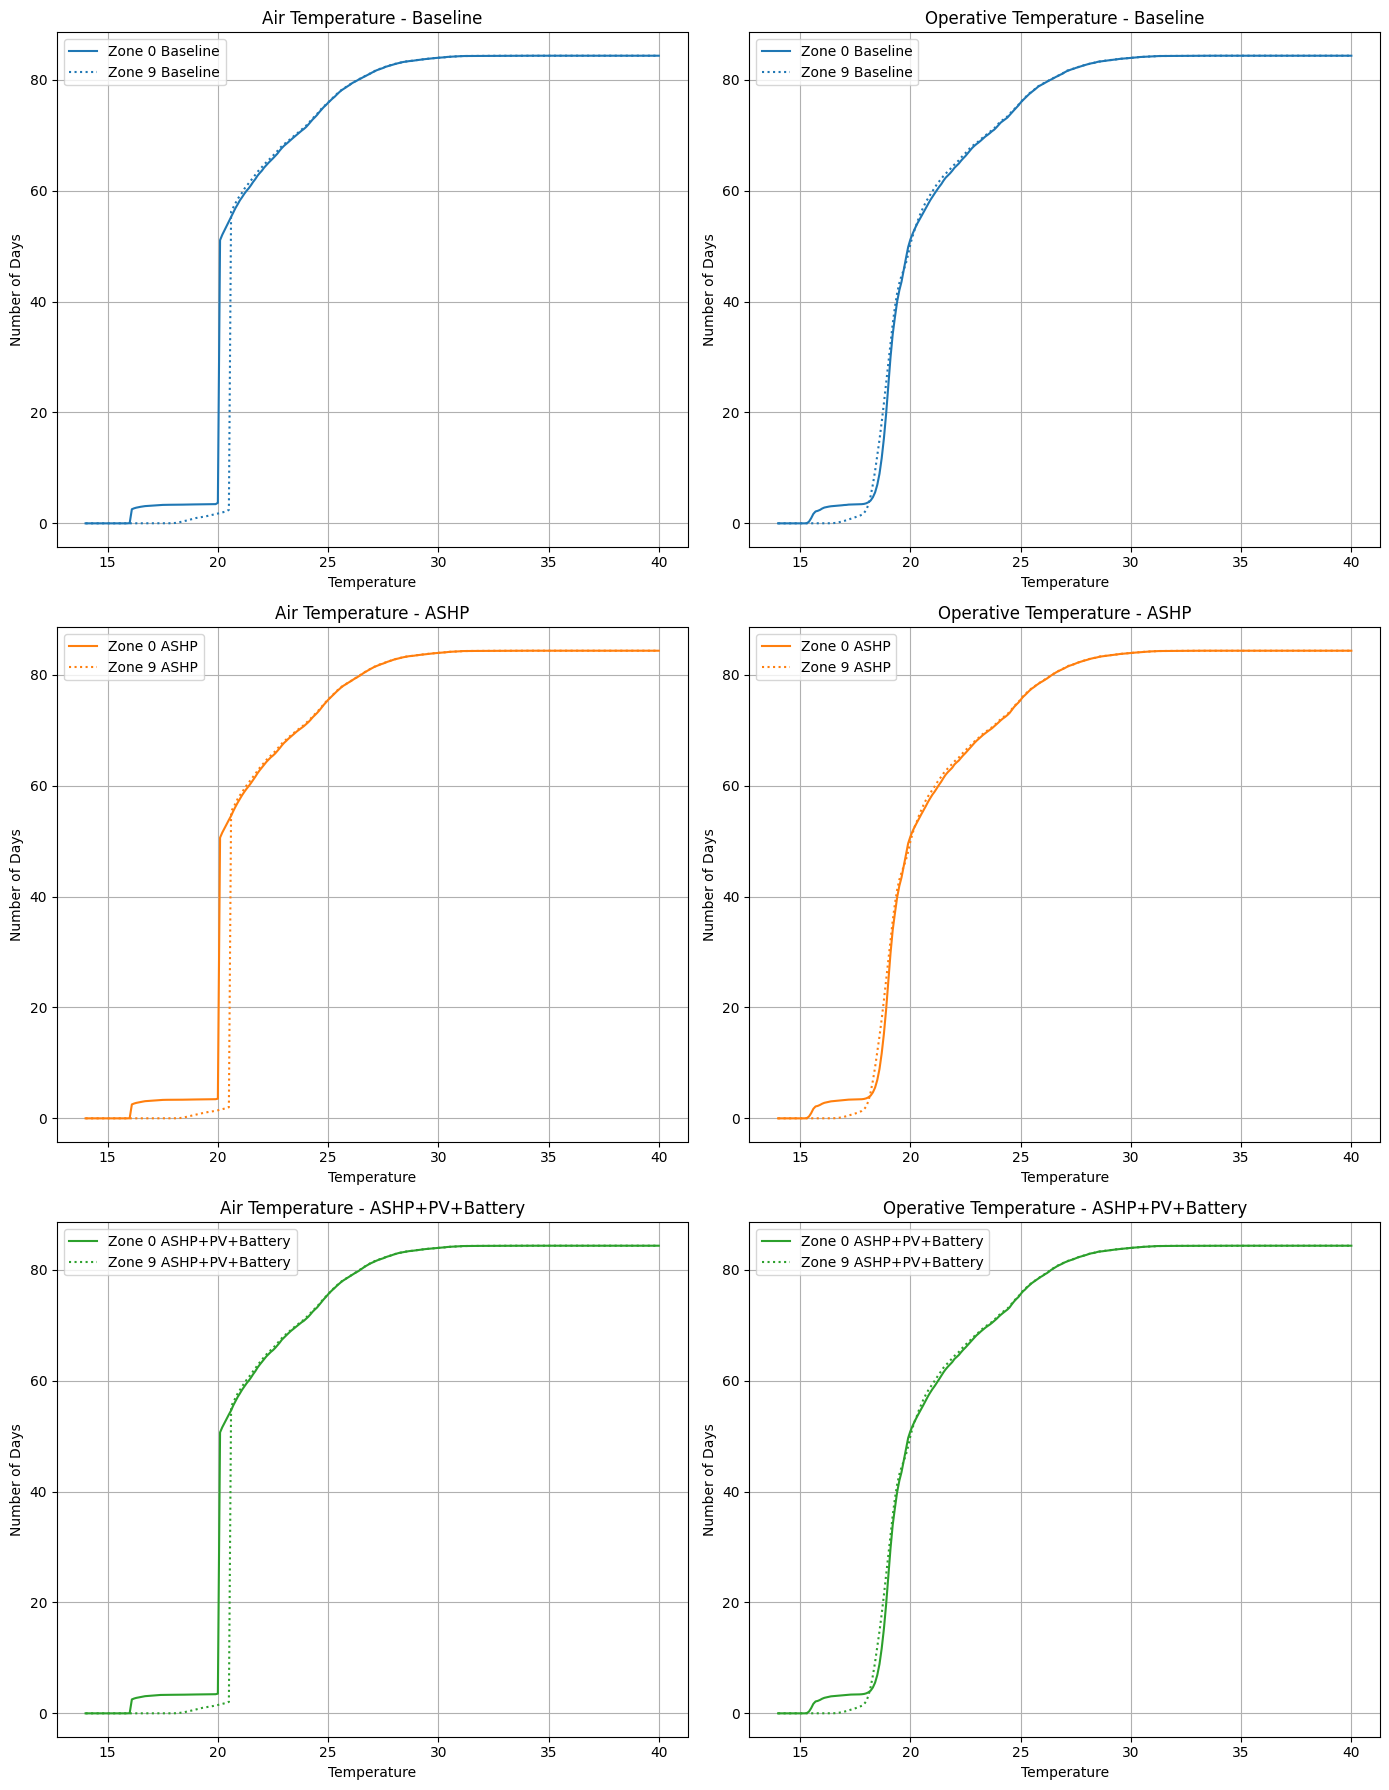

In [10]:


# Example usage for multiple cases
case_dict = {0: "Baseline", 5: "ASHP", 10: "ASHP+PV+Battery"}

# Load and process data for all cases and store them in a dictionary
temperature_data_dict = {}
for case_number, case_label in case_dict.items():
    temperature_data = load_and_process_data('both', case_number=case_number, zone_9=True)
    temperature_data_dict[case_label] = temperature_data

# Plot each case in its own row with air temperature on the left and operative temperature on the right
plot_percentage_data_subplots_all_cases("in_hours", mins=mins, temperature_data_dict=temperature_data_dict, zone_9=True)


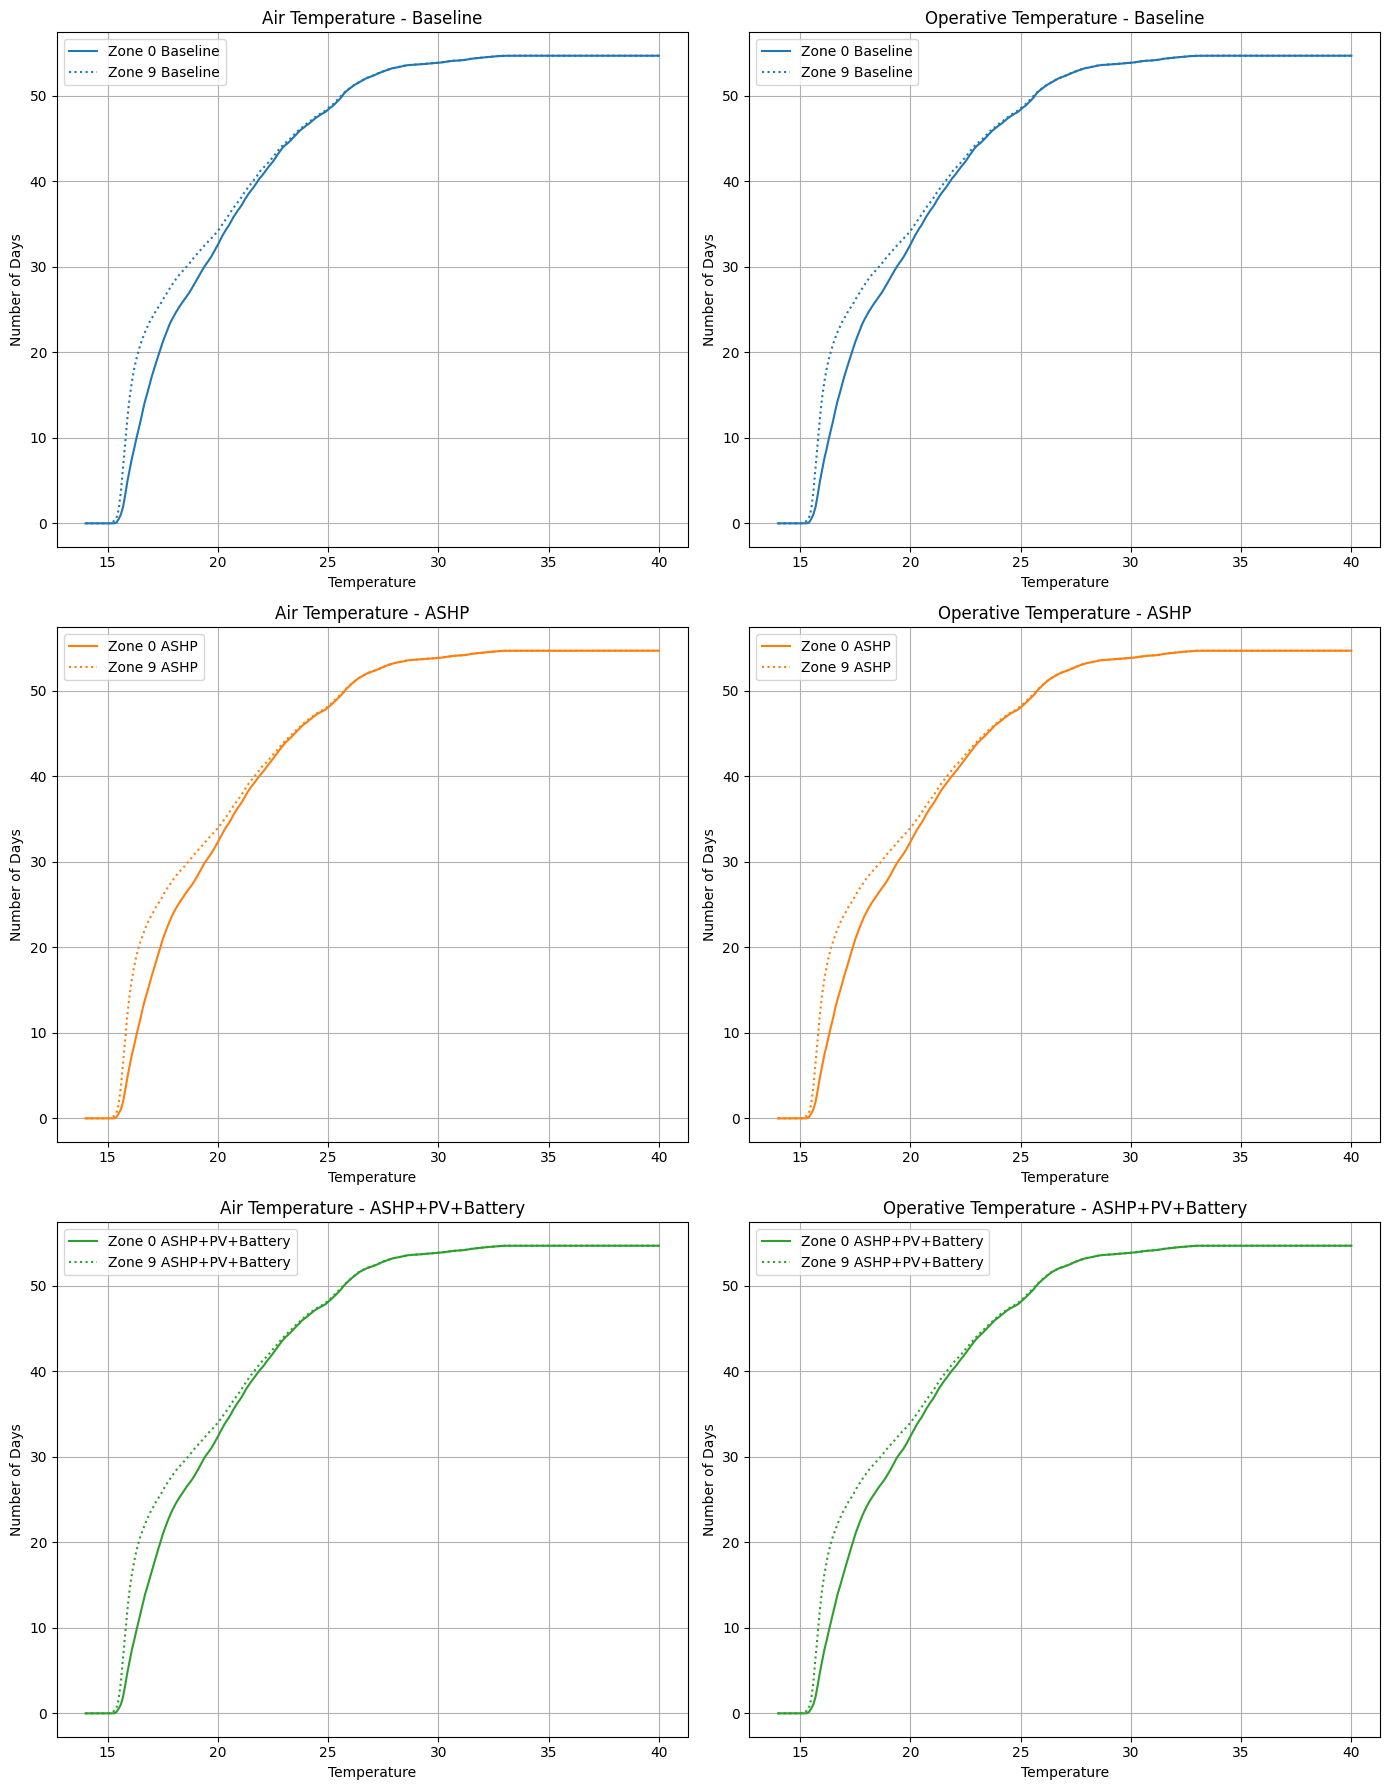

In [11]:


# Example usage for multiple cases
case_dict = {0: "Baseline", 5: "ASHP", 10: "ASHP+PV+Battery"}

# Load and process data for all cases and store them in a dictionary
temperature_data_dict = {}
for case_number, case_label in case_dict.items():
    temperature_data = load_and_process_data('both', case_number=case_number, zone_9=True)
    temperature_data_dict[case_label] = temperature_data

# Plot each case in its own row with air temperature on the left and operative temperature on the right
plot_percentage_data_subplots_all_cases("out_of_hours", mins=mins, temperature_data_dict=temperature_data_dict, zone_9=True)


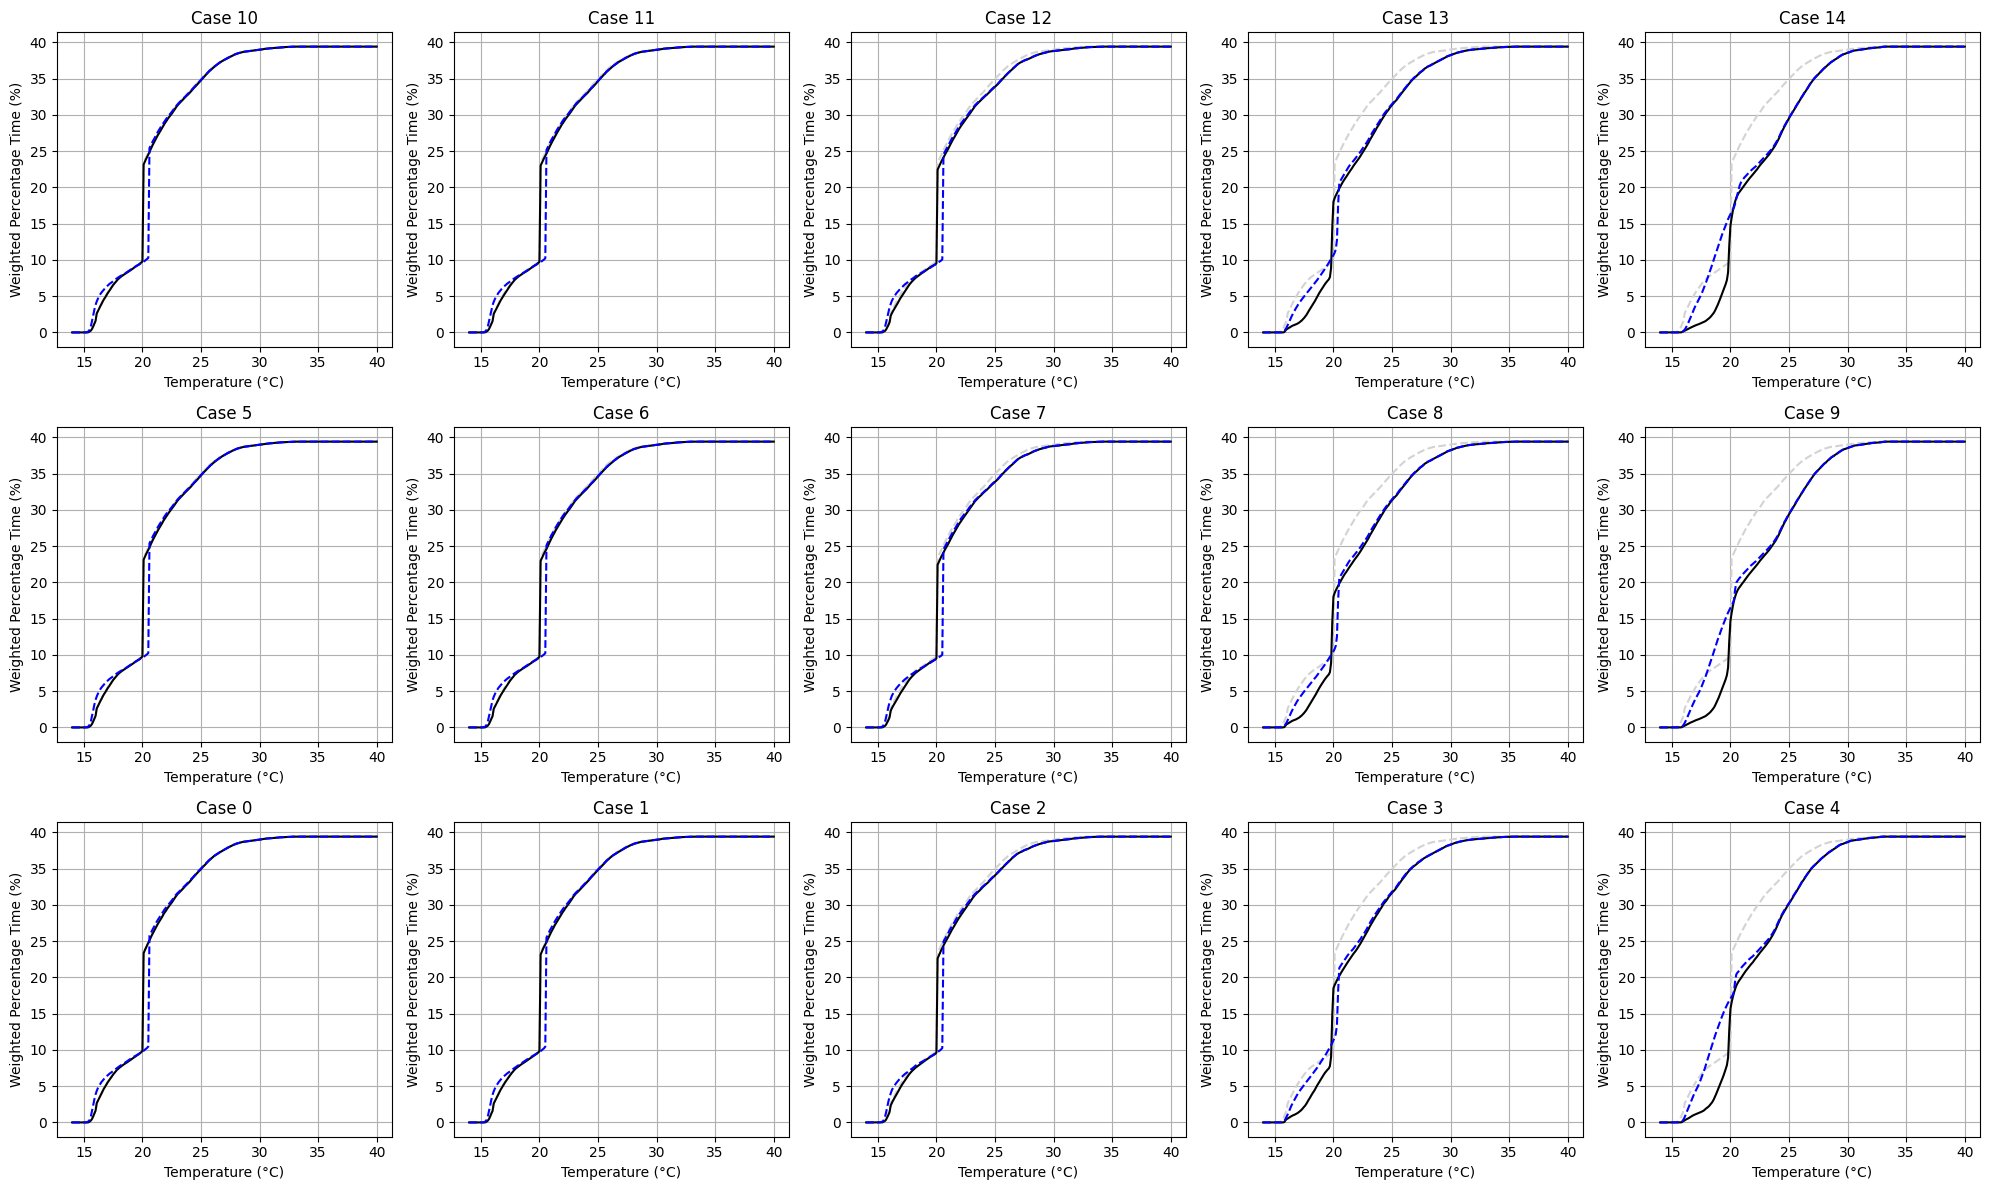

In [75]:
plot_figure("air")

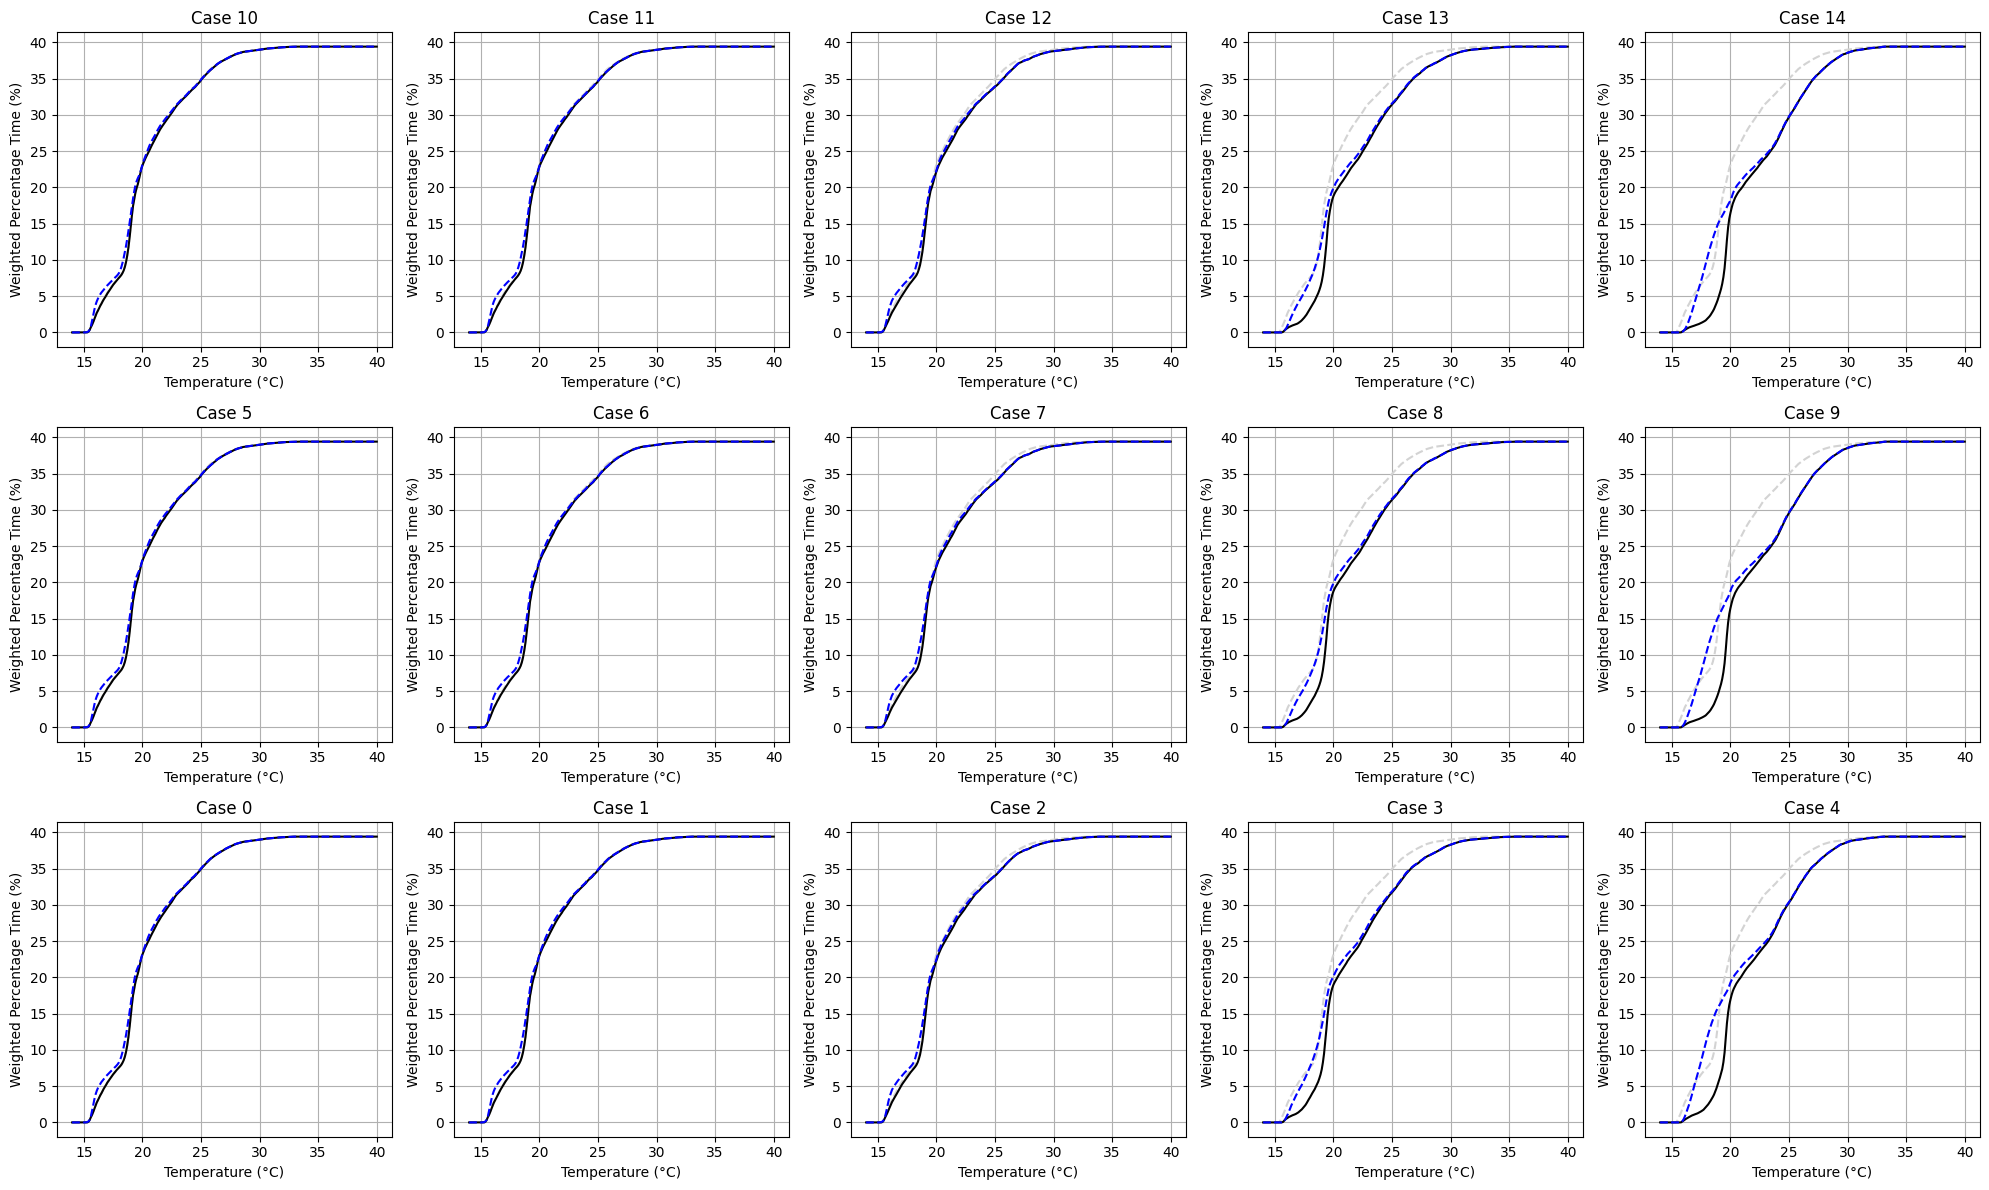

In [74]:
plot_figure("opr")